conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [94]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

In [95]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

In [96]:
from rllib.env_wrapper import RLlibEnvWrapper


In [97]:
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def make_experiment_dir(experiment_name, root=RESULTS_DIR):
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(root, f"{experiment_name}_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)
    return run_dir

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def make_env_config_variant(
    base_env_config,
    enable_travel=False,
    restrict_trade_to_region=False,
    travel_cost_coin=None,
    travel_cost_labor=None,
    experiment_name=None,
):
    cfg = deepcopy(base_env_config)

    # Example: switch travel component
    if "CrossWaterTravel" in cfg["components"]:
        cfg["components"]["CrossWaterTravel"]["enabled"] = bool(enable_travel)
        if travel_cost_coin is not None:
            cfg["components"]["CrossWaterTravel"]["travel_cost_coin"] = travel_cost_coin
        if travel_cost_labor is not None:
            cfg["components"]["CrossWaterTravel"]["travel_cost_labor"] = travel_cost_labor

    # Example: switch auction market structure
    if "ContinuousDoubleAuction" in cfg["components"]:
        cfg["components"]["ContinuousDoubleAuction"]["restrict_trade_to_region"] = bool(
            restrict_trade_to_region
        )

    if experiment_name is not None:
        cfg["experiment_name"] = experiment_name

    return cfg

In [98]:
import types
import numpy as np

def patch_regional_tax_masks(env_obj, min_band=4):
    """
    Patch all RegionalPeriodicBracketTax components inside a single RLlibEnvWrapper
    so each bound planner only has its own 7 brackets active, with at least
    `min_band` legal rate indices on tax day.
    """
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue

        def make_patched(c):
            def _patched_generate_masks(self, completions=0):
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

                disc = np.array(self.disc_rates, dtype=float)
                n = len(disc)

                if getattr(self, "tax_annealing_schedule", None) is not None:
                    cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
                    allowed_idx = np.where(disc <= cap)[0]
                else:
                    allowed_idx = np.arange(n)

                if allowed_idx.size < min_band:
                    allowed_idx = np.arange(min(min_band, n))

                if self.tax_cycle_pos == 1:
                    rate_mask = np.zeros(n, dtype=np.float32)
                    rate_mask[allowed_idx] = 1.0
                else:
                    rate_mask = np.zeros(n, dtype=np.float32)

                zero_mask = np.zeros_like(rate_mask, dtype=np.float32)
                masks = {}
                for k in all_keys:
                    masks[k] = rate_mask if (k in my_keys) else zero_mask

                return {str(planner.idx): masks}

            return types.MethodType(_patched_generate_masks, c)

        comp.generate_masks = make_patched(comp)

In [99]:
def patch_trainer_envs(trainer, min_band=4):
    """
    Apply the mask patch to every live env inside RLlib workers.
    Works with num_workers=0 and also with remote workers.
    """
    def _patch_env(env):
        patch_regional_tax_masks(env, min_band=min_band)
        return True

    trainer.workers.foreach_worker(
        lambda worker: worker.foreach_env(_patch_env)
    )

In [100]:
def get_active_planner_halves(dense_log, top_first=True):
    arr_top = dense_log["planner_actions"]["p_top"]
    arr_bot = dense_log["planner_actions"]["p_bottom"]

    if arr_top.size == 0 or arr_bot.size == 0:
        return np.zeros((0, 0), dtype=np.int64), np.zeros((0, 0), dtype=np.int64)

    half = arr_top.shape[1] // 2
    if top_first:
        active_top = arr_top[:, :half]   # p_top controls first 7
        active_bot = arr_bot[:, half:]   # p_bottom controls last 7
    else:
        active_top = arr_top[:, half:]
        active_bot = arr_bot[:, :half]

    return active_top, active_bot


def print_active_planner_debug(dense_log, top_first=True, max_rows=10):
    active_top, active_bot = get_active_planner_halves(dense_log, top_first=top_first)

    print("\n=== ACTIVE BRACKETS ONLY ===")
    print("p_top active shape:", active_top.shape)
    if active_top.size:
        print("p_top active unique rows:", np.unique(active_top, axis=0).shape[0])
        print("p_top active sample:")
        print(active_top[:max_rows])

    print("\np_bottom active shape:", active_bot.shape)
    if active_bot.size:
        print("p_bottom active unique rows:", np.unique(active_bot, axis=0).shape[0])
        print("p_bottom active sample:")
        print(active_bot[:max_rows])

In [101]:
def _get_disc_rates(env_obj):
    for comp in env_obj.env.components:
        if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
            return np.array(comp.disc_rates, dtype=float)
    return np.arange(0.0, 1.0 + 1e-9, 0.05)


def print_active_planner_rates(dense_log, env_obj, top_first=True, max_rows=10):
    disc_rates = _get_disc_rates(env_obj)
    active_top, active_bot = get_active_planner_halves(dense_log, top_first=top_first)

    if active_top.size:
        top_rates = disc_rates[np.clip(active_top, 0, len(disc_rates)-1)]
        print("\np_top active rates:")
        print(top_rates[:max_rows])

    if active_bot.size:
        bot_rates = disc_rates[np.clip(active_bot, 0, len(disc_rates)-1)]
        print("\np_bottom active rates:")
        print(bot_rates[:max_rows])

In [102]:
from ai_economist.foundation.base.base_component import component_registry
print(component_registry.get("CrossWaterTravel"))

<class 'ai_economist.foundation.components.cross_water_travel.CrossWaterTravel'>


# training sim

In [103]:
# # =========================
# # Tree-phase RLlib training
# # =========================
# import os
# import time
# import gc
# import types
# import numpy as np
# import ray
# import copy

# from ray.rllib.agents.ppo import PPOTrainer
# from tutorials.rllib.env_wrapper import RLlibEnvWrapper
# from ai_economist import foundation
# from ai_economist.foundation.scenarios.utils.rewards import coin_eq_times_productivity

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" #maybe not needed

# # ----------------------------
# # SETTINGS
# # ----------------------------
# FRAMEWORK      = "tf"      # "tf" or "torch"
# PHASE1_ITERS   = 50 #100
# PHASE2_ITERS   = 125 #250
# PHASE3A_ITERS   = 50 #100
# PHASE3B_ITERS   = 50  #100
# MIN_BAND       = 4 #For each tax bracket, the planner must have at least 4 possible tax rates to choose from - even in annealing phase.
# PERIOD         = 100
# EPISODE_LENGTH = 1000
# WORLD_SIZE     = [51, 25]
# LAYOUT_FILE    = "stacked_51x25.txt" 
# #"stacked_51x25_more_stone.txt"

# # ----------------------------
# # Ray init (Windows-safe)
# # ----------------------------
# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# # ----------------------------
# # Policy mapping
# # ----------------------------
# def policy_mapping_fun(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# # ----------------------------
# # Travel Config
# # ----------------------------
# def travel_component_config(
#     enabled,
#     allow_only_agent,
#     travel_cost_coin=2,
#     travel_cost_labor=0,
#     cooldown=12,
    
# ):
#     return ('CrossWaterTravel', {
#         'enabled': enabled,
#         'travel_cost_coin': travel_cost_coin,
#         'travel_cost_labor': travel_cost_labor,
#         'cooldown': cooldown,
#         'target_top': (7, 12),
#         'target_bottom': (43, 12),
#         'allow_only_agent': allow_only_agent,
        
#     })

# # ----------------------------
# # Env Configs (Phase 1 & 2)
# # ----------------------------
# env_config_dict_phase1 = {
#     "scenario_name": "custom/splitworld_overlay_regional",
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3, #maybe change
#             'build_labor': 2.1, #set from table 2 in AI economist (prev 10)
#             'payment': 10, #prev 10
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05, #set from table 2 in AI economist (prev 0.25)
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": True,
#         }),
#         ('Gather', {
#             'move_labor': 0.21, #set from table 2 in AI economist (prev 1)
#             'collect_labor': 0.21, #set from table 2 in AI economist (prev 10)
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": True,
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": True,
#         }),
#         travel_component_config(
#             enabled=False,
#             allow_only_agent=0,
#             travel_cost_coin=2,
#             travel_cost_labor=2,
#             cooldown=20,
#         ),
#     ],
    
#     "env_layout_file": LAYOUT_FILE,
#     "world_size": WORLD_SIZE,
#     "episode_length": EPISODE_LENGTH,
#     "starting_agent_coin": 0, # prev 10
#     "fixed_four_skill_and_loc": False,
#     "n_agents": 8,
#     "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#     "multi_action_mode_planner": True,
#     "multi_action_mode_agents": True,
#     "flatten_observations": True,
#     "flatten_masks": True,
#     "dense_log_frequency": 1,

#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#     1.1, 1.3, 1.6, 2.2,
#     1.1, 1.3, 1.6, 2.2,
#     ],

    
# }

# env_config_dict_phase2 = {
#     "scenario_name": "custom/splitworld_overlay_regional",
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3,
#             'build_labor': 2.1, #set from table 2 in AI economist (prev 10)
#             'payment': 10 #prev 10
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05, #set from table 2 in AI economist (prev 0.25)
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": True,
#         }),
#         ('Gather', {
#             'move_labor':  0.21, #set from table 2 in AI economist (prev 1)
#             'collect_labor':  0.21, #set from table 2 in AI economist (prev 1)
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         travel_component_config(
#             enabled=False,
#             allow_only_agent=0,
#             travel_cost_coin=2,
#             travel_cost_labor=2,
#             cooldown=20,
#         ),
#     ],
#     "env_layout_file": LAYOUT_FILE,
#     "world_size": WORLD_SIZE,
#     "episode_length": EPISODE_LENGTH,
#     "starting_agent_coin": 0, # prev 10
#     "fixed_four_skill_and_loc": False,
#     "n_agents": 8,
#     "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#     "multi_action_mode_planner": True,
#     "multi_action_mode_agents": True,
#     "flatten_observations": True,
#     "flatten_masks": True,
#     "dense_log_frequency": 1,

#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#     1.1, 1.3, 1.6, 2.2,
#     1.1, 1.3, 1.6, 2.2,
#     ],


#     }

# env_config_dict_phase3a = {
#     **env_config_dict_phase2,
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3,
#             'build_labor': 2.1, #set from table 2 in AI economist (prev 10)
#             'payment': 10
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05, #set from table 2 in AI economist (prev 0.25)
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": True,
#         }),
#         ('Gather', {
#             'move_labor':  0.21, #set from table 2 in AI economist (prev 1)
#             'collect_labor':  0.21, #set from table 2 in AI economist (prev 1)
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         travel_component_config(
#             enabled=False,
#             allow_only_agent=0,
#             travel_cost_coin=1,
#             travel_cost_labor=0,
#             cooldown=10, #effectively 9 because of updated
#         ),
#     ],
#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#     1.1, 1.3, 1.6, 2.2,
#     1.1, 1.3, 1.6, 2.2,
#     ],

# }


# env_config_dict_phase3b = copy.deepcopy(env_config_dict_phase3a)


# # ----------------------------
# # Build policies from an env
# # ----------------------------
# def build_policies(env_obj, agent_policy_config=None, p_top_config=None, p_bottom_config=None):
#     obs_space_a   = env_obj.observation_space
#     act_space_a   = env_obj.action_space
#     obs_space_top = env_obj.observation_space_pl["p_top"]
#     act_space_top = env_obj.action_space_pl["p_top"]
#     obs_space_bot = env_obj.observation_space_pl["p_bottom"] 
#     act_space_bot = env_obj.action_space_pl["p_bottom"]

#     if agent_policy_config is None:
#         agent_policy_config = {"lr": 3e-4}
#     if p_top_config is None:
#         p_top_config = {"lr": 1e-4, "entropy_coeff": 0.02}
#     if p_bottom_config is None:
#         p_bottom_config = {"lr": 1e-4, "entropy_coeff": 0.02}

#     return {
#         "a": (None, obs_space_a, act_space_a, agent_policy_config),
#         "p_top": (None, obs_space_top, act_space_top, p_top_config),
#         "p_bottom": (None, obs_space_bot, act_space_bot, p_bottom_config),
#     }


# # ----------------------------
# # Common trainer config
# # ----------------------------
# def build_trainer_config(env_config_dict, policies, policies_to_train):
#     return {
#         "env": RLlibEnvWrapper,
#         "env_config": {
#             "env_config_dict": env_config_dict,
#             "num_envs_per_worker": 1,
#         },
#         "multiagent": {
#             "policies": policies,
#             "policies_to_train": policies_to_train,
#             "policy_mapping_fn": policy_mapping_fun,
#         },
#         "num_workers": 0,
#         "num_envs_per_worker": 1,
#         "framework": FRAMEWORK,
#         "num_gpus": 0,
#         "rollout_fragment_length": 50,
#         "batch_mode": "truncate_episodes",
#         "train_batch_size": 800,
#         "sgd_minibatch_size": 128,
#         "num_sgd_iter": 2,
#         "log_level": "WARN",
#     }

# # ----------------------------
# # Runtime patch: ensure multiple legal choices at tax day
# # ----------------------------
# def patch_regional_tax_masks(env_obj, min_band=4):
#     for comp in env_obj.env.components:
#         if "BracketTax" not in comp.name:
#             continue

#         def make_patched(c):
#             def _patched_generate_masks(self, completions=0):
#                 planner = self._get_bound_planner(self.world)
#                 if planner is None or str(planner.idx) != str(self._planner_id):
#                     return {}

#                 all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
#                 my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

#                 disc = np.array(self.disc_rates, dtype=float)
#                 n = len(disc)

#                 if getattr(self, "tax_annealing_schedule", None) is not None:
#                     cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
#                     allowed_idx = np.where(disc <= cap)[0]
#                 else:
#                     allowed_idx = np.arange(n)

#                 if allowed_idx.size < min_band:
#                     allowed_idx = np.arange(min(min_band, n))

#                 if getattr(self, "tax_cycle_pos", None) == 1:
#                     rate_mask = np.zeros(n, dtype=np.float32)
#                     rate_mask[allowed_idx] = 1.0
#                 else:
#                     rate_mask = np.zeros(n, dtype=np.float32)

#                 zero_mask = np.zeros_like(rate_mask, dtype=np.float32)
#                 masks = {}
#                 for k in all_keys:
#                     masks[k] = rate_mask if (k in my_keys) else zero_mask

#                 return {str(planner.idx): masks}

#             return types.MethodType(_patched_generate_masks, c)

#         comp.generate_masks = make_patched(comp)

# def patch_trainer_envs(trainer, min_band=4):
#     def _patch_env(env):
#         patch_regional_tax_masks(env, min_band=min_band)
#         return True
#     trainer.workers.foreach_worker(
#         lambda worker: worker.foreach_env(_patch_env)
#     )

# # ----------------------------
# # True tax decision detection
# # ----------------------------
# def is_tax_day(env_obj):
#     for c in env_obj.env.components:
#         if "BracketTax" in c.name and getattr(c, "tax_cycle_pos", None) == 1:
#             return True
#     return False

# # ----------------------------
# # Rollout
# # ----------------------------
# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=2,
#     explore=False,
#     log_only_tax_days=True
# ):
#     def _compute_action(pid, obs, state):
#         out = trainer.compute_action(
#             observation=obs,
#             state=state,
#             policy_id=pid,
#             full_fetch=False,
#             explore=explore
#         )
#         if isinstance(out, tuple):
#             if len(out) >= 2:
#                 return out[0], out[1]
#             return out[0], state
#         return out, state

#     dense_logs = {}

#     for ep in range(num_dense_logs):
#         obs = env_obj.reset(force_dense_logging=True)

#         agent_states = {
#             str(i): trainer.get_policy("a").get_initial_state()
#             for i in range(env_obj.env.n_agents)
#         }
#         p_top_state = trainer.get_policy("p_top").get_initial_state()
#         p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

#         top_actions, bot_actions = [], []
#         top_rewards, bot_rewards = [], []

#         agent_utility_history = [] #new

#         for _t in range(env_obj.env.episode_length):
#             actions = {}

#             for i in range(env_obj.env.n_agents):
#                 aid = str(i)
#                 a, ns = _compute_action("a", obs[aid], agent_states[aid])
#                 actions[aid] = a
#                 agent_states[aid] = ns

#             a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
#             a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
#             actions["p_top"] = a_top
#             actions["p_bottom"] = a_bottom

#             should_log = (not log_only_tax_days) or is_tax_day(env_obj)
#             if should_log:
#                 top_actions.append(np.array(a_top, copy=True))
#                 bot_actions.append(np.array(a_bottom, copy=True))

#             obs, rew, done, info = env_obj.step(actions)

#             for agent in env_obj.env.world.agents: #
#                 travel_action = agent.get_component_action("CrossWaterTravel") #
#                 if travel_action == 1: #
#                     print(f"[t={_t}] Agent {agent.idx} TRAVEL ACTION") #

#             # store per-agent utility for this timestep
#             util_t = {}
#             for agent in env_obj.env.world.agents:
#                 aid = str(agent.idx)
#                 util_t[aid] = float(
#                     env_obj.env.curr_optimization_metric.get(agent.idx, np.nan)
#                 )
#             agent_utility_history.append(util_t)

#             top_rewards.append(rew.get("p_top", np.nan))
#             bot_rewards.append(rew.get("p_bottom", np.nan))

#             if done.get("__all__", False):
#                 break

#         top_arr = np.stack(top_actions, axis=0) if len(top_actions) else np.zeros((0, 0), dtype=np.int64)
#         bot_arr = np.stack(bot_actions, axis=0) if len(bot_actions) else np.zeros((0, 0), dtype=np.int64)

#         dense_logs[ep] = dict(env_obj.env.dense_log)

#         # inject utility into dense log states
#         if "states" in dense_logs[ep]:
#             n_states = len(dense_logs[ep]["states"])
#             n_utils = len(agent_utility_history)
#             n_match = min(n_states, n_utils)

#             for t in range(n_match):
#                 for aid, util in agent_utility_history[t].items():
#                     if aid in dense_logs[ep]["states"][t]:
#                         dense_logs[ep]["states"][t][aid]["utility"] = util
                        
#         dense_logs[ep]["planner_actions"] = {"p_top": top_arr, "p_bottom": bot_arr}
#         dense_logs[ep]["planner_rewards"] = {"p_top": top_rewards, "p_bottom": bot_rewards}


#     return dense_logs

# # ----------------------------
# # Compact train loop
# # ----------------------------
# def train_phase(trainer, name, iters):
#     start = time.time()
#     for i in range(iters):
#         r = trainer.train()

#         if i % 25 == 0:
#             print(f"[{name}] Iter={i:04d}/{iters} reward={r.get('episode_reward_mean')}")

#             # ---- Planner rewards from RLlib ----
#             pol_rew = r.get("policy_reward_mean", {})
#             p_top_rew = pol_rew.get("p_top", None)
#             p_bot_rew = pol_rew.get("p_bottom", None)

#             print(f"   p_top reward: {p_top_rew}, p_bottom reward: {p_bot_rew}")

#             # ---- OPTIONAL: compute SW manually from env ----
#             try:
#                 env = trainer.workers.local_worker().env
#                 coins = np.array([
#                     float(a.total_endowment("Coin")) if callable(a.total_endowment)
#                     else float(a.total_endowment.get("Coin", 0.0))
#                     for a in env.env.world.agents
#                 ], dtype=float)
#                 sw = coin_eq_times_productivity(coins, equality_weight=1.0)
#                 print(f"   social welfare (coin_eq_times_prod): {sw}")
                
#             except Exception as e:
#                 print("   (could not compute SW)", e)

#         if i % 100 == 0 and i > 0:
#             _ = trainer.save()

#         if i % 10 == 0:
#             gc.collect()

#     ckpt = trainer.save()
#     print(f"[{name}] Final checkpoint: {ckpt}  ({(time.time()-start)/60.0:.1f} min)")
#     return ckpt

# # ----------------------------
# # Optional: print mask legal-counts at next tax day
# # ----------------------------
# def print_legal_rate_counts_at_next_tax_day(env_obj):
#     obs = env_obj.reset(force_dense_logging=False)
#     dummy_actions = {}
#     for aid in obs.keys():
#         if str(aid).isdigit():
#             dummy_actions[aid] = env_obj.action_space.sample()
#         elif aid in ("p_top", "p_bottom"):
#             dummy_actions[aid] = env_obj.action_space_pl[aid].sample()

#     t, period = 0, PERIOD
#     try:
#         period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
#     except StopIteration:
#         pass

#     while not is_tax_day(env_obj):
#         obs, rew, done, info = env_obj.step(dummy_actions)
#         t += 1
#         if done.get("__all__", False):
#             obs = env_obj.reset()
#             t = 0

#     masks_raw = env_obj.env._generate_masks(flatten_masks=False)
#     for pid in ("p_top", "p_bottom"):
#         if pid not in masks_raw:
#             print(f"{pid}: no mask dict found.")
#             continue
#         counts = [int(np.sum(np.array(v) > 0)) for _, v in masks_raw[pid].items()]
#         print(f"== {pid} legal counts per subspace ==\n{counts}")

# # =========================================================
# # PHASE 1
# # =========================================================
# env_obj_phase1 = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase1}, verbose=False)
# policies_phase1 = build_policies(env_obj_phase1)

# trainer_phase1 = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase1,
#         policies_phase1,
#         policies_to_train=["a"]
#     )
# )
# ckpt_phase1 = train_phase(trainer_phase1, "PHASE 1", PHASE1_ITERS)



# dense_logs_phase1 = generate_rollout_with_planner_actions(
#     trainer=trainer_phase1,
#     env_obj=env_obj_phase1,
#     num_dense_logs=1,
#     explore=False,
#     log_only_tax_days=False,
# )

# #agent_weights = trainer_phase1.get_policy("a").get_weights()
# agent_weights_phase1 = trainer_phase1.get_policy("a").get_weights()

# trainer_phase1.stop()
# del trainer_phase1
# gc.collect()

# # =========================================================
# # PHASE 2
# # =========================================================
# env_obj_phase2 = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase2},
#     verbose=False
# )

# patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)
# policies_phase2 = build_policies(env_obj_phase2)


# trainer_phase2 = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase2,
#         policies_phase2,
#         policies_to_train=["p_top", "p_bottom"]
#     )
# )

# patch_trainer_envs(trainer_phase2, min_band=MIN_BAND)
# trainer_phase2.get_policy("a").set_weights(agent_weights_phase1)

# ckpt_phase2 = train_phase(trainer_phase2, "PHASE 2", PHASE2_ITERS)

# planner_top_weights_phase2 = trainer_phase2.get_policy("p_top").get_weights()
# planner_bottom_weights_phase2 = trainer_phase2.get_policy("p_bottom").get_weights()


# # =========================================================
# # PHASE 3a and 3b
# # =========================================================
# env_obj_phase3a = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase3a},
#     verbose=False
# )

# patch_regional_tax_masks(env_obj_phase3a, min_band=MIN_BAND)
# policies_phase3a = build_policies(
#     env_obj_phase3a,
#     agent_policy_config={"lr": 3e-4, "entropy_coeff": 0.01} #maybe change mto 0.001
# )

# trainer_phase3a = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase3a,
#         policies_phase3a,
#         policies_to_train=["a"]
#     )
# )

# patch_trainer_envs(trainer_phase3a, min_band=MIN_BAND)

# trainer_phase3a.get_policy("a").set_weights(agent_weights_phase1)
# trainer_phase3a.get_policy("p_top").set_weights(planner_top_weights_phase2)
# trainer_phase3a.get_policy("p_bottom").set_weights(planner_bottom_weights_phase2)

# ckpt_phase3a = train_phase(trainer_phase3a, "PHASE 3A", PHASE3A_ITERS)

# agent_weights_phase3a = trainer_phase3a.get_policy("a").get_weights()


# env_obj_phase3b = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase3b},
#     verbose=False
# )

# patch_regional_tax_masks(env_obj_phase3b, min_band=MIN_BAND)
# policies_phase3b = build_policies(env_obj_phase3b)

# trainer_phase3b = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase3b,
#         policies_phase3b,
#         policies_to_train=["p_top", "p_bottom"]
#     )
# )

# patch_trainer_envs(trainer_phase3b, min_band=MIN_BAND)

# trainer_phase3b.get_policy("a").set_weights(agent_weights_phase3a)
# trainer_phase3b.get_policy("p_top").set_weights(planner_top_weights_phase2)
# trainer_phase3b.get_policy("p_bottom").set_weights(planner_bottom_weights_phase2)

# ckpt_phase3b = train_phase(trainer_phase3b, "PHASE 3B", PHASE3B_ITERS)





# # =========================================================
# # ROLLOUT
# # =========================================================
# dense_logs = generate_rollout_with_planner_actions(
#     trainer=trainer_phase3b,
#     env_obj=env_obj_phase3b,
#     num_dense_logs=3,
#     explore=True, #prev True  
#     log_only_tax_days=True
# )

# arr_top = dense_logs[0]["planner_actions"]["p_top"]
# arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# if arr_top.size:
#     print("p_top (#decision_rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
#     print("p_top sample rows:\n", arr_top[:5])

# if arr_bot.size:
#     print("p_bottom (#decision_rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])
#     print("p_bottom sample rows:\n", arr_bot[:5])

# print_legal_rate_counts_at_next_tax_day(env_obj_phase3b)

# # Cleanup if wanted
# # trainer_phase2.stop()
# # del trainer_phase2
# # gc.collect()
# # ray.shutdown()

In [104]:
# # ----------------------------
# # SETTINGS
# # ----------------------------
# FRAMEWORK      = "tf"      # "tf" or "torch"
# PHASE1_ITERS   = 50
# PHASE2_ITERS   = 125
# PHASE3A_ITERS  = 50
# PHASE3B_ITERS  = 50

# MIN_BAND       = 4
# PERIOD         = 100
# EPISODE_LENGTH = 1000
# WORLD_SIZE     = [51, 25]
# LAYOUT_FILE    = "stacked_51x25.txt"

# # ----------------------------
# # Experiment switches
# # ----------------------------
# TRAVEL_ENABLED_PHASE1 = False
# TRAVEL_ENABLED_PHASE2 = False
# TRAVEL_ENABLED_PHASE3A = True
# TRAVEL_ENABLED_PHASE3B = True

# RESTRICT_TRADE_TO_REGION = True

# # Travel costs per phase
# TRAVEL_COST_COIN_PHASE1 = 2
# TRAVEL_COST_LABOR_PHASE1 = 2
# TRAVEL_COOLDOWN_PHASE1 = 20

# TRAVEL_COST_COIN_PHASE2 = 2
# TRAVEL_COST_LABOR_PHASE2 = 2
# TRAVEL_COOLDOWN_PHASE2 = 20

# TRAVEL_COST_COIN_PHASE3A = 1
# TRAVEL_COST_LABOR_PHASE3A = 0
# TRAVEL_COOLDOWN_PHASE3A = 10

# # You wanted Phase 3B to be able to use a different travel cost:
# TRAVEL_COST_COIN_PHASE3B = 3
# TRAVEL_COST_LABOR_PHASE3B = 1
# TRAVEL_COOLDOWN_PHASE3B = 10

# # Optional tag for saved run folder naming
# EXTRA_TAG = "baseline"

# # ----------------------------
# # Experiment name helper
# # ----------------------------
# def make_experiment_name(travel_enabled, restrict_trade_to_region, layout_file, extra_tag=None):
#     parts = [
#         f"travel-{'on' if travel_enabled else 'off'}",
#         f"regionaltrade-{'on' if restrict_trade_to_region else 'off'}",
#         f"layout-{os.path.splitext(os.path.basename(layout_file))[0]}",
#     ]
#     if extra_tag is not None:
#         parts.append(str(extra_tag))
#     return "__".join(parts)

# # Since your final experimental condition is determined by Phase 3B,
# # use that to name the run:
# EXPERIMENT_NAME = make_experiment_name(
#     travel_enabled=TRAVEL_ENABLED_PHASE3B,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
#     layout_file=LAYOUT_FILE,
#     extra_tag=EXTRA_TAG,
# )

# # ----------------------------
# # Travel component config
# # ----------------------------
# def travel_component_config(
#     enabled,
#     allow_only_agent=None,
#     travel_cost_coin=2,
#     travel_cost_labor=0,
#     cooldown=12,
# ):
#     return (
#         "CrossWaterTravel",
#         {
#             "enabled": enabled,
#             "travel_cost_coin": travel_cost_coin,
#             "travel_cost_labor": travel_cost_labor,
#             "cooldown": cooldown,
#             "target_top": (7, 12),
#             "target_bottom": (43, 12),
#             "allow_only_agent": allow_only_agent,   # None = all agents
#         },
#     )

# # ----------------------------
# # Common config pieces
# # ----------------------------
# COMMON_AGENT_START_LOCS = [
#     (5, 5), (20, 5), (5, 20), (20, 20),
#     (30, 5), (45, 5), (30, 20), (45, 20),
# ]

# COMMON_BUILD_MULTIPLIERS = [
#     1.1, 1.3, 1.6, 2.2,
#     1.1, 1.3, 1.6, 2.2,
# ]

# COMMON_GATHER_MULTIPLIERS = [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8]

# def build_component():
#     return (
#         "Build",
#         {
#             "skill_dist": "pareto",
#             "payment_max_skill_multiplier": 3,
#             "build_labor": 2.1,
#             "payment": 10,
#         },
#     )

# def auction_component(restrict_trade_to_region):
#     return (
#         "ContinuousDoubleAuction",
#         {
#             "max_bid_ask": 10,
#             "order_labor": 0.05,
#             "max_num_orders": 5,
#             "order_duration": 50,
#             "restrict_trade_to_region": restrict_trade_to_region,
#         },
#     )

# def gather_component():
#     return (
#         "Gather",
#         {
#             "move_labor": 0.21,
#             "collect_labor": 0.21,
#             "skill_dist": "pareto",
#             "custom_gather_multipliers": COMMON_GATHER_MULTIPLIERS,
#         },
#     )

# def top_tax_component(disable_taxes):
#     cfg = {
#         "region": "top",
#         "planner_id": "p_top",
#         "period": PERIOD,
#         "bracket_spacing": "us-federal",
#         "usd_scaling": 1000,
#         "disable_taxes": disable_taxes,
#     }
#     if not disable_taxes:
#         cfg.update({
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         })
#     return ("RegionalPeriodicBracketTax", cfg)

# def bottom_tax_component(disable_taxes):
#     cfg = {
#         "region": "bottom",
#         "planner_id": "p_bottom",
#         "period": PERIOD,
#         "bracket_spacing": "us-federal",
#         "usd_scaling": 1000,
#         "disable_taxes": disable_taxes,
#     }
#     if not disable_taxes:
#         cfg.update({
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         })
#     return ("RegionalPeriodicBracketTax", cfg)

# def base_env_config():
#     return {
#         "scenario_name": "custom/splitworld_overlay_regional",
#         "env_layout_file": LAYOUT_FILE,
#         "world_size": WORLD_SIZE,
#         "episode_length": EPISODE_LENGTH,
#         "starting_agent_coin": 0,
#         "fixed_four_skill_and_loc": False,
#         "n_agents": 8,
#         "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#         "multi_action_mode_planner": True,
#         "multi_action_mode_agents": True,
#         "flatten_observations": True,
#         "flatten_masks": True,
#         "dense_log_frequency": 1,
#         "agent_start_locs": COMMON_AGENT_START_LOCS,
#         "agent_start_build_payment_multipliers": COMMON_BUILD_MULTIPLIERS,
#     }

# def make_phase_env_config(
#     *,
#     disable_taxes,
#     travel_enabled,
#     travel_cost_coin,
#     travel_cost_labor,
#     travel_cooldown,
#     restrict_trade_to_region,
# ):
#     cfg = copy.deepcopy(base_env_config())

#     cfg["components"] = [
#         build_component(),
#         auction_component(restrict_trade_to_region=restrict_trade_to_region),
#         gather_component(),
#         top_tax_component(disable_taxes=disable_taxes),
#         bottom_tax_component(disable_taxes=disable_taxes),
#         travel_component_config(
#             enabled=travel_enabled,
#             allow_only_agent=None,  # all agents can travel when enabled
#             travel_cost_coin=travel_cost_coin,
#             travel_cost_labor=travel_cost_labor,
#             cooldown=travel_cooldown,
#         ),
#     ]
#     return cfg

# # ----------------------------
# # Phase configs
# # ----------------------------
# env_config_dict_phase1 = make_phase_env_config(
#     disable_taxes=True,
#     travel_enabled=TRAVEL_ENABLED_PHASE1,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE1,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE1,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE1,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# env_config_dict_phase2 = make_phase_env_config(
#     disable_taxes=False,
#     travel_enabled=TRAVEL_ENABLED_PHASE2,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE2,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE2,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE2,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# env_config_dict_phase3a = make_phase_env_config(
#     disable_taxes=False,
#     travel_enabled=TRAVEL_ENABLED_PHASE3A,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE3A,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE3A,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE3A,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# env_config_dict_phase3b = make_phase_env_config(
#     disable_taxes=False,
#     travel_enabled=TRAVEL_ENABLED_PHASE3B,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE3B,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE3B,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE3B,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# # ----------------------------
# # Optional sanity check
# # ----------------------------
# def print_travel_component_status(env_config_dict, label):
#     for comp_name, comp_cfg in env_config_dict["components"]:
#         if comp_name == "CrossWaterTravel":
#             print(
#                 f"[{label}] enabled={comp_cfg.get('enabled')} | "
#                 f"allow_only_agent={comp_cfg.get('allow_only_agent')} | "
#                 f"coin_cost={comp_cfg.get('travel_cost_coin')} | "
#                 f"labor_cost={comp_cfg.get('travel_cost_labor')} | "
#                 f"cooldown={comp_cfg.get('cooldown')}"
#             )
#             return
#     print(f"[{label}] CrossWaterTravel not found.")

# print_travel_component_status(env_config_dict_phase1, "PHASE 1")
# print_travel_component_status(env_config_dict_phase2, "PHASE 2")
# print_travel_component_status(env_config_dict_phase3a, "PHASE 3A")
# print_travel_component_status(env_config_dict_phase3b, "PHASE 3B")
# print("EXPERIMENT_NAME =", EXPERIMENT_NAME)

In [ ]:
# =========================
# Three-phase RLlib training
# with experiment logging
# =========================
import os
import time
import gc
import json
import pickle
import types
import copy
import numpy as np
import pandas as pd
import ray

from ray.rllib.agents.ppo import PPOTrainer
from tutorials.rllib.env_wrapper import RLlibEnvWrapper
from ai_economist import foundation
from ai_economist.foundation.scenarios.utils.rewards import coin_eq_times_productivity

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ----------------------------
# SETTINGS
# ----------------------------
FRAMEWORK      = "tf"      # "tf" or "torch"
PHASE1_ITERS   = 5
PHASE2_ITERS   = 12
PHASE3A_ITERS  = 5
PHASE3B_ITERS  = 5
MIN_BAND       = 4
PERIOD         = 100
EPISODE_LENGTH = 1000
WORLD_SIZE     = [51, 25]
LAYOUT_FILE    = "stacked_51x25_more_stone.txt"

SAVE_RESULTS = False

# # ----------------------------
# # Experiment switches
# # ----------------------------
TRAVEL_ENABLED_PHASE1 = False
TRAVEL_ENABLED_PHASE2 = False
TRAVEL_ENABLED_PHASE3A = True
TRAVEL_ENABLED_PHASE3B = True

RESTRICT_TRADE_TO_REGION = True

# Travel costs per phase
TRAVEL_COST_COIN_PHASE1 = 2
TRAVEL_COST_LABOR_PHASE1 = 2 
TRAVEL_COOLDOWN_PHASE1 = 20

TRAVEL_COST_COIN_PHASE2 = 2
TRAVEL_COST_LABOR_PHASE2 = 2
TRAVEL_COOLDOWN_PHASE2 = 20

TRAVEL_COST_COIN_PHASE3A = 5
TRAVEL_COST_LABOR_PHASE3A = 2
TRAVEL_COOLDOWN_PHASE3A = 100

TRAVEL_COST_COIN_PHASE3B = 5
TRAVEL_COST_LABOR_PHASE3B = 2
TRAVEL_COOLDOWN_PHASE3B = 100

# # Optional tag for saved run folder naming
# EXTRA_TAG = "baseline"

#EXPERIMENT_NAME = "travel_off_regional_trade_on"
RESULTS_DIR = "results"

def make_experiment_name(travel_enabled, restrict_trade_to_region, layout_file, extra_tag=None):
    parts = [
        f"travel-{'on' if travel_enabled else 'off'}",
        f"regionaltrade-{'on' if restrict_trade_to_region else 'off'}",
        f"layout-{os.path.splitext(os.path.basename(layout_file))[0]}",
    ]
    if extra_tag is not None:
        parts.append(str(extra_tag))
    return "__".join(parts)

# TRAVEL_ENABLED = True
# RESTRICT_TRADE_TO_REGION = True

EXPERIMENT_NAME = make_experiment_name(
    travel_enabled=TRAVEL_ENABLED_PHASE3B,
    restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
    layout_file=LAYOUT_FILE,
    extra_tag="baseline"
)
# ----------------------------
# Experiment save utilities
# ----------------------------
def make_experiment_dir(experiment_name, root=RESULTS_DIR):
    if SAVE_RESULTS:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        run_dir = os.path.join(root, f"{experiment_name}_{timestamp}")
        os.makedirs(run_dir, exist_ok=True)
        return run_dir
    else:
        print("Skipping saving results (SAVE_RESULTS=False)")
        return None

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def summarize_dense_log(log):
    states = log["states"]
    last_state = states[-1]

    agent_ids = sorted([int(k) for k in last_state.keys() if str(k).isdigit()])

    final_coin = []
    final_labor = []
    final_region = {"top": 0, "bottom": 0}

    for aid in agent_ids:
        s = last_state[str(aid)]
        coin = s["inventory"]["Coin"] + s["escrow"]["Coin"]
        labor = s["endogenous"]["Labor"]

        final_coin.append(float(coin))
        final_labor.append(float(labor))

        region = s.get("region", None)
        if region in final_region:
            final_region[region] += 1

    n_trades = 0
    if "Trade" in log:
        for t in log["Trade"]:
            trades = t.get("trades", []) if isinstance(t, dict) else t
            n_trades += len(trades)

    n_builds = 0
    total_build_income = 0.0
    if "Build" in log:
        for t in log["Build"]:
            builds = t.get("builds", []) if isinstance(t, dict) else t
            n_builds += len(builds)
            total_build_income += sum(b.get("income", 0.0) for b in builds)

    n_travel = 0
    if "CrossWaterTravel" in log:
        for evt in log["CrossWaterTravel"]:
            if isinstance(evt, list):
                n_travel += len(evt)
            elif isinstance(evt, dict):
                n_travel += 1

    return {
        "mean_final_coin": float(np.mean(final_coin)) if final_coin else np.nan,
        "std_final_coin": float(np.std(final_coin)) if final_coin else np.nan,
        "mean_final_labor": float(np.mean(final_labor)) if final_labor else np.nan,
        "n_trades": int(n_trades),
        "n_builds": int(n_builds),
        "total_build_income": float(total_build_income),
        "n_travel": int(n_travel),
        "n_top_final": int(final_region["top"]),
        "n_bottom_final": int(final_region["bottom"]),
    }


# ----------------------------
# Ray init (Windows-safe)
# ----------------------------
ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False)

# ----------------------------
# Policy mapping
# ----------------------------
def policy_mapping_fun(agent_id):
    aid = str(agent_id)
    if aid.isdigit():
        return "a"
    if aid == "p_top":
        return "p_top"
    if aid == "p_bottom":
        return "p_bottom"
    return "a"

# ----------------------------
# Travel Config
# ----------------------------
def travel_component_config(
    enabled,
    allow_only_agent=None,
    travel_cost_coin=5.0,
    travel_cost_labor=2.0,
    cooldown=100, # in practise 99
):
    return ('CrossWaterTravel', {
        'enabled': enabled,
        'travel_cost_coin': travel_cost_coin,
        'travel_cost_labor': travel_cost_labor,
        'cooldown': cooldown,
        'target_top':  random.choice([(0, 0), (24, 0), (0, 24), (24, 24)]),
        'target_bottom':  random.choice([(26, 0), (50, 0), (26, 24), (50, 24)]),
        'allow_only_agent': allow_only_agent,
    })

# # ----------------------------
# # Common config pieces
# # ----------------------------
# COMMON_AGENT_START_LOCS = [
#     (5, 5), (20, 5), (5, 20), (20, 20),
#     (30, 5), (45, 5), (30, 20), (45, 20),
# ]

COMMON_AGENT_START_LOCS = [
    (0, 0), (24, 0), (0, 24), (24, 24),
    (26, 0), (50, 0), (26, 24), (50, 24),
]

# COMMON_BUILD_MULTIPLIERS = [
#     1.1, 1.3, 1.6, 2.2,
#     1.1, 1.3, 1.6, 2.2,
# ]

COMMON_BUILD_MULTIPLIERS = [
    1.1, 1.8, 2.5, 3.2, 
    1.1, 1.8, 2.5, 3.2,
]

#COMMON_GATHER_MULTIPLIERS = [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8]
COMMON_GATHER_MULTIPLIERS = [1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5]

def build_component():
    return (
        "Build",
        {
            "skill_dist": "pareto",
            "payment_max_skill_multiplier": 3,
            "build_labor": 2.1,
            "payment": 10,
        },
    )

def auction_component(restrict_trade_to_region):
    return (
        "ContinuousDoubleAuction",
        {
            "max_bid_ask": 10,
            "order_labor": 0.05,
            "max_num_orders": 5,
            "order_duration": 50,
            "restrict_trade_to_region": restrict_trade_to_region,
        },
    )

def gather_component():
    return (
        "Gather",
        {
            "move_labor": 0.21,
            "collect_labor": 0.21,
            "skill_dist": "pareto",
            "custom_gather_multipliers": COMMON_GATHER_MULTIPLIERS,
        },
    )

def top_tax_component(disable_taxes):
    cfg = {
        "region": "top",
        "planner_id": "p_top",
        "period": PERIOD,
        "bracket_spacing": "us-federal",
        "usd_scaling": 1000,
        "disable_taxes": disable_taxes,
    }
    if not disable_taxes:
        cfg.update({
            "tax_model": "model_wrapper",
            "tax_annealing_schedule": [-100, 0.001],
        })
    return ("RegionalPeriodicBracketTax", cfg)

def bottom_tax_component(disable_taxes):
    cfg = {
        "region": "bottom",
        "planner_id": "p_bottom",
        "period": PERIOD,
        "bracket_spacing": "us-federal",
        "usd_scaling": 1000,
        "disable_taxes": disable_taxes,
    }
    if not disable_taxes:
        cfg.update({
            "tax_model": "model_wrapper",
            "tax_annealing_schedule": [-100, 0.001],
        })
    return ("RegionalPeriodicBracketTax", cfg)

def base_env_config():
    return {
        "scenario_name": "custom/splitworld_overlay_regional",
        "env_layout_file": LAYOUT_FILE,
        "world_size": WORLD_SIZE,
        "episode_length": EPISODE_LENGTH,
        "starting_agent_coin": 0,
        "fixed_four_skill_and_loc": False,
        "n_agents": 8,
        "planner_subclasses": ["TopPlanner", "BottomPlanner"],
        "multi_action_mode_planner": True,
        "multi_action_mode_agents": True,
        "flatten_observations": True,
        "flatten_masks": True,
        "dense_log_frequency": 1,
        "agent_start_locs": COMMON_AGENT_START_LOCS,
        "agent_start_build_payment_multipliers": COMMON_BUILD_MULTIPLIERS,
    }

def make_phase_env_config(
    *,
    disable_taxes,
    travel_enabled,
    travel_cost_coin,
    travel_cost_labor,
    travel_cooldown,
    restrict_trade_to_region,
):
    cfg = copy.deepcopy(base_env_config())

    cfg["components"] = [
        build_component(),
        auction_component(restrict_trade_to_region=restrict_trade_to_region),
        gather_component(),
        top_tax_component(disable_taxes=disable_taxes),
        bottom_tax_component(disable_taxes=disable_taxes),
        travel_component_config(
            enabled=travel_enabled,
            allow_only_agent=None,  # all agents can travel when enabled
            travel_cost_coin=travel_cost_coin,
            travel_cost_labor=travel_cost_labor,
            cooldown=travel_cooldown,
        ),
    ]
    return cfg

# ----------------------------
# Phase configs
# ----------------------------
env_config_dict_phase1 = make_phase_env_config(
    disable_taxes=True,
    travel_enabled=TRAVEL_ENABLED_PHASE1,
    travel_cost_coin=TRAVEL_COST_COIN_PHASE1,
    travel_cost_labor=TRAVEL_COST_LABOR_PHASE1,
    travel_cooldown=TRAVEL_COOLDOWN_PHASE1,
    restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
)

env_config_dict_phase2 = make_phase_env_config(
    disable_taxes=False,
    travel_enabled=TRAVEL_ENABLED_PHASE2,
    travel_cost_coin=TRAVEL_COST_COIN_PHASE2,
    travel_cost_labor=TRAVEL_COST_LABOR_PHASE2,
    travel_cooldown=TRAVEL_COOLDOWN_PHASE2,
    restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
)

env_config_dict_phase3a = make_phase_env_config(
    disable_taxes=False,
    travel_enabled=TRAVEL_ENABLED_PHASE3A,
    travel_cost_coin=TRAVEL_COST_COIN_PHASE3A,
    travel_cost_labor=TRAVEL_COST_LABOR_PHASE3A,
    travel_cooldown=TRAVEL_COOLDOWN_PHASE3A,
    restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
)

env_config_dict_phase3b = make_phase_env_config(
    disable_taxes=False,
    travel_enabled=TRAVEL_ENABLED_PHASE3B,
    travel_cost_coin=TRAVEL_COST_COIN_PHASE3B,
    travel_cost_labor=TRAVEL_COST_LABOR_PHASE3B,
    travel_cooldown=TRAVEL_COOLDOWN_PHASE3B,
    restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
)

# ----------------------------
# Env Configs
# ----------------------------
# env_config_dict_base = {
#     "scenario_name": "custom/splitworld_overlay_regional",
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3,
#             'build_labor': 2.1,
#             'payment': 10,
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05,
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": True,  # default (will override)
#         }),
#         ('Gather', {
#             'move_labor': 0.21,
#             'collect_labor': 0.21,
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#         }),
#         travel_component_config(
#             enabled=False,   # default (will override)
#             allow_only_agent=0,
#             travel_cost_coin=2,
#             travel_cost_labor=2,
#             cooldown=20,
#         ),
#     ],

#     "env_layout_file": LAYOUT_FILE,
#     "world_size": WORLD_SIZE,
#     "episode_length": EPISODE_LENGTH,
#     "starting_agent_coin": 0,
#     "fixed_four_skill_and_loc": False,
#     "n_agents": 8,
#     "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#     "multi_action_mode_planner": True,
#     "multi_action_mode_agents": True,
#     "flatten_observations": True,
#     "flatten_masks": True,
#     "dense_log_frequency": 1,

#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#         1.1, 1.3, 1.6, 2.2,
#         1.1, 1.3, 1.6, 2.2,
#     ],
# }


# env_config_dict_phase1 = {
#     "scenario_name": "custom/splitworld_overlay_regional",
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3,
#             'build_labor': 2.1,
#             'payment': 10,
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05,
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": RESTRICT_TRADE_TO_REGION,
#         }),
#         ('Gather', {
#             'move_labor': 0.21,
#             'collect_labor': 0.21,
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": True,
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": True,
#         }),
#         travel_component_config(
#             enabled=False,
#             allow_only_agent=None,
#             travel_cost_coin=2,
#             travel_cost_labor=2,
#             cooldown=20,
#         ),
#     ],
#     "env_layout_file": LAYOUT_FILE,
#     "world_size": WORLD_SIZE,
#     "episode_length": EPISODE_LENGTH,
#     "starting_agent_coin": 0,
#     "fixed_four_skill_and_loc": False,
#     "n_agents": 8,
#     "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#     "multi_action_mode_planner": True,
#     "multi_action_mode_agents": True,
#     "flatten_observations": True,
#     "flatten_masks": True,
#     "dense_log_frequency": 1,
#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#         1.1, 1.3, 1.6, 2.2,
#         1.1, 1.3, 1.6, 2.2,
#     ],
# }

# env_config_dict_phase2 = {
#     "scenario_name": "custom/splitworld_overlay_regional",
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3,
#             'build_labor': 2.1,
#             'payment': 10
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05,
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": RESTRICT_TRADE_TO_REGION,
#         }),
#         ('Gather', {
#             'move_labor': 0.21,
#             'collect_labor': 0.21,
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         travel_component_config(
#             enabled=False,
#             allow_only_agent=None,
#             travel_cost_coin=2,
#             travel_cost_labor=2,
#             cooldown=20,
#         ),
#     ],
#     "env_layout_file": LAYOUT_FILE,
#     "world_size": WORLD_SIZE,
#     "episode_length": EPISODE_LENGTH,
#     "starting_agent_coin": 0,
#     "fixed_four_skill_and_loc": False,
#     "n_agents": 8,
#     "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#     "multi_action_mode_planner": True,
#     "multi_action_mode_agents": True,
#     "flatten_observations": True,
#     "flatten_masks": True,
#     "dense_log_frequency": 1,
#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#         1.1, 1.3, 1.6, 2.2,
#         1.1, 1.3, 1.6, 2.2,
#     ],
# }

# env_config_dict_phase3a = {
#     **env_config_dict_phase2,
#     "components": [
#         ('Build', {
#             'skill_dist': 'pareto',
#             'payment_max_skill_multiplier': 3,
#             'build_labor': 2.1,
#             'payment': 10
#         }),
#         ('ContinuousDoubleAuction', {
#             'max_bid_ask': 10,
#             'order_labor': 0.05,
#             'max_num_orders': 5,
#             'order_duration': 50,
#             "restrict_trade_to_region": RESTRICT_TRADE_TO_REGION,
#         }),
#         ('Gather', {
#             'move_labor': 0.21,
#             'collect_labor': 0.21,
#             'skill_dist': 'pareto',
#             'custom_gather_multipliers': [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "top",
#             "planner_id": "p_top",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         ("RegionalPeriodicBracketTax", {
#             "region": "bottom",
#             "planner_id": "p_bottom",
#             "period": PERIOD,
#             "bracket_spacing": "us-federal",
#             "usd_scaling": 1000,
#             "disable_taxes": False,
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         }),
#         travel_component_config(
#             enabled=TRAVEL_ENABLED,
#             allow_only_agent=None,
#             travel_cost_coin=2,
#             travel_cost_labor=0,
#             cooldown=20,
#         ),
#     ],
#     "agent_start_locs": [(5,5), (20,5), (5,20), (20,20), (30,5), (45,5), (30,20), (45,20)],
#     "agent_start_build_payment_multipliers": [
#         1.1, 1.3, 1.6, 2.2,
#         1.1, 1.3, 1.6, 2.2,
#     ],
# }

# env_config_dict_phase3b = copy.deepcopy(env_config_dict_phase3a)

# ----------------------------
# Build policies from an env
# ----------------------------
def build_policies(env_obj, agent_policy_config=None, p_top_config=None, p_bottom_config=None):
    obs_space_a   = env_obj.observation_space
    act_space_a   = env_obj.action_space
    obs_space_top = env_obj.observation_space_pl["p_top"]
    act_space_top = env_obj.action_space_pl["p_top"]
    obs_space_bot = env_obj.observation_space_pl["p_bottom"]
    act_space_bot = env_obj.action_space_pl["p_bottom"]

    if agent_policy_config is None:
        agent_policy_config = {"lr": 3e-4}
    if p_top_config is None:
        p_top_config = {"lr": 1e-4, "entropy_coeff": 0.02}
    if p_bottom_config is None:
        p_bottom_config = {"lr": 1e-4, "entropy_coeff": 0.02}

    return {
        "a": (None, obs_space_a, act_space_a, agent_policy_config),
        "p_top": (None, obs_space_top, act_space_top, p_top_config),
        "p_bottom": (None, obs_space_bot, act_space_bot, p_bottom_config),
    }

# ----------------------------
# Common trainer config
# ----------------------------
def build_trainer_config(env_config_dict, policies, policies_to_train):
    return {
        "env": RLlibEnvWrapper,
        "env_config": {
            "env_config_dict": env_config_dict,
            "num_envs_per_worker": 1,
        },
        "multiagent": {
            "policies": policies,
            "policies_to_train": policies_to_train,
            "policy_mapping_fn": policy_mapping_fun,
        },
        "num_workers": 0,
        "num_envs_per_worker": 1,
        "framework": FRAMEWORK,
        "num_gpus": 0,
        "rollout_fragment_length": 50,
        "batch_mode": "truncate_episodes",
        "train_batch_size": 800,
        "sgd_minibatch_size": 128,
        "num_sgd_iter": 2,
        "log_level": "WARN",
    }

# ----------------------------
# Runtime patch: ensure multiple legal choices at tax day
# ----------------------------
def patch_regional_tax_masks(env_obj, min_band=4):
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue

        def make_patched(c):
            def _patched_generate_masks(self, completions=0):
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

                disc = np.array(self.disc_rates, dtype=float)
                n = len(disc)

                if getattr(self, "tax_annealing_schedule", None) is not None:
                    cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
                    allowed_idx = np.where(disc <= cap)[0]
                else:
                    allowed_idx = np.arange(n)

                if allowed_idx.size < min_band:
                    allowed_idx = np.arange(min(min_band, n))

                if getattr(self, "tax_cycle_pos", None) == 1:
                    rate_mask = np.zeros(n, dtype=np.float32)
                    rate_mask[allowed_idx] = 1.0
                else:
                    rate_mask = np.zeros(n, dtype=np.float32)

                zero_mask = np.zeros_like(rate_mask, dtype=np.float32)
                masks = {}
                for k in all_keys:
                    masks[k] = rate_mask if (k in my_keys) else zero_mask

                return {str(planner.idx): masks}

            return types.MethodType(_patched_generate_masks, c)

        comp.generate_masks = make_patched(comp)

def patch_trainer_envs(trainer, min_band=4):
    def _patch_env(env):
        patch_regional_tax_masks(env, min_band=min_band)
        return True
    trainer.workers.foreach_worker(
        lambda worker: worker.foreach_env(_patch_env)
    )

# ----------------------------
# True tax decision detection
# ----------------------------
def is_tax_day(env_obj):
    for c in env_obj.env.components:
        if "BracketTax" in c.name and getattr(c, "tax_cycle_pos", None) == 1:
            return True
    return False

# ----------------------------
# Rollout
# ----------------------------
def generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=2,
    explore=False,
    log_only_tax_days=True
):
    def _compute_action(pid, obs, state):
        out = trainer.compute_action(
            observation=obs,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    dense_logs = {}

    for ep in range(num_dense_logs):
        obs = env_obj.reset(force_dense_logging=True)

        agent_states = {
            str(i): trainer.get_policy("a").get_initial_state()
            for i in range(env_obj.env.n_agents)
        }
        p_top_state = trainer.get_policy("p_top").get_initial_state()
        p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

        top_actions, bot_actions = [], []
        top_rewards, bot_rewards = [], []
        agent_utility_history = []

        for _t in range(env_obj.env.episode_length):
            actions = {}

            for i in range(env_obj.env.n_agents):
                aid = str(i)
                a, ns = _compute_action("a", obs[aid], agent_states[aid])
                actions[aid] = a
                agent_states[aid] = ns

            a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
            a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
            actions["p_top"] = a_top
            actions["p_bottom"] = a_bottom

            should_log = (not log_only_tax_days) or is_tax_day(env_obj)
            if should_log:
                top_actions.append(np.array(a_top, copy=True))
                bot_actions.append(np.array(a_bottom, copy=True))

            obs, rew, done, info = env_obj.step(actions)

            util_t = {}
            for agent in env_obj.env.world.agents:
                aid = str(agent.idx)
                util_t[aid] = float(
                    env_obj.env.curr_optimization_metric.get(agent.idx, np.nan)
                )
            agent_utility_history.append(util_t)

            top_rewards.append(rew.get("p_top", np.nan))
            bot_rewards.append(rew.get("p_bottom", np.nan))

            if done.get("__all__", False):
                break

        top_arr = np.stack(top_actions, axis=0) if len(top_actions) else np.zeros((0, 0), dtype=np.int64)
        bot_arr = np.stack(bot_actions, axis=0) if len(bot_actions) else np.zeros((0, 0), dtype=np.int64)

        dense_logs[ep] = dict(env_obj.env.dense_log)

        if "states" in dense_logs[ep]:
            n_states = len(dense_logs[ep]["states"])
            n_utils = len(agent_utility_history)
            n_match = min(n_states, n_utils)

            for t in range(n_match):
                for aid, util in agent_utility_history[t].items():
                    if aid in dense_logs[ep]["states"][t]:
                        dense_logs[ep]["states"][t][aid]["utility"] = util

        dense_logs[ep]["planner_actions"] = {"p_top": top_arr, "p_bottom": bot_arr}
        dense_logs[ep]["planner_rewards"] = {"p_top": top_rewards, "p_bottom": bot_rewards}

    return dense_logs

# ----------------------------
# Compact train loop with metrics logging
# ----------------------------
def train_phase(trainer, name, iters, metrics_store, run_dir):
    start = time.time()

    for i in range(iters):
        r = trainer.train()

        row = {
            "phase": name,
            "iter": i,
            "timesteps_total": r.get("timesteps_total"),
            "episodes_total": r.get("episodes_total"),
            "episode_reward_mean": r.get("episode_reward_mean"),
            "episode_reward_min": r.get("episode_reward_min"),
            "episode_reward_max": r.get("episode_reward_max"),
        }

        pol_rew = r.get("policy_reward_mean", {})
        row["policy_reward_mean/p_top"] = pol_rew.get("p_top", np.nan)
        row["policy_reward_mean/p_bottom"] = pol_rew.get("p_bottom", np.nan)
        row["policy_reward_mean/a"] = pol_rew.get("a", np.nan)

        try:
            env = trainer.workers.local_worker().env
            coins = np.array([
                float(a.total_endowment("Coin")) if callable(a.total_endowment)
                else float(a.total_endowment.get("Coin", 0.0))
                for a in env.env.world.agents
            ], dtype=float)
            row["social_welfare_coin_eq_times_prod"] = float(
                coin_eq_times_productivity(coins, equality_weight=1.0)
            )
        except Exception:
            row["social_welfare_coin_eq_times_prod"] = np.nan

        metrics_store.append(row)

        if i % 25 == 0:
            print(f"[{name}] Iter={i:04d}/{iters} reward={r.get('episode_reward_mean')}")
            print(
                f"   p_top reward: {row['policy_reward_mean/p_top']}, "
                f"p_bottom reward: {row['policy_reward_mean/p_bottom']}"
            )
            print(f"   social welfare (coin_eq_times_prod): {row['social_welfare_coin_eq_times_prod']}")

        if i % 100 == 0 and i > 0:
            ckpt_tmp = trainer.save()
            if SAVE_RESULTS:
                save_json(
                    {"latest_intermediate_checkpoint": str(ckpt_tmp)},
                    os.path.join(run_dir, f"{name.lower().replace(' ', '_')}_intermediate_checkpoint.json"),
                )

        if i % 10 == 0:
            gc.collect()

    ckpt = trainer.save()
    print(f"[{name}] Final checkpoint: {ckpt}  ({(time.time()-start)/60.0:.1f} min)")
    return ckpt

# ----------------------------
# Optional: print mask legal-counts at next tax day
# ----------------------------
def print_legal_rate_counts_at_next_tax_day(env_obj):
    obs = env_obj.reset(force_dense_logging=False)
    dummy_actions = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy_actions[aid] = env_obj.action_space.sample()
        elif aid in ("p_top", "p_bottom"):
            dummy_actions[aid] = env_obj.action_space_pl[aid].sample()

    t, period = 0, PERIOD
    try:
        period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
    except StopIteration:
        pass

    while not is_tax_day(env_obj):
        obs, rew, done, info = env_obj.step(dummy_actions)
        t += 1
        if done.get("__all__", False):
            obs = env_obj.reset()
            t = 0

    masks_raw = env_obj.env._generate_masks(flatten_masks=False)
    for pid in ("p_top", "p_bottom"):
        if pid not in masks_raw:
            print(f"{pid}: no mask dict found.")
            continue
        counts = [int(np.sum(np.array(v) > 0)) for _, v in masks_raw[pid].items()]
        print(f"== {pid} legal counts per subspace ==\n{counts}")

# =========================================================
# Prepare experiment output directory
# =========================================================

run_dir = make_experiment_dir(EXPERIMENT_NAME)

if SAVE_RESULTS:
    save_json(
        {
            "FRAMEWORK": FRAMEWORK,
            "PHASE1_ITERS": PHASE1_ITERS,
            "PHASE2_ITERS": PHASE2_ITERS,
            "PHASE3A_ITERS": PHASE3A_ITERS,
            "PHASE3B_ITERS": PHASE3B_ITERS,
            "MIN_BAND": MIN_BAND,
            "PERIOD": PERIOD,
            "EPISODE_LENGTH": EPISODE_LENGTH,
            "WORLD_SIZE": WORLD_SIZE,
            "LAYOUT_FILE": LAYOUT_FILE,
            "EXPERIMENT_NAME": EXPERIMENT_NAME,
            "env_config_dict_phase1": env_config_dict_phase1,
            "env_config_dict_phase2": env_config_dict_phase2,
            "env_config_dict_phase3a": env_config_dict_phase3a,
            "env_config_dict_phase3b": env_config_dict_phase3b,
        },
        os.path.join(run_dir, "config.json"),
    )

all_metrics = []

# =========================================================
# PHASE 1
# =========================================================
env_obj_phase1 = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase1}, verbose=False)
policies_phase1 = build_policies(env_obj_phase1)
 
trainer_phase1 = PPOTrainer(
    config=build_trainer_config(
        env_config_dict_phase1,
        policies_phase1,
        policies_to_train=["a"]
    )
)

ckpt_phase1 = train_phase(trainer_phase1, "PHASE 1", PHASE1_ITERS, all_metrics, run_dir)

dense_logs_phase1 = generate_rollout_with_planner_actions(
    trainer=trainer_phase1,
    env_obj=env_obj_phase1,
    num_dense_logs=1,
    explore=False,
    log_only_tax_days=False,
)
if SAVE_RESULTS:
    save_pickle(dense_logs_phase1, os.path.join(run_dir, "dense_logs_phase1.pkl"))

agent_weights_phase1 = trainer_phase1.get_policy("a").get_weights()

trainer_phase1.stop()
del trainer_phase1
gc.collect()

# =========================================================
# PHASE 2
# =========================================================
env_obj_phase2 = RLlibEnvWrapper(
    {"env_config_dict": env_config_dict_phase2},
    verbose=False
)

patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)
policies_phase2 = build_policies(env_obj_phase2)

trainer_phase2 = PPOTrainer(
    config=build_trainer_config(
        env_config_dict_phase2,
        policies_phase2,
        policies_to_train=["p_top", "p_bottom"]
    )
)

patch_trainer_envs(trainer_phase2, min_band=MIN_BAND)
trainer_phase2.get_policy("a").set_weights(agent_weights_phase1)

ckpt_phase2 = train_phase(trainer_phase2, "PHASE 2", PHASE2_ITERS, all_metrics, run_dir)

planner_top_weights_phase2 = trainer_phase2.get_policy("p_top").get_weights()
planner_bottom_weights_phase2 = trainer_phase2.get_policy("p_bottom").get_weights()

dense_logs_phase2 = generate_rollout_with_planner_actions(
    trainer=trainer_phase2,
    env_obj=env_obj_phase2,
    num_dense_logs=1,
    explore=False,
    log_only_tax_days=False,
)
if SAVE_RESULTS:
    save_pickle(dense_logs_phase2, os.path.join(run_dir, "dense_logs_phase2.pkl"))

# =========================================================
# PHASE 3A
# =========================================================
env_obj_phase3a = RLlibEnvWrapper(
    {"env_config_dict": env_config_dict_phase3a},
    verbose=False
)

patch_regional_tax_masks(env_obj_phase3a, min_band=MIN_BAND)
policies_phase3a = build_policies(
    env_obj_phase3a,
    agent_policy_config={"lr": 3e-4, "entropy_coeff": 0.01}
)

trainer_phase3a = PPOTrainer(
    config=build_trainer_config(
        env_config_dict_phase3a,
        policies_phase3a,
        policies_to_train=["a"]
    )
)

patch_trainer_envs(trainer_phase3a, min_band=MIN_BAND)

trainer_phase3a.get_policy("a").set_weights(agent_weights_phase1)
trainer_phase3a.get_policy("p_top").set_weights(planner_top_weights_phase2)
trainer_phase3a.get_policy("p_bottom").set_weights(planner_bottom_weights_phase2)

ckpt_phase3a = train_phase(trainer_phase3a, "PHASE 3A", PHASE3A_ITERS, all_metrics, run_dir)

agent_weights_phase3a = trainer_phase3a.get_policy("a").get_weights()

dense_logs_phase3a = generate_rollout_with_planner_actions(
    trainer=trainer_phase3a,
    env_obj=env_obj_phase3a,
    num_dense_logs=1,
    explore=False,
    log_only_tax_days=False,
)
if SAVE_RESULTS:
    save_pickle(dense_logs_phase3a, os.path.join(run_dir, "dense_logs_phase3a.pkl"))

# =========================================================
# PHASE 3B
# =========================================================
env_obj_phase3b = RLlibEnvWrapper(
    {"env_config_dict": env_config_dict_phase3b},
    verbose=False
)

patch_regional_tax_masks(env_obj_phase3b, min_band=MIN_BAND)
policies_phase3b = build_policies(env_obj_phase3b)

trainer_phase3b = PPOTrainer(
    config=build_trainer_config(
        env_config_dict_phase3b,
        policies_phase3b,
        policies_to_train=["p_top", "p_bottom"]
    )
)

patch_trainer_envs(trainer_phase3b, min_band=MIN_BAND)

trainer_phase3b.get_policy("a").set_weights(agent_weights_phase3a)
trainer_phase3b.get_policy("p_top").set_weights(planner_top_weights_phase2)
trainer_phase3b.get_policy("p_bottom").set_weights(planner_bottom_weights_phase2)

ckpt_phase3b = train_phase(trainer_phase3b, "PHASE 3B", PHASE3B_ITERS, all_metrics, run_dir)

# =========================================================
# FINAL ROLLOUT
# =========================================================
dense_logs = generate_rollout_with_planner_actions(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    num_dense_logs=3,
    explore=True, #set to True
    log_only_tax_days=True
)

metrics_df = pd.DataFrame(all_metrics)

if SAVE_RESULTS:
    save_pickle(dense_logs, os.path.join(run_dir, "dense_logs_final.pkl"))

    # Save training metrics table
    
    metrics_df.to_csv(os.path.join(run_dir, "training_metrics.csv"), index=False)

    # Save checkpoint references
    save_json(
        {
            "phase1": str(ckpt_phase1),
            "phase2": str(ckpt_phase2),
            "phase3a": str(ckpt_phase3a),
            "phase3b": str(ckpt_phase3b),
        },
        os.path.join(run_dir, "checkpoints.json"),
    )

# Save summary metrics from first final rollout
summary = summarize_dense_log(dense_logs[0])
summary["experiment_name"] = EXPERIMENT_NAME
summary["phase1_iters"] = PHASE1_ITERS
summary["phase2_iters"] = PHASE2_ITERS
summary["phase3a_iters"] = PHASE3A_ITERS
summary["phase3b_iters"] = PHASE3B_ITERS

if SAVE_RESULTS:
    save_json(summary, os.path.join(run_dir, "summary.json"))

# Existing debug prints
arr_top = dense_logs[0]["planner_actions"]["p_top"]
arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

if arr_top.size:
    print("p_top (#decision_rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
    print("p_top sample rows:\n", arr_top[:5])

if arr_bot.size:
    print("p_bottom (#decision_rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])
    print("p_bottom sample rows:\n", arr_bot[:5])

print_legal_rate_counts_at_next_tax_day(env_obj_phase3b)

if SAVE_RESULTS:
    print(f"\nExperiment saved to: {run_dir}")
else:
    print("\nExperiment not saved (SAVE_RESULTS=False)")

# Cleanup if wanted
# trainer_phase2.stop()
# trainer_phase3a.stop()
# trainer_phase3b.stop()
# del trainer_phase2, trainer_phase3a, trainer_phase3b
# gc.collect()
# ray.shutdown()

2026-04-06 09:04:38,192	INFO resource_spec.py:212 -- Starting Ray with 1.07 GiB memory available for workers and up to 0.54 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).
2026-04-06 09:04:38,611	INFO services.py:1165 -- View the Ray dashboard at localhost:8265
2026-04-06 09:04:41,931	ERROR syncer.py:46 -- Log sync requires rsync to be installed.


Skipping saving results (SAVE_RESULTS=False)


2026-04-06 09:04:43,200	WARNING worker.py:1047 -- The dashboard on node adbo-desktop failed with the following error:
Traceback (most recent call last):
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\dashboard/dashboard.py", line 960, in <module>
    metrics_export_address=metrics_export_address)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\dashboard/dashboard.py", line 513, in __init__
    build_dir = setup_static_dir(self.app)
  File "c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\ray\dashboard/dashboard.py", line 414, in setup_static_dir
    "&& npm run build)", build_dir)
FileNotFoundError: [Errno 2] Dashboard build directory not found. If installing from source, please follow the additional steps required to build the dashboard(cd python/ray/dashboard/client && npm ci && npm run build): 'c:\\Users\\adria\\anaconda3\\envs\\ai-econ-fixed\\lib\\site-packages\\ray\\dashboard\\client/build'

2026-04-06 09:04:59,117	

[PHASE 1] Iter=0000/5 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 119.57142857142883
[PHASE 1] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-06_09-04-41m80plxa8\checkpoint_5\checkpoint-5  (0.9 min)


2026-04-06 09:06:08,509	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-06 09:06:49,668	INFO trainable.py:181 -- _setup took 41.158 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


[PHASE 2] Iter=0000/12 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 132.01012834821455
[PHASE 2] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-06_09-06-08jder4kp5\checkpoint_12\checkpoint-12  (2.2 min)


2026-04-06 09:09:15,660	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-06 09:09:37,733	INFO trainable.py:181 -- _setup took 22.071 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.
C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\ai_economist\foundation\scenarios\utils\social_metrics.py:39: RuntimeWarning: invalid value encountered in double_scalars
  gini = unscaled_gini / ((n_agents - 1) / n_agents)


[PHASE 3A] Iter=0000/5 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 88.04444620181418
[PHASE 3A] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-06_09-09-15t0e6mkd7\checkpoint_5\checkpoint-5  (1.0 min)


2026-04-06 09:10:53,973	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-06 09:11:33,124	INFO trainable.py:181 -- _setup took 39.150 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.
C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\ai_economist\foundation\scenarios\utils\social_metrics.py:39: RuntimeWarning: invalid value encountered in double_scalars
  gini = unscaled_gini / ((n_agents - 1) / n_agents)


[PHASE 3B] Iter=0000/5 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 99.43692243303595
[PHASE 3B] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-06_09-10-53ac9xo10h\checkpoint_5\checkpoint-5  (1.1 min)
p_top (#decision_rows, #unique): 10 10
p_top sample rows:
 [[ 6 12 13  9  5  6  0 21 18  0 12  0  0  7]
 [ 9  3 20 13  8  5  4  4  3  8 21  4 20 18]
 [13 10  2  1  9  5 14 21 12 12 15  3 19 10]
 [11 13 13 14 20  9 11 14  5  8 12 13  0 14]
 [ 1 16 12 17  4  3 20 15 20  3 13 16  0  3]]
p_bottom (#decision_rows, #unique): 10 10
p_bottom sample rows:
 [[11  0  7  8  8  9  6  6 16 10 13 14  7 21]
 [ 5 16  9 11 13  0 21 13 20  9 10  3 17 13]
 [ 1 19 16  1  3  7  8  5  1 15  2  5 16  4]
 [ 2 21 12  4 12 10 15 10 21 17  9 10 21 13]
 [11  6 12 14  9 18  3 16 21  9 19 17  6 19]]
== p_top legal counts per subspace ==
[4, 4, 4, 4, 4, 4, 4]
== p_bottom legal counts per subspace ==
[4, 4, 4, 4, 4, 4, 4]

Experiment not saved (SA

In [106]:
def summarize_travel_events(dense_log):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]

    counts = {}
    for e in events:
        aid = e["agent"]
        counts[aid] = counts.get(aid, 0) + 1

    print("Successful travels per agent:")
    for aid in sorted(counts):
        print(f"Agent {aid}: {counts[aid]}")

    print("Total successful travels:", sum(counts.values()))

summarize_travel_events(dense_logs[0])

def print_travel_events(dense_log, max_events=30):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]
    print(f"Showing first {min(len(events), max_events)} travel events:")
    for e in events[:max_events]:
        print(e)

print_travel_events(dense_logs[0], max_events=50)

def check_travel_cooldowns(dense_log, agent_id=0):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    ts = [e["t"] for e in dense_log["CrossWaterTravel"] if e["agent"] == agent_id]
    print("Travel times:", ts)

    if len(ts) > 1:
        gaps = [ts[i+1] - ts[i] for i in range(len(ts)-1)]
        print("Gaps:", gaps)

check_travel_cooldowns(dense_logs[0], agent_id=0)

Successful travels per agent:
Agent 0: 10
Agent 1: 9
Agent 2: 10
Agent 3: 9
Agent 4: 10
Agent 5: 9
Agent 6: 9
Agent 7: 9
Total successful travels: 75
Showing first 50 travel events:
{'t': 44, 'agent': 0, 'from': [8, 4], 'to': [26, 0], 'coin_after': 6.0}
{'t': 45, 'agent': 4, 'from': [37, 1], 'to': [0, 24], 'coin_after': 5.0}
{'t': 54, 'agent': 2, 'from': [4, 18], 'to': [26, 0], 'coin_after': 20.0}
{'t': 96, 'agent': 5, 'from': [47, 8], 'to': [0, 23], 'coin_after': 0.0}
{'t': 100, 'agent': 1, 'from': [24, 2], 'to': [26, 0], 'coin_after': 4.0}
{'t': 100, 'agent': 6, 'from': [43, 19], 'to': [1, 23], 'coin_after': 18.690625000000004}
{'t': 101, 'agent': 7, 'from': [50, 22], 'to': [1, 23], 'coin_after': 6.690625000000004}
{'t': 102, 'agent': 3, 'from': [20, 16], 'to': [26, 1], 'coin_after': 0.0}
{'t': 146, 'agent': 0, 'from': [36, 0], 'to': [0, 23], 'coin_after': 15.290625000000006}
{'t': 147, 'agent': 4, 'from': [5, 17], 'to': [26, 0], 'coin_after': 2.0}
{'t': 155, 'agent': 2, 'from': [41,

In [107]:
def inspect_planner_obs(env_obj):
    obs = env_obj.reset(force_dense_logging=False)
    for pid in ["p_top", "p_bottom"]:
        print(f"\n=== {pid} ===")
        keys = sorted(obs[pid].keys())
        print("planner obs keys:")
        for k in keys:
            print(k)
            
env_test = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase3b}, verbose=False)
inspect_planner_obs(env_test)


=== p_top ===
planner obs keys:
action_mask
flat
p0
p1
p2
p3
p4
p5
p6
p7
time
world-idx_map
world-map

=== p_bottom ===
planner obs keys:
action_mask
flat
p0
p1
p2
p3
p4
p5
p6
p7
time
world-idx_map
world-map


In [108]:
def debug_region_counts(env_obj):
    obs = env_obj.reset(force_dense_logging=False)
    split = getattr(env_obj.env, "_overlay_water_row",
            getattr(env_obj.env, "_water_line", env_obj.env.world_size[0] // 2))

    top, bottom = [], []
    for a in env_obj.env.world.agents:
        r, c = a.loc
        if r < split:
            top.append((str(a.idx), (int(r), int(c))))
        else:
            bottom.append((str(a.idx), (int(r), int(c))))

    print("split row:", split)
    print("top:", top)
    print("bottom:", bottom)

In [109]:
debug_region_counts(env_obj_phase2)

split row: 25
top: [('0', (0, 0)), ('1', (24, 0)), ('2', (0, 24)), ('3', (24, 24))]
bottom: [('4', (26, 0)), ('5', (50, 0)), ('6', (26, 24)), ('7', (50, 24))]


In [110]:
def build_counts_by_agent(dense_log):
    counts = {}
    for b in dense_log.get("Build", []):
        events = b.get("builds", []) if isinstance(b, dict) else b
        for ev in events:
            builder = str(ev.get("builder"))
            counts[builder] = counts.get(builder, 0) + 1
    print("build counts by agent:", counts)
    print("total builds:", sum(counts.values()))
    return counts

In [111]:
build_counts_by_agent(dense_logs[0])

build counts by agent: {'0': 18, '4': 5, '2': 16, '1': 4, '3': 1, '5': 19, '6': 4}
total builds: 67


{'0': 18, '4': 5, '2': 16, '1': 4, '3': 1, '5': 19, '6': 4}

In [112]:
# def debug_agent_build_skills(env_obj):
#     obs = env_obj.reset(force_dense_logging=False)
#     rows = []
#     for a in env_obj.env.world.agents:
#         build_payment = a.state.get("build_payment", None)
#         rows.append((str(a.idx), a.loc, build_payment))
#     print("agent build skills / positions:")
#     for row in sorted(rows, key=lambda x: int(x[0])):
#         print(row)

def debug_agent_build_skills(env_obj):
    env_obj.reset(force_dense_logging=False)
    rows = []
    for a in env_obj.env.world.agents:
        rows.append({
            "agent": str(a.idx),
            "loc": tuple(int(x) for x in a.loc),
            "build_payment": float(a.state.get("build_payment", -1.0)),
            "region": "top" if int(a.loc[0]) < env_obj.env._split_row() else "bottom",
        })
    for row in sorted(rows, key=lambda x: x["build_payment"]):
        print(row)

In [113]:
debug_agent_build_skills(env_obj_phase2)

{'agent': '0', 'loc': (0, 0), 'build_payment': 11.0, 'region': 'top'}
{'agent': '4', 'loc': (26, 0), 'build_payment': 11.0, 'region': 'bottom'}
{'agent': '1', 'loc': (24, 0), 'build_payment': 18.0, 'region': 'top'}
{'agent': '5', 'loc': (50, 0), 'build_payment': 18.0, 'region': 'bottom'}
{'agent': '2', 'loc': (0, 24), 'build_payment': 25.0, 'region': 'top'}
{'agent': '6', 'loc': (26, 24), 'build_payment': 25.0, 'region': 'bottom'}
{'agent': '3', 'loc': (24, 24), 'build_payment': 32.0, 'region': 'top'}
{'agent': '7', 'loc': (50, 24), 'build_payment': 32.0, 'region': 'bottom'}


In [114]:
# def debug_agent_build_skills(env_obj):
#     obs = env_obj.reset(force_dense_logging=False)
#     rows = []
#     for a in env_obj.env.world.agents:
#         rows.append({
#             "agent": str(a.idx),
#             "loc": tuple(int(x) for x in a.loc),
#             "build_payment": float(a.state.get("build_payment", -1.0)),
#         })
#     print("agent build skills / positions:")
#     for row in sorted(rows, key=lambda x: int(x["agent"])):
#         print(row)

In [115]:
# debug_agent_build_skills(env_obj_phase2)

In [116]:
# Make sure skills are freshly sampled
env_obj_phase1.reset()

for agent in env_obj_phase1.env.world.agents:
    p = agent.state["bonus_gather_prob"]
    print(
        f"Agent {agent.idx}: "
        f"bonus_gather_prob={p:.4f}, "
        f"expected_gather_multiplier={1.0 + p:.4f}"
    )

Agent 0: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 1: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 2: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 3: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 4: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 5: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 6: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 7: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000


In [117]:
def debug_agent_positions_and_skills(env_obj):
    env_obj.reset(force_dense_logging=False)
    print("agent positions / build payments:")
    for a in sorted(env_obj.env.world.agents, key=lambda x: int(x.idx)):
        print(
            str(a.idx),
            tuple(int(v) for v in a.loc),
            float(a.state.get("build_payment", -1.0))
        )

In [118]:
debug_agent_positions_and_skills(env_obj_phase2)

agent positions / build payments:
0 (0, 0) 11.0
1 (24, 0) 18.0
2 (0, 24) 25.0
3 (24, 24) 32.0
4 (26, 0) 11.0
5 (50, 0) 18.0
6 (26, 24) 25.0
7 (50, 24) 32.0


In [119]:
print("Phase1 agent obs space:", env_obj_phase1.observation_space)
print("Phase2 agent obs space:", env_obj_phase2.observation_space)
print("Phase3a agent obs space:", env_obj_phase3a.observation_space)
print("Phase3b agent obs space:", env_obj_phase3b.observation_space)

Phase1 agent obs space: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (197,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 11, 11), int16), world-map:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (7, 11, 11), float32))
Phase2 agent obs space: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (197,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 11, 11), int16), world-map:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (7, 11, 11), float32))
Phase3a agent obs space: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (197,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 1

In [120]:
obs = env_obj_phase3a.reset()

print("agent 0 loc:", env_obj_phase3a.env.world.agents[0].loc)
print("agent 4 loc:", env_obj_phase3a.env.world.agents[4].loc)
print("obs[0]:", obs["0"])
print("obs[4]:", obs["4"])

agent 0 loc: [0, 0]
agent 4 loc: [26, 0]
obs[0]: {'world-map': array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1.]],

       [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.],
        [0., 0., 

In [121]:
def diagnose_agent_inactivity(dense_log):
    agent_ids = [k for k in dense_log["states"][0].keys() if str(k).isdigit()]
    out = {}

    for aid in sorted(agent_ids, key=int):
        locs = [tuple(s[aid]["loc"]) for s in dense_log["states"]]
        moves = sum(locs[t] != locs[t-1] for t in range(1, len(locs)))

        final_coin = (
            dense_log["states"][-1][aid]["inventory"]["Coin"]
            + dense_log["states"][-1][aid]["escrow"]["Coin"]
        )
        final_labor = dense_log["states"][-1][aid]["endogenous"]["Labor"]

        out[aid] = {
            "moves": moves,
            "start_loc": locs[0],
            "end_loc": locs[-1],
            "final_coin": final_coin,
            "final_labor": final_labor,
        }

    print("=== Agent inactivity summary ===")
    for aid, d in out.items():
        print(
            f"agent {aid}: moves={d['moves']}, "
            f"start={d['start_loc']}, end={d['end_loc']}, "
            f"final_coin={d['final_coin']:.2f}, final_labor={d['final_labor']:.2f}"
        )

    return out

In [122]:
phase1_inactivity = diagnose_agent_inactivity(dense_logs_phase1[0])

=== Agent inactivity summary ===
agent 0: moves=11, start=(0, 0), end=(11, 0), final_coin=11.00, final_labor=10.94
agent 1: moves=0, start=(24, 0), end=(24, 0), final_coin=0.00, final_labor=6.60
agent 2: moves=5, start=(0, 24), end=(4, 23), final_coin=0.00, final_labor=8.03
agent 3: moves=11, start=(24, 24), end=(24, 13), final_coin=0.00, final_labor=2.31
agent 4: moves=11, start=(26, 0), end=(37, 0), final_coin=22.00, final_labor=17.20
agent 5: moves=0, start=(50, 0), end=(50, 0), final_coin=0.00, final_labor=11.56
agent 6: moves=199, start=(26, 24), end=(31, 24), final_coin=0.00, final_labor=44.91
agent 7: moves=0, start=(50, 24), end=(50, 24), final_coin=0.00, final_labor=0.00


_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :    ~~~~~~~~    |   0.00 (n=  2) |    ~~~~~~~~    |   0.00 (n=  6) |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Cost (Stone)   :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   

Income (Wood)  :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |   0.00 (n=  8) |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Income (Stone) :    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   
Income (Build) :  11.00 (n=  1) |  11.00 (n=  2) |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~    |    ~~~~~~~~   


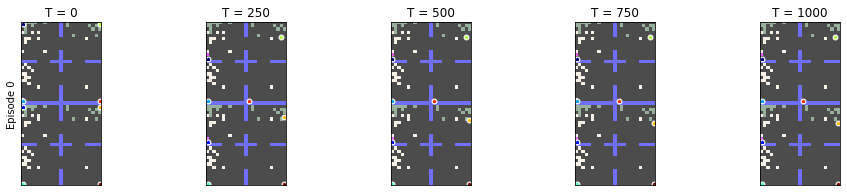

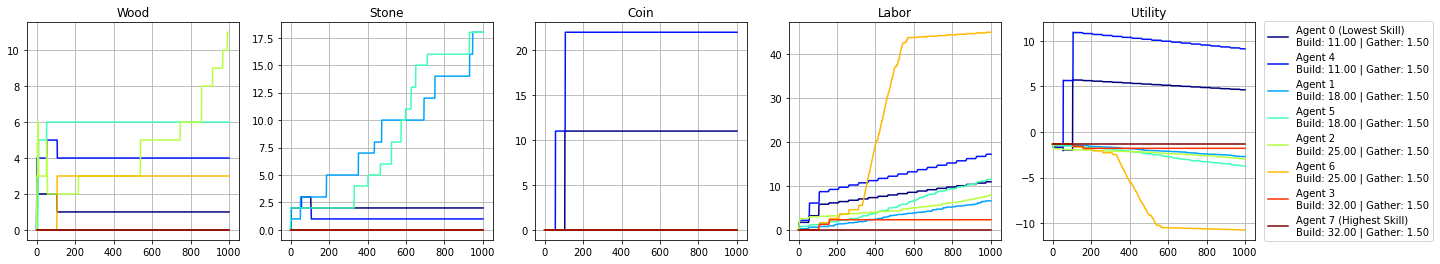

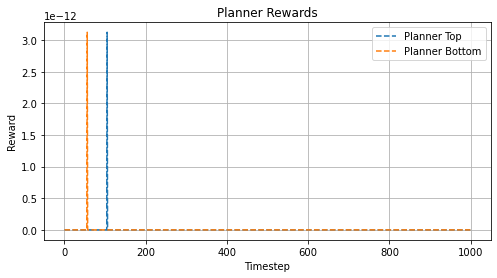

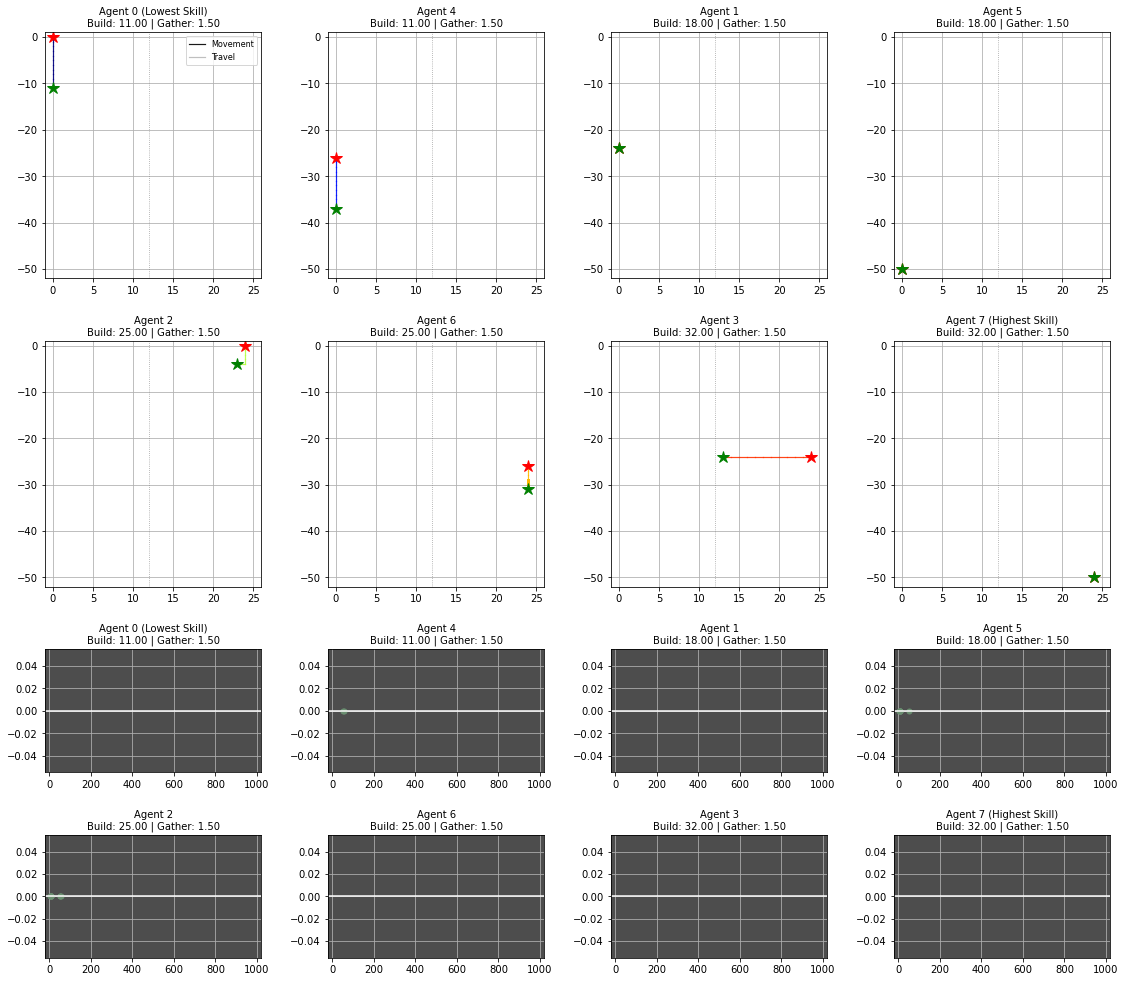

In [123]:
(fig0, fig1, fig1_planner, fig2), incomes1, endows1, c_trades1, all_builds1 = plotting.breakdown_all_agents(
    dense_logs_phase1[0],
    remap_key="build_payment",
    n_cols=4,
)

In [124]:
def print_agent_income_breakdown(incomes):
    print("=== Agent income breakdown ===")
    keys = list(incomes.keys())
    n = len(incomes[keys[0]])

    for i in range(n):
        row = {k: incomes[k][i] for k in keys}
        print(f"agent {i}: {row}")
        
print_agent_income_breakdown(incomes1)

=== Agent income breakdown ===
agent 0: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 11.0, 'Total': 11.0}
agent 1: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 22.0, 'Total': 22.0}
agent 2: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 0, 'Total': 0.0}
agent 3: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 0, 'Total': 0.0}
agent 4: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 0, 'Total': 0.0}
agent 5: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 0, 'Total': 0.0}
agent 6: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 0, 'Total': 0.0}
agent 7: {'Sell Stone': 0, 'Buy Stone': 0, 'Sell Wood': 0, 'Buy Wood': 0, 'Build': 0, 'Total': 0.0}


In [125]:
import numpy as np
import types
from ai_economist.foundation.scenarios.utils import social_metrics

# =========================================================
# Helpers
# =========================================================
def _split_row(env_obj):
    env = env_obj.env
    return int(getattr(env, "_overlay_water_row",
               getattr(env, "_water_line", env.world_size[0] // 2)))

def _agent_coin(agent):
    if hasattr(agent, "total_endowment") and callable(agent.total_endowment):
        return float(agent.total_endowment("Coin"))
    if hasattr(agent, "state") and isinstance(agent.state, dict):
        inv = float(agent.state.get("inventory", {}).get("Coin", 0.0))
        esc = float(agent.state.get("escrow", {}).get("Coin", 0.0))
        return inv + esc
    return 0.0

def _agent_rowcol(agent):
    if hasattr(agent, "loc"):
        return int(agent.loc[0]), int(agent.loc[1])
    return int(agent.state["loc"][0]), int(agent.state["loc"][1])

def _agent_dynamic_region(env_obj, agent):
    r, _ = _agent_rowcol(agent)
    return "top" if r < _split_row(env_obj) else "bottom"

def _planner_expected_region_from_id(planner_id):
    pid = str(planner_id)
    if "top" in pid:
        return "top"
    if "bottom" in pid:
        return "bottom"
    return None

def print_tax_component_config_fixed(env_obj):
    print("=== Tax component config ===")
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue
        pid = getattr(comp, "_planner_id", getattr(comp, "planner_id", None))
        print({
            "name": comp.name,
            "planner_id": pid,
            "expected_region_from_id": _planner_expected_region_from_id(pid),
            "disable_taxes": getattr(comp, "disable_taxes", None),
            "period": getattr(comp, "period", None),
        })

# =========================================================
# 1) Patch tax components to log EXACT coin changes caused
#    by EACH tax component, isolated at component level
# =========================================================
def patch_tax_components_for_debug_fixed(env_obj, tol=1e-9):
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue

        if hasattr(comp, "_orig_component_step_debug_fixed"):
            continue

        if not hasattr(comp, "component_step"):
            print(f"WARNING: {comp.name} has no component_step method to patch.")
            continue

        comp._orig_component_step_debug_fixed = comp.component_step

        def make_wrapper(c):
            def _wrapped_component_step(self, *args, **kwargs):
                before = {str(a.idx): _agent_coin(a) for a in self.world.agents}
                before_pos = {str(a.idx): _agent_rowcol(a) for a in self.world.agents}

                out = self._orig_component_step_debug_fixed(*args, **kwargs)

                after = {str(a.idx): _agent_coin(a) for a in self.world.agents}
                after_pos = {str(a.idx): _agent_rowcol(a) for a in self.world.agents}

                deltas = {
                    aid: after[aid] - before[aid]
                    for aid in before
                    if abs(after[aid] - before[aid]) > tol
                }

                self._last_debug_coin_deltas = deltas

                if deltas:
                    pid = getattr(self, "_planner_id", getattr(self, "planner_id", None))
                    expected_region = _planner_expected_region_from_id(pid)

                    print("\n=== TAX COMPONENT DEBUG ===")
                    print("component:", self.name)
                    print("planner_id:", pid)
                    print("expected_region_from_id:", expected_region)

                    detailed = {}
                    leaks = {}

                    for a in self.world.agents:
                        aid = str(a.idx)
                        if aid not in deltas:
                            continue

                        dyn_region = _agent_dynamic_region(env_obj, a)
                        detailed[aid] = {
                            "delta": deltas[aid],
                            "before_pos": before_pos[aid],
                            "after_pos": after_pos[aid],
                            "dynamic_region_after": dyn_region,
                        }

                        if expected_region is not None and dyn_region != expected_region:
                            leaks[aid] = detailed[aid]

                    print("affected_agents:", detailed)

                    if leaks:
                        print("POSSIBLE CROSS-REGION LEAK:", leaks)
                    else:
                        print("OK: all affected agents are in the planner's expected region.")

                return out
            return types.MethodType(_wrapped_component_step, c)

        comp.component_step = make_wrapper(comp)

def set_only_one_planner_tax_active(env_obj, active_planner_id):
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue
        pid = getattr(comp, "_planner_id", getattr(comp, "planner_id", None))
        comp.disable_taxes = (str(pid) != str(active_planner_id))

    print(f"Only {active_planner_id} tax component left active.")
    print_tax_component_config_fixed(env_obj)
# =========================================================
# 2) Rollout-level check:
#    Verify planner rewards match ONLY their own region welfare delta
# =========================================================
def debug_planner_reward_binding_fixed(
    trainer,
    env_obj,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
):
    def _compute_action(pid, obs, state):
        out = trainer.compute_action(
            observation=obs,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    def _regional_metric(region):
        coins = []
        for a in env_obj.env.world.agents:
            if _agent_dynamic_region(env_obj, a) == region:
                coins.append(_agent_coin(a))
        coins = np.asarray(coins, dtype=float)
        if len(coins) == 0:
            return 0.0
        n = len(coins)
        prod = social_metrics.get_productivity(coins) / n
        eq = equality_weight * social_metrics.get_equality(coins) + (1 - equality_weight)
        return float(eq * prod)

    obs = env_obj.reset(force_dense_logging=False)

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    print_tax_component_config_fixed(env_obj)

    for t in range(max_steps):
        tax_now = is_tax_day(env_obj)

        if tax_now:
            top_before = _regional_metric("top")
            bot_before = _regional_metric("bottom")

        actions = {}
        for i in range(env_obj.env.n_agents):
            aid = str(i)
            a, ns = _compute_action("a", obs[aid], agent_states[aid])
            actions[aid] = a
            agent_states[aid] = ns

        a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
        a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
        actions["p_top"] = a_top
        actions["p_bottom"] = a_bottom

        obs, rew, done, info = env_obj.step(actions)

        if tax_now:
            top_after = _regional_metric("top")
            bot_after = _regional_metric("bottom")

            expected_top = top_after - top_before
            expected_bot = bot_after - bot_before
            got_top = float(rew.get("p_top", np.nan))
            got_bot = float(rew.get("p_bottom", np.nan))

            print("\n=== PLANNER REWARD DEBUG ===")
            print(f"step={t}")
            print(f"expected p_top reward: {expected_top:.8f}")
            print(f"got      p_top reward: {got_top:.8f}")
            print(f"expected p_bottom reward: {expected_bot:.8f}")
            print(f"got      p_bottom reward: {got_bot:.8f}")

            print(
                "OK p_top" if np.isclose(got_top, expected_top, atol=1e-6, rtol=1e-6)
                else "MISMATCH p_top"
            )
            print(
                "OK p_bottom" if np.isclose(got_bot, expected_bot, atol=1e-6, rtol=1e-6)
                else "MISMATCH p_bottom"
            )

        if done.get("__all__", False):
            print("episode ended")
            break

In [126]:
patch_tax_components_for_debug_fixed(env_obj_phase2)
debug_planner_reward_binding_fixed(
    trainer=trainer_phase2,
    env_obj=env_obj_phase2,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
)

=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': False, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': False, 'period': 100}

=== PLANNER REWARD DEBUG ===
step=0
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p_bottom reward: 0.00000000
OK p_top
OK p_bottom

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_top
expected_region_from_id: top
affected_agents: {'0': {'delta': -2.25, 'before_pos': (8, 0), 'after_pos': (8, 0), 'dynamic_region_after': 'top'}, '1': {'delta': 0.75, 'before_pos': (24, 0), 'after_pos': (24, 0), 'dynamic_region_after': 'top'}, '2': {'delta': 0.75, 'before_pos': (4, 23), 'after_pos': (4, 23), 'dynamic_region_after': 'top'}, '3': {'delta': 0.75, 'before_pos': (24, 24), 'after_pos': (24, 24), 'd

In [127]:
env_obj_phase2.reset(force_dense_logging=False)
patch_tax_components_for_debug_fixed(env_obj_phase2)
set_only_one_planner_tax_active(env_obj_phase2, "p_top")

debug_planner_reward_binding_fixed(
    trainer=trainer_phase2,
    env_obj=env_obj_phase2,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
)

Only p_top tax component left active.
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': False, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': True, 'period': 100}
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': False, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': True, 'period': 100}

=== PLANNER REWARD DEBUG ===
step=0
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p_bottom reward: 0.00000000
OK p_top
OK p_bottom

=== PLANNER REWARD DEBUG ===
step=100
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p

In [128]:
env_obj_phase2.reset(force_dense_logging=False)
patch_tax_components_for_debug_fixed(env_obj_phase2)
set_only_one_planner_tax_active(env_obj_phase2, "p_bottom")

debug_planner_reward_binding_fixed(
    trainer=trainer_phase2,
    env_obj=env_obj_phase2,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
)

Only p_bottom tax component left active.
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': True, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': False, 'period': 100}
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': True, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': False, 'period': 100}

=== PLANNER REWARD DEBUG ===
step=0
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p_bottom reward: 0.00000000
OK p_top
OK p_bottom

=== PLANNER REWARD DEBUG ===
step=100
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got    

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :   6.12 (n= 48) |   6.33 (n= 39) |   5.30 (n= 44) |   6.31 (n= 39) |   5.91 (n= 35) |   6.07 (n= 30) |   6.24 (n= 37) |   5.23 (n= 26)
Cost (Stone)   :   6.69 (n= 16) |   9.21 (n= 14) |   7.20 (n= 20) |   6.85 (n= 13) |   7.61 (n= 18) |   8.69 (n= 13) |   8.90 (n= 10) |   6.27 (n= 11)

Income (Wood)  :   5.61 (n= 44) |   6.10 (n= 41) |   5.97 (n= 31) |   6.22 (n= 45) |   5.07 (n= 28) |   7.25 (n= 32) |   5.64 (n= 45) |   5.81 (n= 32)
Income (Stone) :   5.86 (n= 14) |   8.50 (n= 16) |   8.24 (n= 17) |   8.31 (n= 13) |   7.72 (n= 18) |   7.11 (n= 18) |   7.89 (n=  9) |   7.30 (n= 10)
Income (Build) :  11.00 (n= 18) |  18.00 (n=  4) |  25.00 (n= 16) |  32.00 (n=  1) |  11.00 (n=  5) |  18.00 (n= 19) |  25.00 (n=  4) |    ~~~~~~~~   


((<Figure size 1152x216 with 5 Axes>,
  <Figure size 1152x288 with 4 Axes>,
  <Figure size 1152x576 with 8 Axes>),
 {'Sell Stone': [82, 136, 140, 108, 139, 128, 71, 73],
  'Buy Stone': [-107, -129, -144, -89, -137, -113, -89, -69],
  'Sell Wood': [247, 250, 185, 280, 142, 232, 254, 186],
  'Buy Wood': [-294, -247, -233, -246, -207, -182, -231, -136],
  'Build': [198.0, 72.0, 400.0, 32.0, 55.0, 342.0, 100.0, 0],
  'Total': array([126.,  82., 348.,  85.,  -8., 407., 105.,  54.])},
 [140, 141, 242, 150, 45, 287, 115, 76],
 {'Stone': [{'t': 42,
    't_ask': 42,
    't_bid': 4,
    'commodity': 'Stone',
    'buyer': 4,
    'bid': 0,
    'bid_lifetime': 38,
    'region': 'bottom',
    'seller': 4,
    'ask': 0,
    'ask_lifetime': 0,
    'price': 0,
    'cost': 0,
    'income': 0},
   {'t': 44,
    't_ask': 2,
    't_bid': 44,
    'commodity': 'Stone',
    'buyer': 4,
    'bid': 2,
    'bid_lifetime': 0,
    'region': 'bottom',
    'seller': 1,
    'ask': 1,
    'ask_lifetime': 42,
    'pric

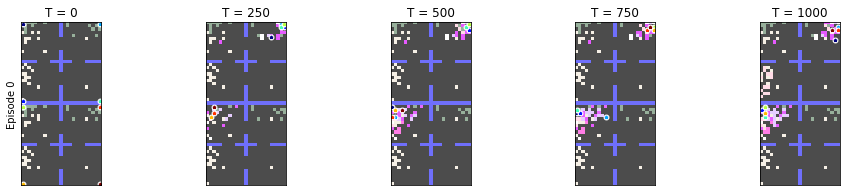

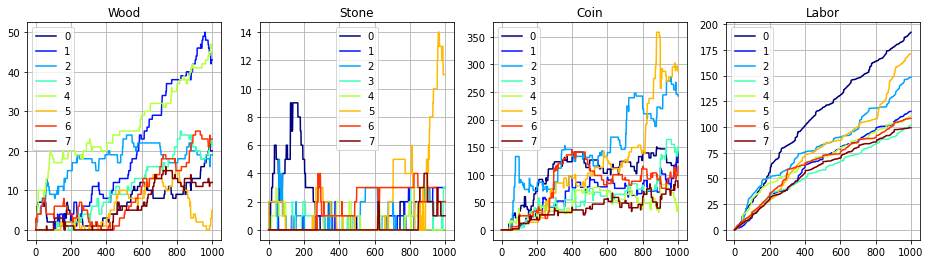

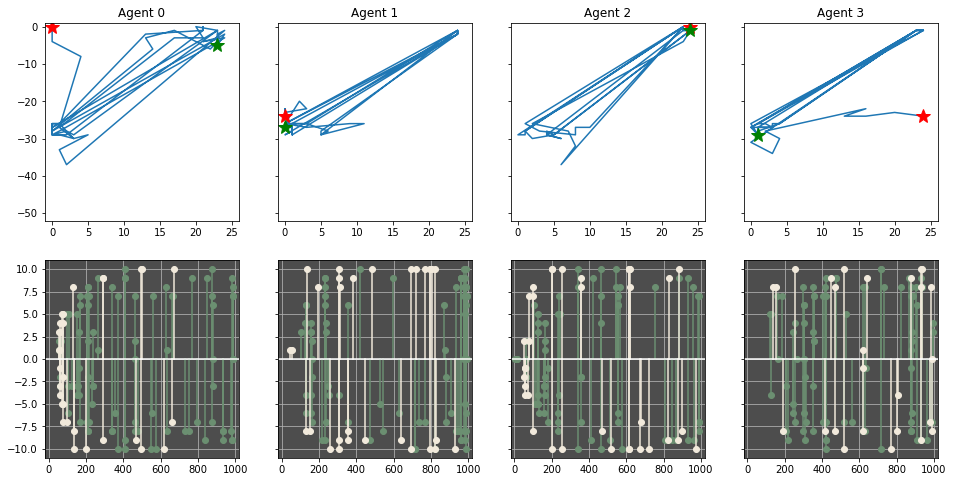

In [129]:
plotting.breakdown(dense_logs[0])

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :   5.93 (n= 43) |   6.00 (n= 35) |   7.17 (n= 29) |   6.75 (n= 16) |   6.93 (n= 44) |   6.61 (n= 31) |   6.72 (n= 25) |   6.27 (n= 22)
Cost (Stone)   :   8.00 (n=  9) |   4.71 (n= 14) |   8.75 (n=  4) |   9.33 (n=  3) |   8.00 (n=  3) |   9.17 (n=  6) |  10.00 (n=  1) |   8.00 (n=  1)

Income (Wood)  :   6.32 (n= 34) |   5.54 (n= 35) |   6.71 (n= 38) |   7.00 (n= 21) |   6.43 (n= 37) |   6.77 (n= 35) |   6.83 (n= 18) |   6.96 (n= 27)
Income (Stone) :   4.67 (n=  3) |   5.27 (n= 11) |   6.57 (n=  7) |   8.17 (n=  6) |   9.71 (n=  7) |  10.00 (n=  4) |   8.00 (n=  2) |   7.00 (n=  1)
Income (Build) :  11.00 (n= 20) |  11.00 (n= 13) |  18.00 (n=  5) |  18.00 (n=  3) |  25.00 (n=  8) |  25.00 (n=  3) |  32.00 (n=  2) |    ~~~~~~~~   


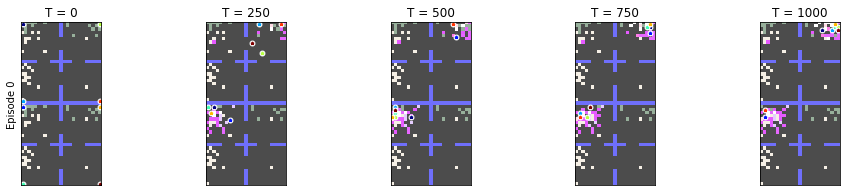

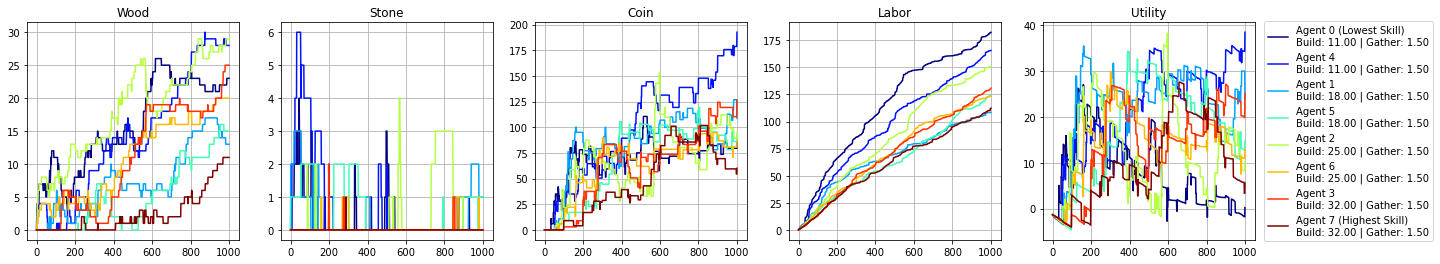

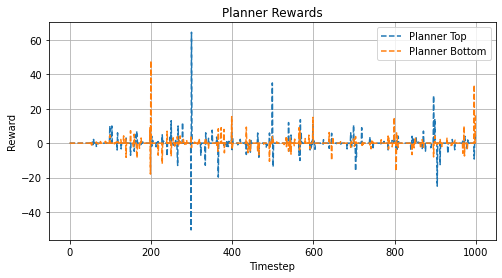

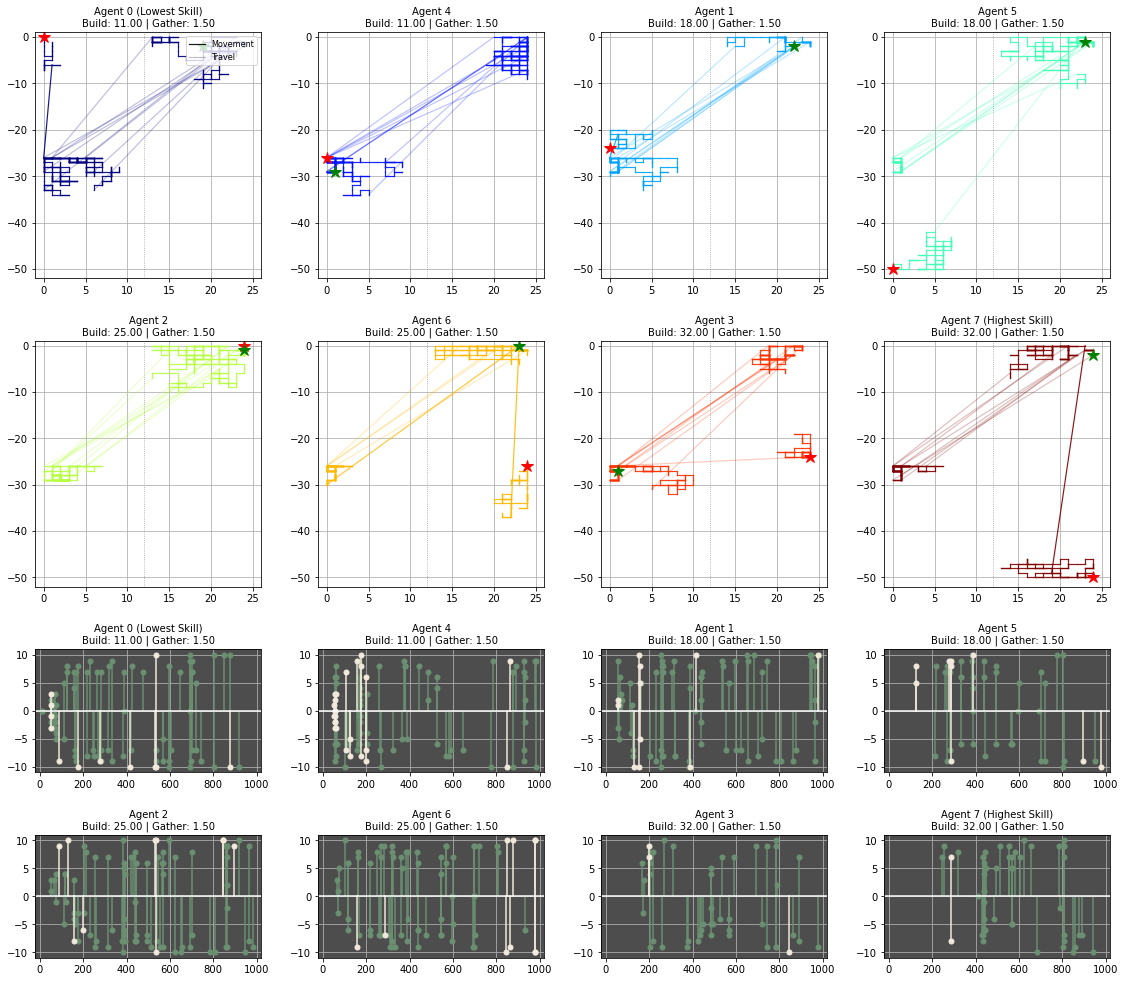

In [130]:
(fig0, fig1, fig1_planner, fig2), incomes, endows, c_trades, all_builds = plotting.breakdown_all_agents(
    dense_logs[1],
    #remap_key="build_payment",
    n_cols=4,
)

,tax_period,stone_trades,stone_avg_trade_price,stone_inventory_total,stone_escrow_total,stone_on_map,builds,build_income
0,0,19,3.444444,1.65,6.68,44.0,13,227.0
1,1,5,8.400000,7.68,0.52,40.0,8,109.0
2,2,7,9.571429,4.74,0.45,41.5,13,241.0
3,3,7,8.857143,4.10,0.29,42.0,10,180.0
4,4,12,9.272727,3.65,0.21,44.5,0,0.0
5,5,3,10.000000,5.52,0.00,45.5,0,0.0
6,6,20,7.833333,5.71,0.28,46.5,1,11.0
7,7,6,10.000000,10.07,0.03,46.0,6,122.0
8,8,15,8.800000,11.35,0.31,45.5,11,205.0
9,9,21,7.095238,18.87,0.74,36.5,5,104.0


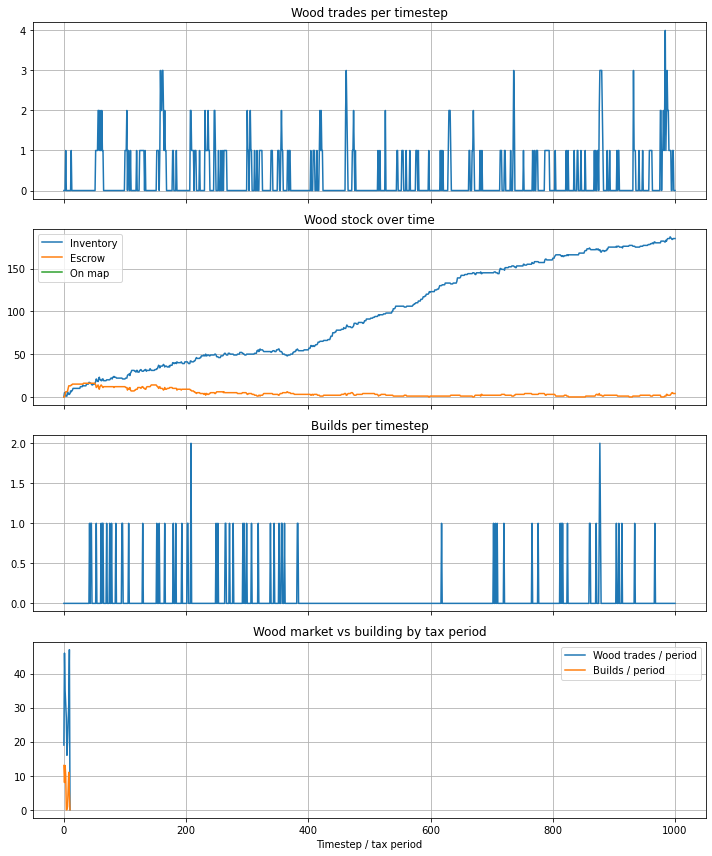

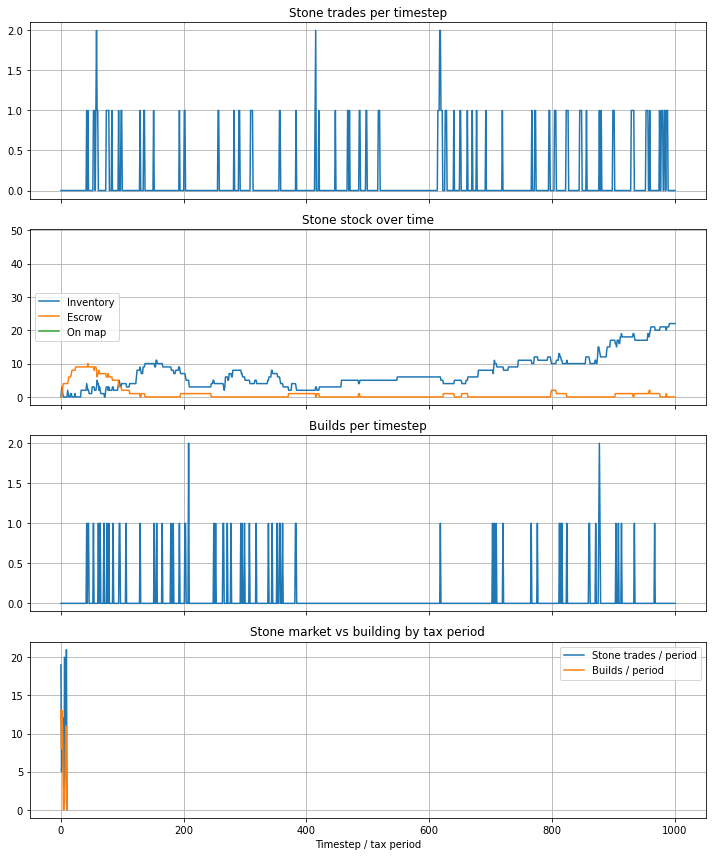

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def diagnose_resource_market(log, resource="Wood", period=100):
    """
    Diagnose why trading in a given resource slows or stops.

    Returns:
        df_timestep: timestep-level diagnostics
        df_period: tax-period aggregated diagnostics
        fig: diagnostic figure
    """
    n_steps = len(log["states"])

    # --- trades per timestep ---
    trade_count = np.zeros(n_steps, dtype=int)
    trade_price = np.full(n_steps, np.nan)
    buy_count = np.zeros(n_steps, dtype=int)
    sell_count = np.zeros(n_steps, dtype=int)

    if "Trade" in log:
        for t, trades in enumerate(log["Trade"]):
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            resource_trades = [tr for tr in trades_ if tr.get("commodity") == resource]

            trade_count[t] = len(resource_trades)
            if len(resource_trades) > 0:
                trade_price[t] = np.mean([tr["price"] for tr in resource_trades])
                buy_count[t] = len(resource_trades)
                sell_count[t] = len(resource_trades)

    # --- inventories over time ---
    total_inventory = np.zeros(n_steps, dtype=float)
    total_escrow = np.zeros(n_steps, dtype=float)

    for t, state in enumerate(log["states"]):
        total_inventory[t] = sum(
            state[str(aid)]["inventory"].get(resource, 0.0)
            for aid in [k for k in state.keys() if str(k).isdigit()]
        )
        total_escrow[t] = sum(
            state[str(aid)]["escrow"].get(resource, 0.0)
            for aid in [k for k in state.keys() if str(k).isdigit()]
        )

    # --- resource on map over time, if available ---
    resource_on_map = np.full(n_steps, np.nan)
    if "world" in log:
        for t in range(min(n_steps, len(log["world"]))):
            world_t = log["world"][t]
            if resource in world_t:
                resource_on_map[t] = np.sum(np.array(world_t[resource]))

    # --- build activity over time ---
    builds_per_t = np.zeros(n_steps, dtype=int)
    build_income_per_t = np.zeros(n_steps, dtype=float)

    if "Build" in log:
        for t, builds in enumerate(log["Build"]):
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            builds_per_t[t] = len(builds_)
            build_income_per_t[t] = sum(b.get("income", 0.0) for b in builds_)

    df_timestep = pd.DataFrame({
        "t": np.arange(n_steps),
        f"{resource.lower()}_trades": trade_count,
        f"{resource.lower()}_avg_trade_price": trade_price,
        f"{resource.lower()}_inventory_total": total_inventory,
        f"{resource.lower()}_escrow_total": total_escrow,
        f"{resource.lower()}_on_map": resource_on_map,
        "builds": builds_per_t,
        "build_income": build_income_per_t,
        "tax_period": np.arange(n_steps) // period,
    })

    df_period = df_timestep.groupby("tax_period").agg({
        f"{resource.lower()}_trades": "sum",
        f"{resource.lower()}_avg_trade_price": "mean",
        f"{resource.lower()}_inventory_total": "mean",
        f"{resource.lower()}_escrow_total": "mean",
        f"{resource.lower()}_on_map": "mean",
        "builds": "sum",
        "build_income": "sum",
    }).reset_index()

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    axes[0].plot(df_timestep["t"], df_timestep[f"{resource.lower()}_trades"])
    axes[0].set_title(f"{resource} trades per timestep")
    axes[0].grid(True)

    axes[1].plot(df_timestep["t"], df_timestep[f"{resource.lower()}_inventory_total"], label="Inventory")
    axes[1].plot(df_timestep["t"], df_timestep[f"{resource.lower()}_escrow_total"], label="Escrow")
    if not np.all(np.isnan(df_timestep[f"{resource.lower()}_on_map"])):
        axes[1].plot(df_timestep["t"], df_timestep[f"{resource.lower()}_on_map"], label="On map")
    axes[1].set_title(f"{resource} stock over time")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(df_timestep["t"], df_timestep["builds"])
    axes[2].set_title("Builds per timestep")
    axes[2].grid(True)

    axes[3].plot(df_period["tax_period"], df_period[f"{resource.lower()}_trades"], label=f"{resource} trades / period")
    axes[3].plot(df_period["tax_period"], df_period["builds"], label="Builds / period")
    axes[3].set_title(f"{resource} market vs building by tax period")
    axes[3].legend()
    axes[3].grid(True)
    axes[3].set_xlabel("Timestep / tax period")

    fig.tight_layout()
    return df_timestep, df_period, fig

df_wood_t, df_wood_p, fig = diagnose_resource_market(dense_logs[0], resource="Wood", period=100)
df_wood_p

df_stone_t, df_stone_p, fig = diagnose_resource_market(dense_logs[0], resource="Stone", period=100)
df_stone_p

In [132]:
import numpy as np
import pandas as pd

def tax_day_income_report(
    log,
    period=100,
    bracket_cutoffs=(0, 9.7, 39.475, 84.2, 160.725, 204.1, 510.3, np.inf),
):
    """
    Reconstructs per-agent income at each tax day and assigns tax brackets.

    Income is computed as change in coin endowment over the period:
        income_t = coin_t - coin_{t-period}

    Returns:
        df_agent: one row per agent per tax day
        df_counts: number of agents in each bracket at each tax day
    """

    def total_coin(state, aid):
        return (
            state[str(aid)]["inventory"].get("Coin", 0.0)
            + state[str(aid)]["escrow"].get("Coin", 0.0)
        )

    def get_region(state, aid):
        # Prefer explicit region if present
        if "region" in state[str(aid)]:
            return state[str(aid)]["region"]
        # fallback from row location
        row = state[str(aid)]["loc"][0]
        waterline = 25  # for 51x25 world split at row 25
        return "top" if row < waterline else "bottom"

    def bracket_label(x, cutoffs):
        for i in range(len(cutoffs) - 1):
            lo, hi = cutoffs[i], cutoffs[i + 1]
            if lo <= x < hi:
                hi_label = "inf" if np.isinf(hi) else f"{hi:.3f}"
                return f"[{lo:.3f}, {hi_label})"
        return "unknown"

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted([int(k) for k in first_state.keys() if str(k).isdigit()])

    # tax day assumed at end of each period: period-1, 2*period-1, ...
    tax_days = list(range(period - 1, len(states), period))

    rows = []
    prev_snapshot_idx = 0

    for td_idx, t in enumerate(tax_days):
        state_t = states[t]
        state_prev = states[prev_snapshot_idx]

        for aid in agent_ids:
            coin_now = total_coin(state_t, aid)
            coin_prev = total_coin(state_prev, aid)
            income = coin_now - coin_prev

            rows.append({
                "tax_day_number": td_idx + 1,
                "timestep": t,
                "agent": aid,
                "region": get_region(state_t, aid),
                "coin_start": coin_prev,
                "coin_end": coin_now,
                "income": income,
                "tax_bracket": bracket_label(income, bracket_cutoffs),
            })

        prev_snapshot_idx = t

    df_agent = pd.DataFrame(rows)

    df_counts = (
        df_agent.groupby(["tax_day_number", "region", "tax_bracket"])
        .size()
        .reset_index(name="n_agents")
        .sort_values(["tax_day_number", "region", "tax_bracket"])
    )

    return df_agent, df_counts

df_income, df_tax_counts = tax_day_income_report(dense_logs[0], period=100)
df_income.head(20)
df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[0.000, 9.700)",3
1,1,bottom,"[84.200, 160.725)",1
2,1,bottom,"[9.700, 39.475)",1
3,1,top,"[0.000, 9.700)",2
4,1,top,"[9.700, 39.475)",1
5,2,bottom,"[9.700, 39.475)",2
6,2,bottom,unknown,1
7,2,top,"[39.475, 84.200)",1
8,2,top,"[9.700, 39.475)",3
9,2,top,unknown,1


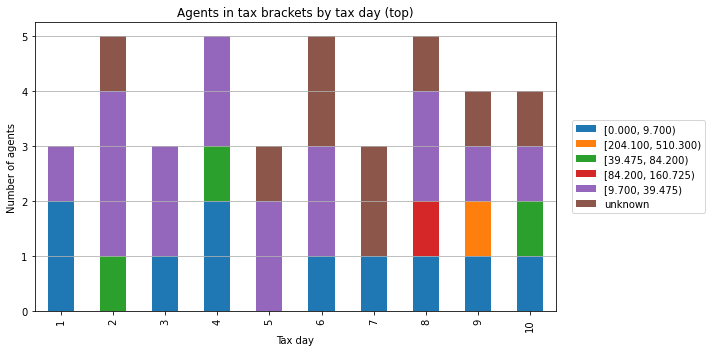

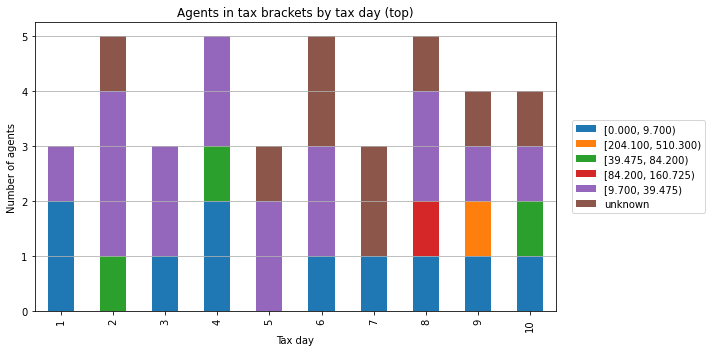

In [133]:
import matplotlib.pyplot as plt

def plot_tax_group_counts(df_counts, region=None):
    df = df_counts.copy()
    if region is not None:
        df = df[df["region"] == region]

    pivot = df.pivot_table(
        index="tax_day_number",
        columns="tax_bracket",
        values="n_agents",
        aggfunc="sum",
        fill_value=0,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax)

    title = "Agents in tax brackets by tax day"
    if region is not None:
        title += f" ({region})"
    ax.set_title(title)
    ax.set_xlabel("Tax day")
    ax.set_ylabel("Number of agents")
    ax.grid(True, axis="y")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    return fig, pivot

fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")
fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")

# comparison plots

In [134]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    "travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260402_105108",
    "travel-off__regionaltrade-on__layout-stacked_51x25__baseline_20260401_155830",
]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]

all_folders = sorted(os.listdir(BASE_RESULTS_DIR))
for i, folder in enumerate(all_folders):
    print(f"{i}: {folder}")

selected_idx = [0, 1, 2]

run_dirs_idx = [
    os.path.join(BASE_RESULTS_DIR, all_folders[i])
    for i in selected_idx
]

print(run_dirs)

0: travel-off__regionaltrade-on__layout-stacked_51x25__baseline_20260401_155830
1: travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260401_211748
2: travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260402_105108
['results\\travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260402_105108', 'results\\travel-off__regionaltrade-on__layout-stacked_51x25__baseline_20260401_155830']


In [135]:
runs = plotting.load_experiment_runs(run_dirs)

print([r["name"] for r in runs])

['travel-on__regionaltrade-on__layout-stacked_51x25__baseline', 'travel-off__regionaltrade-on__layout-stacked_51x25__baseline']


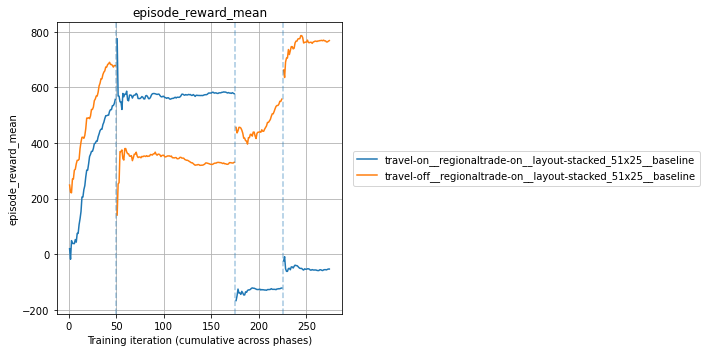

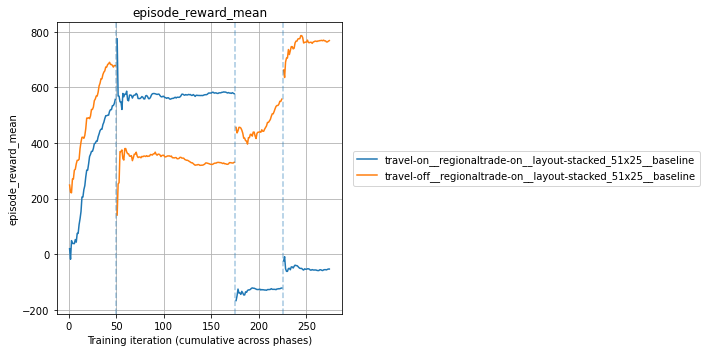

In [136]:
plotting.compare_training_curves(runs, metric="episode_reward_mean", by_phase=False)

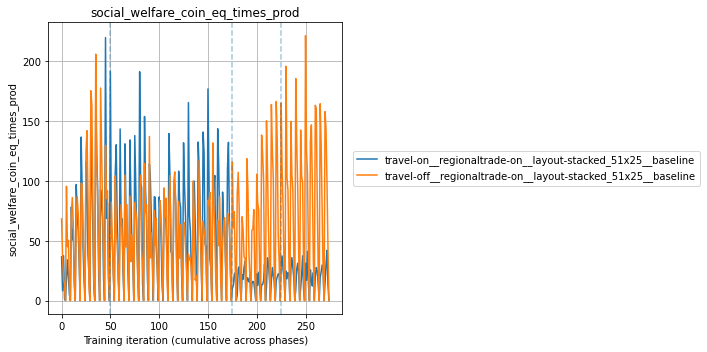

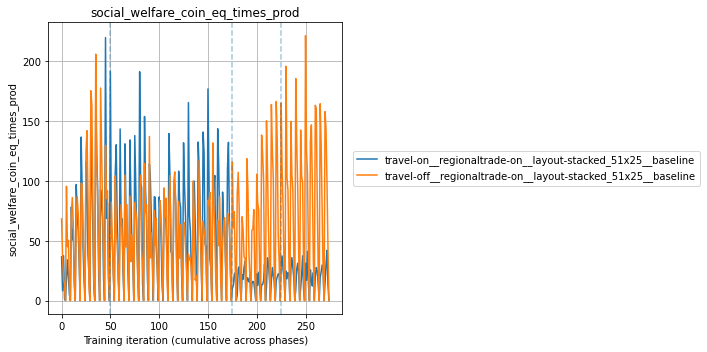

In [137]:
plotting.compare_training_curves(
    runs,
    metric="social_welfare_coin_eq_times_prod",
    by_phase=False
)

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-on__regionaltrade-on__layout-stacked_51x25__baseline,Travel all \n No open trade,32.183042,21.840357,167.27000,424,70,957.0,300,0,0,travel-on__regionaltrade-on__layout-stacked_51...,50,125,50,50
travel-off__regionaltrade-on__layout-stacked_51x25__baseline,No travel \n No open trade,257.894033,32.687438,205.72125,736,186,2712.0,0,0,0,travel-off__regionaltrade-on__layout-stacked_5...,50,125,50,50


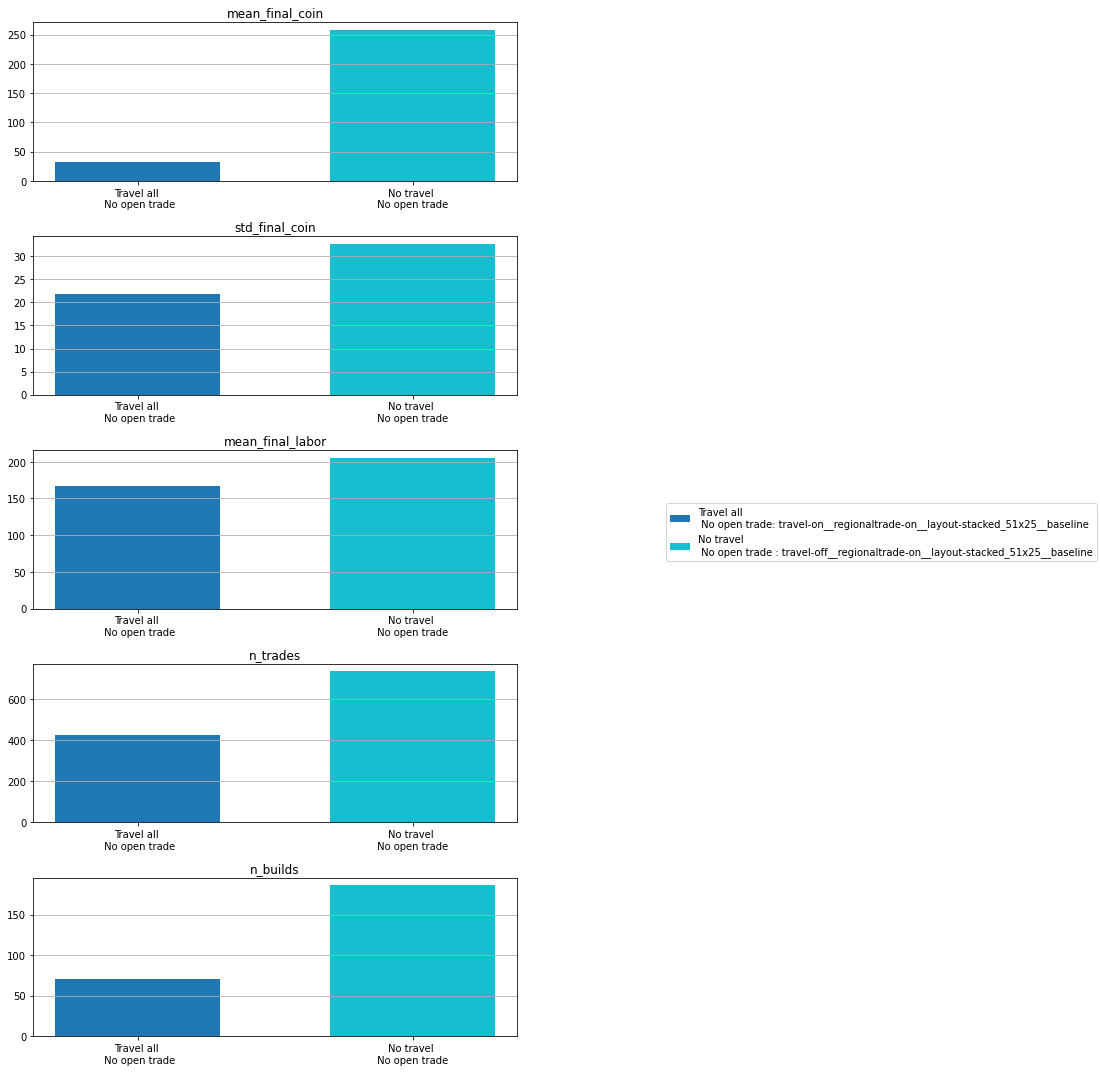

In [138]:

fig, summary_df = plotting.compare_summary_bars(
    runs,
    short_labels=["Travel all \n No open trade","No travel \n No open trade "]
)
summary_df

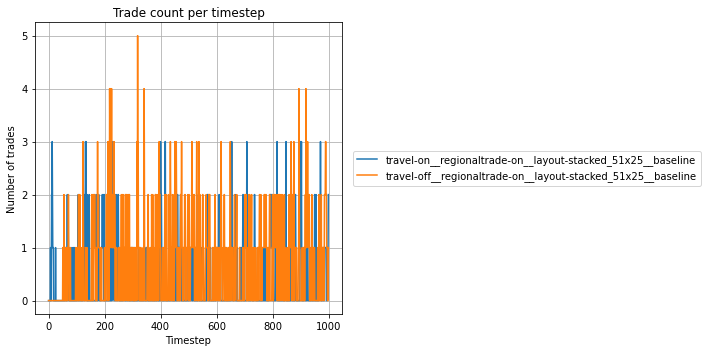

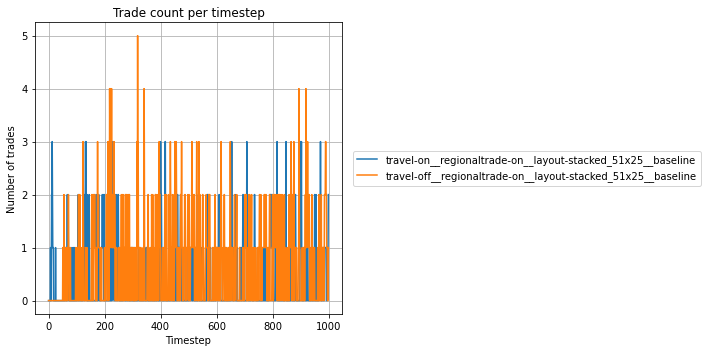

In [139]:
#plotting.compare_region_dynamics(runs)
plotting.compare_trade_dynamics(runs)

(<Figure size 504x288 with 1 Axes>,
                                                                           label  \
 travel-on__regionaltrade-on__layout-stacked_51x...  Travel all \n No open trade   
 travel-off__regionaltrade-on__layout-stacked_51...  No travel \n No open trade    
 
                                                         gini  
 travel-on__regionaltrade-on__layout-stacked_51x...  0.350207  
 travel-off__regionaltrade-on__layout-stacked_51...  0.067231  )

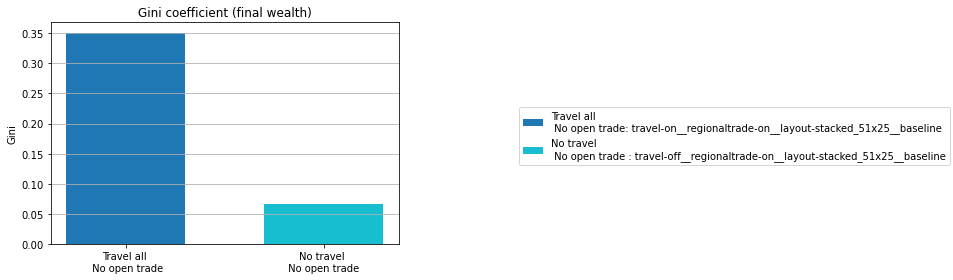

In [140]:
def compare_gini(runs, short_labels=None, show_legend=True):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    def gini(x):
        x = np.sort(x)
        n = len(x)
        return (2 * np.sum((np.arange(1, n+1) * x))) / (n * np.sum(x)) - (n + 1)/n

    data = {}

    for run in runs:
        final_state = run["dense_log"]["states"][-1]
        coins = []

        for k, s in final_state.items():
            if str(k).isdigit():
                coins.append(
                    s["inventory"]["Coin"] + s["escrow"]["Coin"]
                )

        data[run["name"]] = gini(np.array(coins))

    df = pd.Series(data)

    n_runs = len(df)

    # Short labels like E1, E2, ...
    if short_labels is None:
        short_labels = {name: f"E{i+1}" for i, name in enumerate(df.index)}
    else:
        if isinstance(short_labels, list):
            short_labels = {name: short_labels[i] for i, name in enumerate(df.index)}

    # Consistent colors
    cmap = plt.get_cmap("tab10", max(n_runs, 1))
    colors = {name: cmap(i) for i, name in enumerate(df.index)}

    fig, ax = plt.subplots(figsize=(7, 4))

    x = np.arange(len(df))

    ax.bar(
        x,
        df.values,
        color=[colors[name] for name in df.index],
        width=0.6,
    )

    ax.set_title("Gini coefficient (final wealth)")
    ax.set_xticks(x)
    ax.set_xticklabels([short_labels[name] for name in df.index])
    ax.set_ylabel("Gini")
    ax.grid(True, axis="y")

    if show_legend:
        legend_handles = [
            Patch(facecolor=colors[name], label=f"{short_labels[name]}: {name}")
            for name in df.index
        ]
        fig.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
        )

    fig.tight_layout(rect=[0, 0, 0.82, 1] if show_legend else [0, 0, 1, 1])

    # Return cleaner dataframe
    out_df = df.to_frame(name="gini")
    out_df.insert(0, "label", [short_labels[name] for name in out_df.index])

    return fig, out_df

compare_gini(
    runs,
    short_labels=["Travel all \n No open trade", "No travel \n No open trade "]
)


# Figuring out agent movement

In [141]:
import numpy as np

def diagnose_agent_activity(dense_log):
    states = dense_log["states"]
    n_steps = len(states) - 1

    agent_ids = sorted([k for k in states[0].keys() if str(k).isdigit()], key=int)

    # Movement per agent
    move_per_agent = {}
    for aid in agent_ids:
        d = 0.0
        for t in range(1, len(states)):
            p0 = np.array(states[t-1][aid]["loc"], dtype=float)
            p1 = np.array(states[t][aid]["loc"], dtype=float)
            d += np.abs(p1 - p0).sum()
        move_per_agent[aid] = d

    # Final inventories
    final_coin = {}
    final_wood = {}
    final_stone = {}
    final_labor = {}
    for aid in agent_ids:
        s = states[-1][aid]
        final_coin[aid] = float(s["inventory"]["Coin"] + s["escrow"]["Coin"])
        final_wood[aid] = float(s["inventory"]["Wood"] + s["escrow"]["Wood"])
        final_stone[aid] = float(s["inventory"]["Stone"] + s["escrow"]["Stone"])
        final_labor[aid] = float(s["endogenous"]["Labor"])

    # Build count
    build_events = dense_log.get("Build", [])
    n_builds = 0
    for x in build_events:
        if isinstance(x, dict):
            n_builds += len(x.get("builds", []))
        else:
            n_builds += len(x)

    # Trade count
    trade_events = dense_log.get("Trade", [])
    n_trades = 0
    for x in trade_events:
        if isinstance(x, dict):
            n_trades += len(x.get("trades", []))
        else:
            n_trades += len(x)

    # Gather count, if present
    gather_events = dense_log.get("Gather", [])
    n_gathers = 0
    for x in gather_events:
        if isinstance(x, dict):
            # try common keys
            if "gathers" in x:
                n_gathers += len(x["gathers"])
            elif "events" in x:
                n_gathers += len(x["events"])
            else:
                n_gathers += 0
        elif isinstance(x, list):
            n_gathers += len(x)

    print("=== Activity summary ===")
    print("steps:", n_steps)
    print("total builds:", n_builds)
    print("total trades:", n_trades)
    print("total gathers:", n_gathers)
    print("avg movement per agent:", np.mean(list(move_per_agent.values())))
    print("movement per agent:", move_per_agent)
    print("final coin:", final_coin)
    print("final wood:", final_wood)
    print("final stone:", final_stone)
    print("final labor:", final_labor)
    print("total final coin:", sum(final_coin.values()))
    print("total final wood:", sum(final_wood.values()))
    print("total final stone:", sum(final_stone.values()))

    return {
        "steps": n_steps,
        "n_builds": n_builds,
        "n_trades": n_trades,
        "n_gathers": n_gathers,
        "move_per_agent": move_per_agent,
        "final_coin": final_coin,
        "final_wood": final_wood,
        "final_stone": final_stone,
        "final_labor": final_labor,
    }

In [142]:
stats = diagnose_agent_activity(dense_logs[0])

=== Activity summary ===
steps: 1000
total builds: 67
total trades: 413
total gathers: 220
avg movement per agent: 782.0
movement per agent: {'0': 958.0, '1': 707.0, '2': 841.0, '3': 702.0, '4': 775.0, '5': 851.0, '6': 710.0, '7': 712.0}
final coin: {'0': 140.01144124999996, '1': 141.02536111111112, '2': 242.65233499999997, '3': 150.39469444444447, '4': 45.31036111111112, '5': 287.41120583333327, '6': 115.3681475, '7': 76.82645374999998}
final wood: {'0': 20.0, '1': 43.0, '2': 19.0, '3': 21.0, '4': 46.0, '5': 5.0, '6': 23.0, '7': 12.0}
final stone: {'0': 0.0, '1': 3.0, '2': 2.0, '3': 3.0, '4': 0.0, '5': 11.0, '6': 2.0, '7': 1.0}
final labor: {'0': 192.08000000000138, '1': 115.20999999999854, '2': 148.47999999999934, '3': 101.5999999999988, '4': 110.7099999999987, '5': 171.15999999999988, '6': 108.4499999999988, '7': 99.26999999999907}
total final coin: 1198.9999999999998
total final wood: 189.0
total final stone: 22.0


In [143]:
def diagnose_stone_wood_flows(dense_log):
    gather_stone = 0
    gather_wood = 0

    for g in dense_log.get("Gather", []):
        events = g.get("gathers", []) if isinstance(g, dict) else g
        for ev in events:
            resource = ev.get("resource", ev.get("commodity", None))
            if resource == "Stone":
                gather_stone += 1
            elif resource == "Wood":
                gather_wood += 1

    trade_sell_stone = 0
    trade_buy_stone = 0
    trade_sell_wood = 0
    trade_buy_wood = 0

    for tr in dense_log.get("Trade", []):
        events = tr.get("trades", []) if isinstance(tr, dict) else tr
        for ev in events:
            commodity = ev.get("commodity", None)
            if commodity == "Stone":
                trade_sell_stone += 1
                trade_buy_stone += 1
            elif commodity == "Wood":
                trade_sell_wood += 1
                trade_buy_wood += 1

    build_events = 0
    for b in dense_log.get("Build", []):
        events = b.get("builds", []) if isinstance(b, dict) else b
        build_events += len(events)

    print("=== Resource event counts ===")
    print("gather_stone:", gather_stone)
    print("gather_wood:", gather_wood)
    print("trade_sell_stone:", trade_sell_stone)
    print("trade_buy_stone:", trade_buy_stone)
    print("trade_sell_wood:", trade_sell_wood)
    print("trade_buy_wood:", trade_buy_wood)
    print("build_events:", build_events)

    return {
        "gather_stone": gather_stone,
        "gather_wood": gather_wood,
        "trade_sell_stone": trade_sell_stone,
        "trade_buy_stone": trade_buy_stone,
        "trade_sell_wood": trade_sell_wood,
        "trade_buy_wood": trade_buy_wood,
        "build_events": build_events,
    }

In [144]:
resource_stats = diagnose_stone_wood_flows(dense_logs[0])

=== Resource event counts ===
gather_stone: 58
gather_wood: 162
trade_sell_stone: 115
trade_buy_stone: 115
trade_sell_wood: 298
trade_buy_wood: 298
build_events: 67


In [145]:
# CKPT_EARLY = r"...\checkpoint-050"
# CKPT_LATE  = r"...\checkpoint-100"

# def rollout_from_ckpt(ckpt_path):
#     trainer = PPOTrainer(config=trainer_config_phase2)
#     trainer.restore(ckpt_path)

#     patch_trainer_envs(trainer, min_band=MIN_BAND)

#     logs = generate_rollout_with_planner_actions(
#         trainer=trainer,
#         env_obj=env_obj_phase2,
#         num_dense_logs=1,
#         explore=False,
#         decision_only=True
#     )

#     trainer.stop()
#     return logs[0]

# log_early = rollout_from_ckpt(CKPT_EARLY)
# log_late  = rollout_from_ckpt(CKPT_LATE)

# print("EARLY")
# diagnose_agent_activity(log_early)

# print("\nLATE")
# diagnose_agent_activity(log_late)

## end

# Plot


In [146]:
def plot_mobile_agent_actions(log):
    import numpy as np
    import matplotlib.pyplot as plt

    states = log["states"]
    T = len(states)

    agent_ids = sorted([k for k in states[0].keys() if str(k).isdigit()], key=int)
    n = len(agent_ids)

    # --- Movement (distance per step) ---
    movement = {aid: [] for aid in agent_ids}
    for t in range(1, T):
        for aid in agent_ids:
            p0 = np.array(states[t-1][aid]["loc"])
            p1 = np.array(states[t][aid]["loc"])
            movement[aid].append(np.abs(p1 - p0).sum())

    # --- Gather events ---
    gather_counts = np.zeros(T)
    for t, g in enumerate(log.get("Gather", [])):
        if isinstance(g, dict):
            if "gathers" in g:
                gather_counts[t] = len(g["gathers"])
        elif isinstance(g, list):
            gather_counts[t] = len(g)

    # --- Build events ---
    build_counts = np.zeros(T)
    for t, b in enumerate(log.get("Build", [])):
        if isinstance(b, dict):
            build_counts[t] = len(b.get("builds", []))
        elif isinstance(b, list):
            build_counts[t] = len(b)

    # --- Trade events ---
    trade_counts = np.zeros(T)
    for t, tr in enumerate(log.get("Trade", [])):
        if isinstance(tr, dict):
            trade_counts[t] = len(tr.get("trades", []))
        elif isinstance(tr, list):
            trade_counts[t] = len(tr)

    # =========================
    # Plot
    # =========================
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    # Movement
    for aid in agent_ids:
        axes[0].plot(movement[aid], label=f"agent {aid}")
    axes[0].set_title("Movement per step")
    axes[0].legend()
    axes[0].grid(True)

    # Gather
    axes[1].plot(gather_counts)
    axes[1].set_title("Gather events per step")
    axes[1].grid(True)

    # Build
    axes[2].plot(build_counts)
    axes[2].set_title("Build events per step")
    axes[2].grid(True)

    # Trade
    axes[3].plot(trade_counts)
    axes[3].set_title("Trade events per step")
    axes[3].set_xlabel("Timestep")
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    return fig

In [147]:
# plot_mobile_agent_actions(dense_logs[0])
# plot_mobile_agent_actions(dense_logs[2])

In [148]:
arr_top = dense_logs[0]["planner_actions"]["p_top"]
arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

print("p_top active half unique:", np.unique(arr_top[:, :7], axis=0).shape[0])
print("p_top inactive half unique:", np.unique(arr_top[:, 7:], axis=0).shape[0])

print("p_bottom inactive half unique:", np.unique(arr_bot[:, :7], axis=0).shape[0])
print("p_bottom active half unique:", np.unique(arr_bot[:, 7:], axis=0).shape[0])

print("p_top active rows:\n", arr_top[:, :7])
print("p_bottom active rows:\n", arr_bot[:, 7:])

p_top active half unique: 10
p_top inactive half unique: 10
p_bottom inactive half unique: 10
p_bottom active half unique: 10
p_top active rows:
 [[ 6 12 13  9  5  6  0]
 [ 9  3 20 13  8  5  4]
 [13 10  2  1  9  5 14]
 [11 13 13 14 20  9 11]
 [ 1 16 12 17  4  3 20]
 [ 6  8  2 17 10 20  1]
 [13  5  8  6 16 21 17]
 [ 4 15 17  3  3 19  4]
 [ 2 10 13 16 21  7  3]
 [21 19  8  5  3 13 17]]
p_bottom active rows:
 [[ 6 16 10 13 14  7 21]
 [13 20  9 10  3 17 13]
 [ 5  1 15  2  5 16  4]
 [10 21 17  9 10 21 13]
 [16 21  9 19 17  6 19]
 [17 21  0 19 17 13  9]
 [ 4 20 17 15 19 18 11]
 [12 16  1 20  1  9  6]
 [16 17  4 14 20 20 21]
 [ 3 12 15 16 15  9 16]]


# new code

In [149]:
# import numpy as np

# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10,
#     explore=False,
#     log_only_tax_days=False,   # True = log only on period starts (tax decision steps)
# ):
#     """
#     Roll out episodes and record planner actions & rewards into dense_logs.
#     Deep-copies planner actions to avoid the 'same array repeated' issue.

#     Returns:
#       dense_logs: dict[ep] … includes:
#         dense_logs[ep]["planner_actions"] = {
#             "p_top":    np.ndarray[T, S],   # S=14 in your setup (top7|bottom7)
#             "p_bottom": np.ndarray[T, S],
#         }
#         dense_logs[ep]["planner_rewards"] = {"p_top": list[T], "p_bottom": list[T]}
#     """
#     # Detect tax period
#     try:
#         period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
#     except StopIteration:
#         period = 100

#     def _compute_action(policy_id, obs, state):
#         """Return (action, next_state) handling RLlib's return formats."""
#         out = trainer.compute_action(
#             observation=obs,
#             state=state,
#             policy_id=policy_id,
#             full_fetch=False,
#             explore=explore,
#         )
#         if isinstance(out, tuple):
#             if len(out) >= 2:
#                 return out[0], out[1]
#             else:
#                 return out[0], state
#         return out, state

#     dense_logs = {}

#     for ep in range(num_dense_logs):
#         obs = env_obj.reset(force_dense_logging=True)

#         agent_states = {
#             str(i): trainer.get_policy("a").get_initial_state()
#             for i in range(env_obj.env.n_agents)
#         }
#         p_top_state    = trainer.get_policy("p_top").get_initial_state()
#         p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

#         p_top_actions, p_bottom_actions = [], []
#         p_top_rewards, p_bottom_rewards = [], []

#         for t in range(env_obj.env.episode_length):
#             actions = {}

#             # Agents
#             for i in range(env_obj.env.n_agents):
#                 aid = str(i)
#                 a, ns = _compute_action("a", obs[aid], agent_states[aid])
#                 actions[aid] = a
#                 agent_states[aid] = ns

#             # Planners
#             a_top,    p_top_state    = _compute_action("p_top",    obs["p_top"],    p_top_state)
#             a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
#             actions["p_top"]    = a_top
#             actions["p_bottom"] = a_bottom

#             # Log only on tax decision steps if requested
#             should_log = True if not log_only_tax_days else (t % period == 0)

#             if should_log:
#                 # CRITICAL: deep-copy to avoid aliasing
#                 p_top_actions.append(np.array(a_top, copy=True))
#                 p_bottom_actions.append(np.array(a_bottom, copy=True))

#             # Step env
#             obs, rew, done, info = env_obj.step(actions)

#             p_top_rewards.append(rew.get("p_top", np.nan))
#             p_bottom_rewards.append(rew.get("p_bottom", np.nan))

#             if done.get("__all__", False):
#                 break

#         # Stack (or empty)
#         p_top_arr    = np.stack(p_top_actions, axis=0)    if len(p_top_actions)    else np.zeros((0, 0), dtype=np.int64)
#         p_bottom_arr = np.stack(p_bottom_actions, axis=0) if len(p_bottom_actions) else np.zeros((0, 0), dtype=np.int64)

#         # Attach to dense log
#         dense_logs[ep] = dict(env_obj.env.dense_log)
#         dense_logs[ep]["planner_actions"] = {"p_top": p_top_arr, "p_bottom": p_bottom_arr}
#         dense_logs[ep]["planner_rewards"] = {"p_top": p_top_rewards, "p_bottom": p_bottom_rewards}

#     return dense_logs

In [150]:
def _get_disc_rates(env_obj):
    """Read the discrete marginal rates from the first BracketTax component."""
    for comp in env_obj.env.components:
        if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
            return np.array(comp.disc_rates, dtype=float)
    # Fallback to 0..1 in 5% steps if not found
    return np.arange(0.0, 1.0 + 1e-9, 0.05)

def _split_top_bottom_matrix(A, top_first=True):
    """
    Split an (T, S) matrix (S=14) into two (T,7) views: top7 and bottom7.
    If S==7 (unlikely for your setup), returns (A, A) conservatively.
    """
    if A.size == 0:
        return A, A
    T, S = A.shape
    if S % 2 != 0:
        # Unexpected; best-effort: treat A as top7 and clone to bottom7
        return A, A
    half = S // 2
    if top_first:
        return A[:, :half], A[:, half:]
    else:
        return A[:, half:], A[:, :half]

In [151]:
import matplotlib.pyplot as plt

def plot_planner_tax_lines_percent_from_dense(
    dense_log,
    env_obj,
    brackets,
    period=100,
    top_first=True,
    title="Planner tax choices over time (marginal rate)",
    figsize=(14, 10),
):
    """
    7-row plot: each row = bracket; blue = p_top, orange dashed = p_bottom.
    Y-axis: marginal tax rate (0..1), mapped from env's disc_rates.
    X-axis: index of logged decisions (if you logged only tax days).
    """
    actions_top  = dense_log["planner_actions"]["p_top"]     # (T, 14)
    actions_bot  = dense_log["planner_actions"]["p_bottom"]  # (T, 14)

    # If you logged only tax days, T ~= episode_length / period
    # If you logged every step, X will be per-step index (can still plot)
    X = np.arange(actions_top.shape[0])

    # Split into top7 and bottom7
    top7_top, bottom7_top     = _split_top_bottom_matrix(actions_top, top_first=top_first)
    top7_bottom, bottom7_bottom = _split_top_bottom_matrix(actions_bot, top_first=top_first)

    # For plotting we want: p_top uses its own top7; p_bottom uses its own bottom7
    mat_top    = top7_top      # (T,7) chosen by p_top
    mat_bottom = bottom7_bottom  # (T,7) chosen by p_bottom

    # Map indices -> rates using env's disc_rates (robust)
    disc_rates = _get_disc_rates(env_obj)
    # Indices should be 0..len(disc_rates)-1; clip defensively:
    mat_top_r    = disc_rates[np.clip(mat_top,    0, len(disc_rates)-1)]
    mat_bottom_r = disc_rates[np.clip(mat_bottom, 0, len(disc_rates)-1)]

    # Plot 7 rows
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    for b in range(7):
        ax = axes[b]
        ax.plot(X, mat_top_r[:, b],    label="p_top",    lw=2, color="#1f77b4")
        ax.plot(X, mat_bottom_r[:, b], label="p_bottom", lw=2, color="#ff7f0e", ls="--")

        ax.set_ylabel(f"{brackets[b]:.2f}k")
        ax.set_ylim(0.0, 1.05*np.max(disc_rates))
        ax.grid(True, alpha=0.3)
        if b == 0:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Decision index" if actions_top.shape[0] <= (dense_log.get("world") and len(dense_log["world"])) else "Step")
    plt.tight_layout()
    plt.show()
    return fig

In [152]:
def plot_final_tax_schedules_two_planners_from_dense(
    dense_log,
    env_obj,
    brackets,
    top_first=True,
    title="Final Marginal Tax Schedules (p_top vs p_bottom)",
    figsize=(8, 7),
):
    """
    Final schedules from the last logged planner actions row.
    Step plots: top subplot = p_top; bottom subplot = p_bottom.
    """
    actions_top  = dense_log["planner_actions"]["p_top"]     # (T,14)
    actions_bot  = dense_log["planner_actions"]["p_bottom"]  # (T,14)
    if actions_top.size == 0 or actions_bot.size == 0:
        raise ValueError("No planner actions logged in dense_log.")

    last_top    = actions_top[-1]
    last_bottom = actions_bot[-1]

    # Split 14 -> 7+7
    top7_last_top, bottom7_last_top       = _split_top_bottom_matrix(last_top.reshape(1, -1), top_first=top_first)
    top7_last_bottom, bottom7_last_bottom = _split_top_bottom_matrix(last_bottom.reshape(1, -1), top_first=top_first)

    # We want p_top's top7 and p_bottom's bottom7
    idx_top    = top7_last_top[0]       # (7,)
    idx_bottom = bottom7_last_bottom[0] # (7,)

    # Map to rates
    disc_rates = _get_disc_rates(env_obj)
    top_rates    = disc_rates[np.clip(idx_top,    0, len(disc_rates)-1)]
    bottom_rates = disc_rates[np.clip(idx_bottom, 0, len(disc_rates)-1)]

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    axes[0].step(brackets, top_rates, where="post", color="#1f77b4")
    axes[0].fill_between(brackets, top_rates, step="post", alpha=0.3, color="#1f77b4")
    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region)")
    axes[0].set_ylim(0, 1.05*np.max(disc_rates))
    axes[0].grid(True)

    axes[1].step(brackets, bottom_rates, where="post", color="#ff7f0e")
    axes[1].fill_between(brackets, bottom_rates, step="post", alpha=0.3, color="#ff7f0e")
    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region)")
    axes[1].set_xlabel("Income bracket (k USD)")
    axes[1].set_ylim(0, 1.05*np.max(disc_rates))
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    return fig

In [153]:
# =========================================================
# Averege plots
# =========================================================

def plot_avg_planner_tax_lines(
    dense_logs,
    env_obj,
    brackets,
    top_first=True,
    figsize=(14, 10),
    title="Average planner tax choices (across episodes)"
):
    def _split(A):
        if A.size == 0:
            return A, A
        half = A.shape[1] // 2
        if top_first:
            return A[:, :half], A[:, half:]
        else:
            return A[:, half:], A[:, :half]

    # collect all episodes
    top_list = []
    bot_list = []

    for ep in dense_logs:
        A_top = dense_logs[ep]["planner_actions"]["p_top"]
        A_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

        if A_top.size == 0 or A_bot.size == 0:
            continue

        top7_top, _ = _split(A_top)
        _, bottom7_bot = _split(A_bot)

        top_list.append(top7_top)
        bot_list.append(bottom7_bot)

    # align lengths (in case episodes differ)
    min_T = min(a.shape[0] for a in top_list)

    top_stack = np.stack([a[:min_T] for a in top_list], axis=0)  # (E, T, 7)
    bot_stack = np.stack([a[:min_T] for a in bot_list], axis=0)

    # map indices -> rates
    def _get_disc_rates(env_obj):
        for comp in env_obj.env.components:
            if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
                return np.array(comp.disc_rates, dtype=float)
        return np.arange(0.0, 1.0 + 1e-9, 0.05)

    disc_rates = _get_disc_rates(env_obj)

    top_rates = disc_rates[np.clip(top_stack, 0, len(disc_rates)-1)]
    bot_rates = disc_rates[np.clip(bot_stack, 0, len(disc_rates)-1)]

    # average over episodes
    top_mean = np.mean(top_rates, axis=0)  # (T, 7)
    bot_mean = np.mean(bot_rates, axis=0)

    X = np.arange(top_mean.shape[0])

    # plot
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    for b in range(7):
        ax = axes[b]
        ax.plot(X, top_mean[:, b], label="p_top (avg)", lw=2)
        ax.plot(X, bot_mean[:, b], label="p_bottom (avg)", lw=2, linestyle="--")

        ax.set_ylabel(f"{brackets[b]:.2f}k")
        ax.set_ylim(0, 1.05*np.max(disc_rates))
        ax.grid(True, alpha=0.3)

        if b == 0:
            ax.legend()

    axes[-1].set_xlabel("Decision index")
    plt.tight_layout()
    plt.show()

    return fig


def plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs,
    env_obj,
    brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules (p_top vs p_bottom)",
    figsize=(8, 7),
):
    """
    Average final schedules across all dense_logs.
    Uses the last logged planner-action row from each episode.
    """
    def _split_last_row(arr, top_first=True):
        if arr.size == 0:
            return None, None
        last = arr[-1].reshape(1, -1)
        half = last.shape[1] // 2
        if top_first:
            return last[:, :half][0], last[:, half:][0]
        else:
            return last[:, half:][0], last[:, :half][0]

    idx_top_list = []
    idx_bottom_list = []

    for ep in dense_logs:
        actions_top = dense_logs[ep]["planner_actions"]["p_top"]
        actions_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

        if actions_top.size == 0 or actions_bot.size == 0:
            continue

        top7_last_top, _ = _split_last_row(actions_top, top_first=top_first)
        _, bottom7_last_bottom = _split_last_row(actions_bot, top_first=top_first)

        idx_top_list.append(top7_last_top)
        idx_bottom_list.append(bottom7_last_bottom)

    if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
        raise ValueError("No planner actions logged in dense_logs.")

    idx_top_arr = np.stack(idx_top_list, axis=0)         # (E, 7)
    idx_bottom_arr = np.stack(idx_bottom_list, axis=0)   # (E, 7)

    disc_rates = _get_disc_rates(env_obj)

    top_rates_all = disc_rates[np.clip(idx_top_arr, 0, len(disc_rates)-1)]
    bottom_rates_all = disc_rates[np.clip(idx_bottom_arr, 0, len(disc_rates)-1)]

    top_rates_mean = np.mean(top_rates_all, axis=0)
    bottom_rates_mean = np.mean(bottom_rates_all, axis=0)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    axes[0].step(brackets, top_rates_mean, where="post", color="#1f77b4")
    axes[0].fill_between(brackets, top_rates_mean, step="post", alpha=0.3, color="#1f77b4")
    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region) - average final schedule")
    axes[0].set_ylim(0, 1.05*np.max(disc_rates))
    axes[0].grid(True)

    axes[1].step(brackets, bottom_rates_mean, where="post", color="#ff7f0e")
    axes[1].fill_between(brackets, bottom_rates_mean, step="post", alpha=0.3, color="#ff7f0e")
    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region) - average final schedule")
    axes[1].set_xlabel("Income bracket (k USD)")
    axes[1].set_ylim(0, 1.05*np.max(disc_rates))
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    return fig

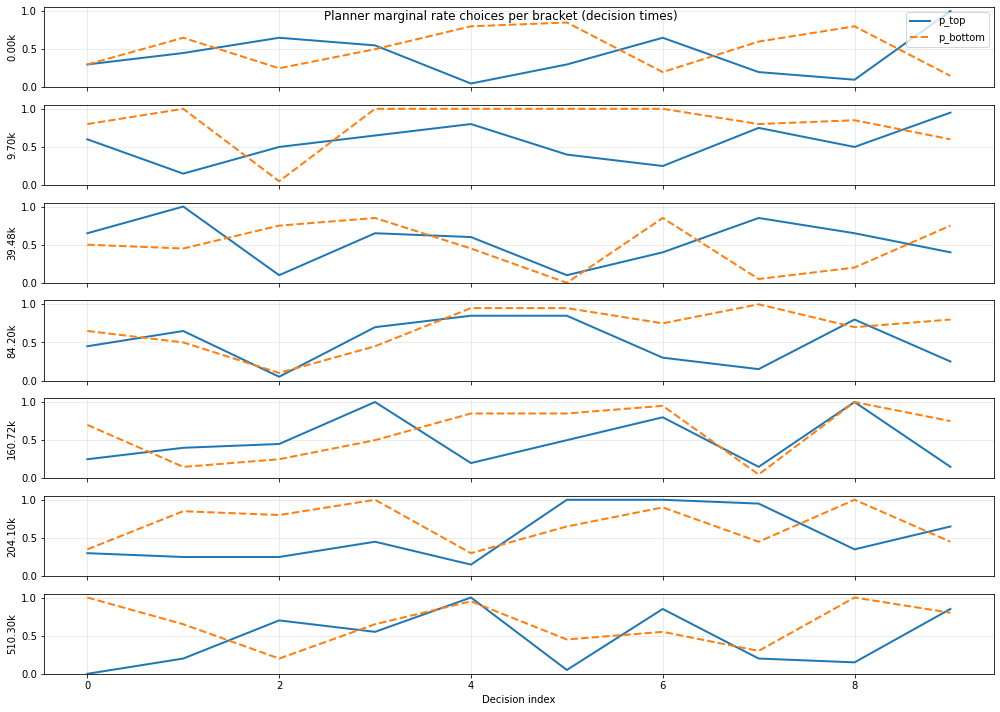

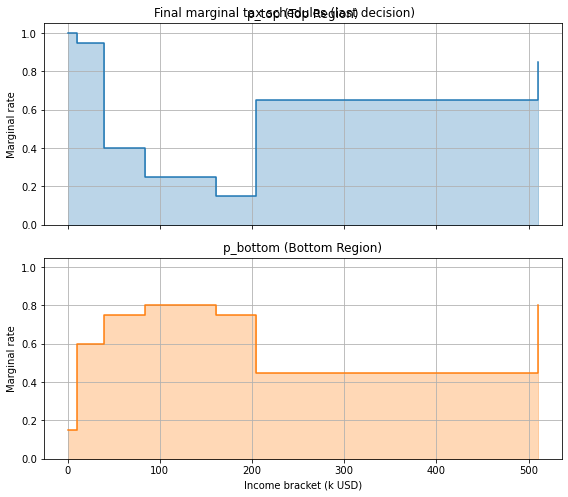

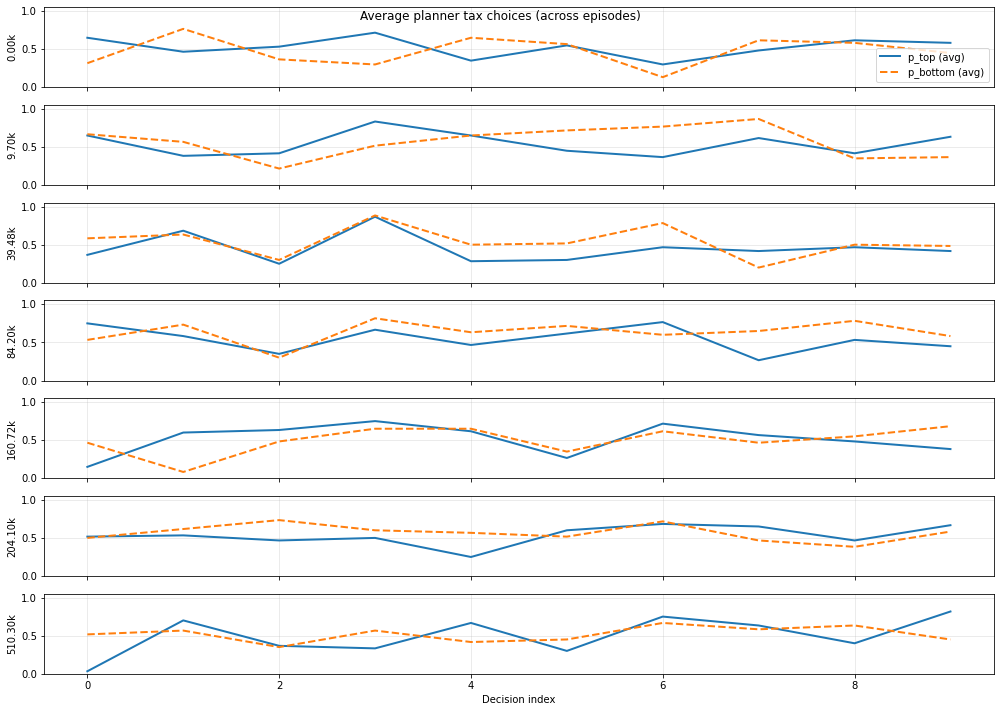

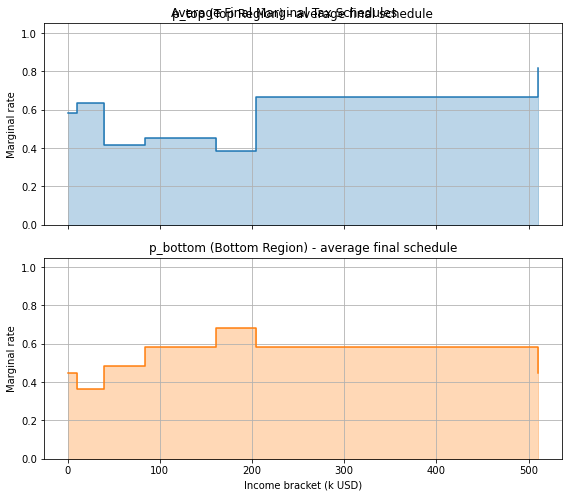

In [154]:
# import numpy as np
# import ray
# from ray.rllib.agents.ppo import PPOTrainer
# from tutorials.rllib.env_wrapper import RLlibEnvWrapper
# import matplotlib.pyplot as plt

# # =========================================================
# # CONFIG
# # =========================================================
# FRAMEWORK = "tf"

# # IMPORTANT:
# # Use a checkpoint produced by THIS exact code/config version.
# # Do NOT use an old checkpoint from before obs-space changes.
# #CKPT_PATH = r"C:\Users\adria\ray_results\PPO_RLlibEnvWrapper_2026-03-20_16-06-2092_n4vmg\checkpoint_250\checkpoint-250"
# #CKPT_PATH = r"C:\Users\adria\ray_results\...\checkpoint_1500\checkpoint-1500"
# CKPT_PATH = ckpt_phase2

# # =========================================================
# # RAY
# # =========================================================
# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# # =========================================================
# # BUILD EVAL ENV
# # =========================================================
# env_obj_phase2 = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase2},
#     verbose=False
# )

# # Patch standalone eval env
# patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)

# # =========================================================
# # POLICIES
# # =========================================================
# policies_eval = {
#     "a": (
#         None,
#         env_obj_phase2.observation_space,
#         env_obj_phase2.action_space,
#         {}
#     ),
#     "p_top": (
#         None,
#         env_obj_phase2.observation_space_pl["p_top"],
#         env_obj_phase2.action_space_pl["p_top"],
#         {}
#     ),
#     "p_bottom": (
#         None,
#         env_obj_phase2.observation_space_pl["p_bottom"],
#         env_obj_phase2.action_space_pl["p_bottom"],
#         {}
#     ),
# }

# def policy_mapping_fun_eval(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# trainer_config_phase2_eval = {
#     "env": RLlibEnvWrapper,
#     "env_config": {
#         "env_config_dict": env_config_dict_phase2,
#         "num_envs_per_worker": 1,
#     },
#     "multiagent": {
#         "policies": policies_eval,
#         "policies_to_train": [],
#         "policy_mapping_fn": policy_mapping_fun_eval,
#     },
#     "num_workers": 0,
#     "num_envs_per_worker": 1,
#     "framework": FRAMEWORK,
#     "num_gpus": 0,
#     "train_batch_size": 1000,
#     "sgd_minibatch_size": 1000,
#     "num_sgd_iter": 1,
#     "log_level": "WARN",
# }



# # =========================================================
# # RESTORE
# # =========================================================
# trainer_phase2_eval = PPOTrainer(config=trainer_config_phase2_eval)
# trainer_phase2_eval.restore(CKPT_PATH)

# # Patch restored trainer env(s) too
# patch_trainer_envs(trainer_phase2_eval, min_band=MIN_BAND)

# # =========================================================
# # ROLLOUTS
# # =========================================================
# dense_logs = generate_rollout_with_planner_actions(
#     # trainer=trainer_phase2_eval,
#     # env_obj=env_obj_phase2,
#         trainer=trainer_phase3b,
#     env_obj=env_obj_phase3b,
#     num_dense_logs=3,
#     explore=False,
#     log_only_tax_days=True,
# )

# dense_logs_explore = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2_eval,
#     env_obj=env_obj_phase2,
#     num_dense_logs=10,
#     explore=True,
#     log_only_tax_days=True,
# )

# # =========================================================
# # DEBUG PRINTS
# # =========================================================
# arr_top = dense_logs[0]["planner_actions"]["p_top"]
# arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# print("FULL p_top (#rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
# print("FULL p_bottom (#rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])

# print_active_planner_debug(dense_logs[0], top_first=True, max_rows=10)
# print_active_planner_rates(dense_logs[0], env_obj_phase2, top_first=True, max_rows=10)

# print_active_planner_debug(dense_logs_explore[0], top_first=True, max_rows=10)
# print_active_planner_rates(dense_logs_explore[0], env_obj_phase2, top_first=True, max_rows=10)

# # =========================================================
# # PLOTS
# # =========================================================
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

fig_time = plot_planner_tax_lines_percent_from_dense(
    dense_log=dense_logs[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    title="Planner marginal rate choices per bracket (decision times)"
)

fig_final = plot_final_tax_schedules_two_planners_from_dense(
    dense_log=dense_logs[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final marginal tax schedules (last decision)"
)

# Optional averages across episodes
fig_avg_time = plot_avg_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average planner tax choices (across episodes)"
)

fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules"
)

# # Optional activity check
# stats = diagnose_agent_activity(dense_logs_explore[0])

# # Optional cleanup
# # trainer_phase2_eval.stop()
# # ray.shutdown()

In [155]:
print(env_obj_phase2.observation_space)
print(env_obj_phase2.observation_space_pl["p_top"])
print(env_obj_phase2.observation_space_pl["p_bottom"])

Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (197,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 11, 11), int16), world-map:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (7, 11, 11), float32))
Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (308,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (134,), float32), p0:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p1:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p2:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p3:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p4:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p5:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p6:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,),

In [156]:
print("TRAIN agent obs:", env_obj_phase2.observation_space)
print("TRAIN p_top obs:", env_obj_phase2.observation_space_pl["p_top"])
print("TRAIN p_bottom obs:", env_obj_phase2.observation_space_pl["p_bottom"])

TRAIN agent obs: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (197,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 11, 11), int16), world-map:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (7, 11, 11), float32))
TRAIN p_top obs: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (308,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (134,), float32), p0:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p1:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p2:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p3:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p4:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p5:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p6:Box(-1.0000000200408773e

# No Exploration


In [157]:
dense_logs_no_ex = generate_rollout_with_planner_actions(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    num_dense_logs=30,
    explore=False, # concider setting to False down the line
    log_only_tax_days=True
)



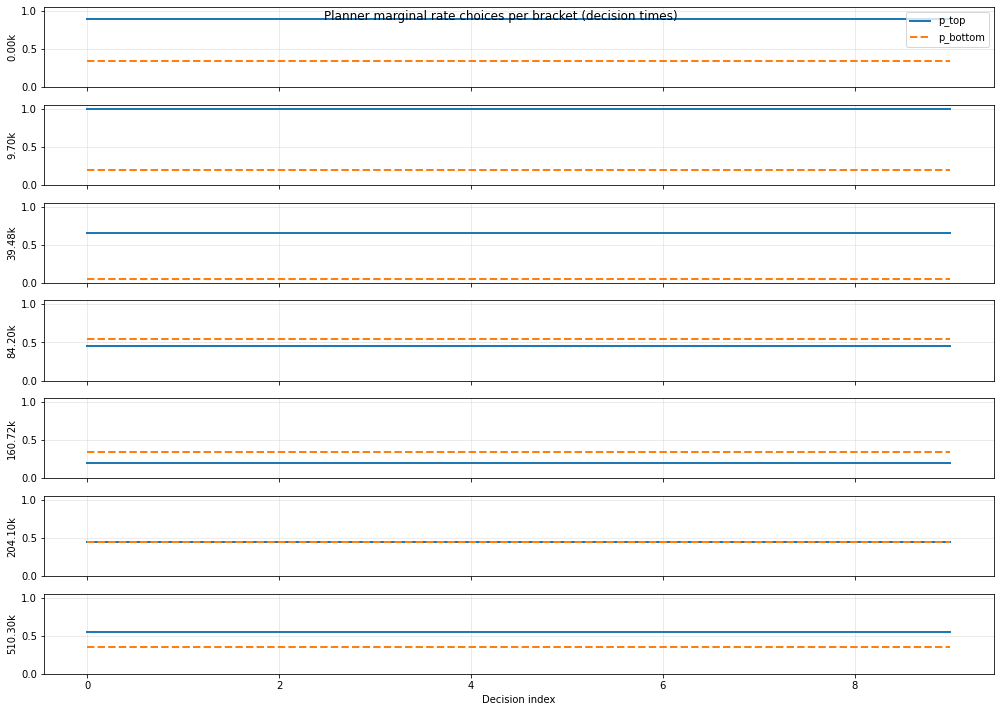

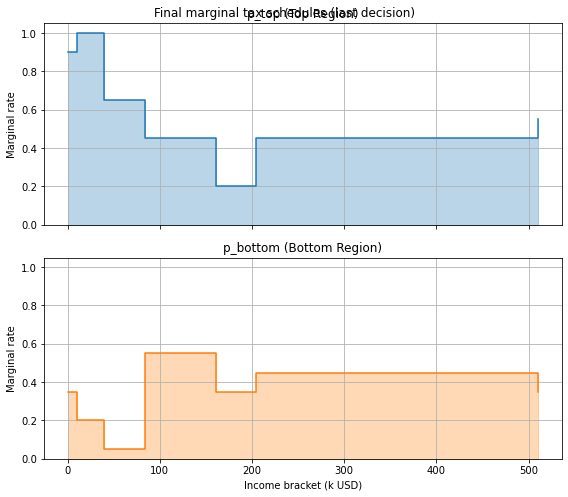

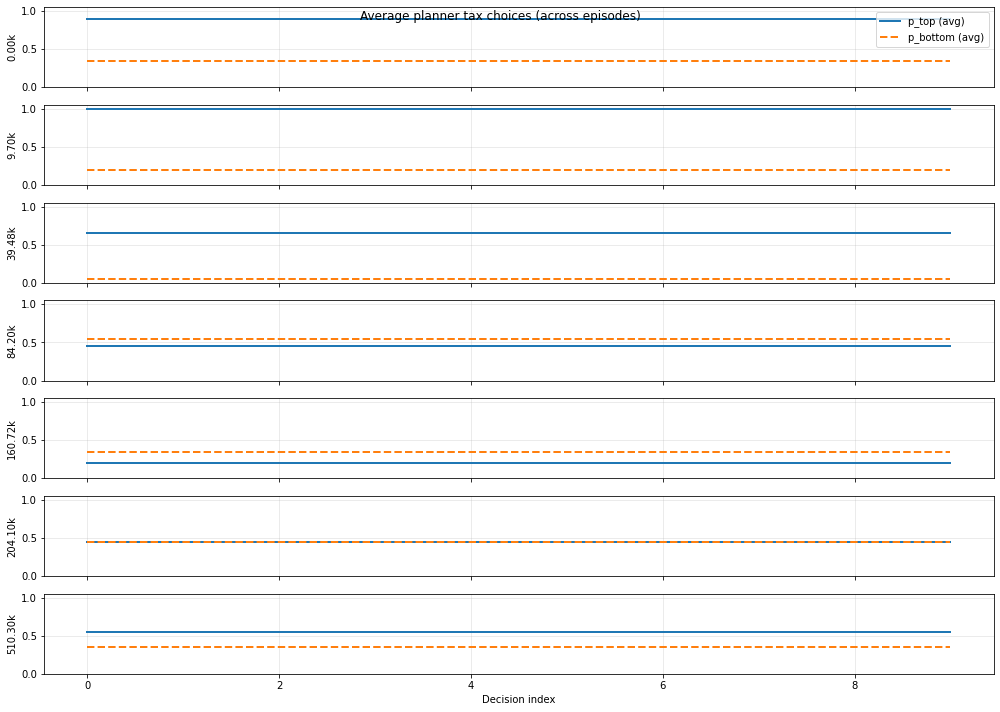

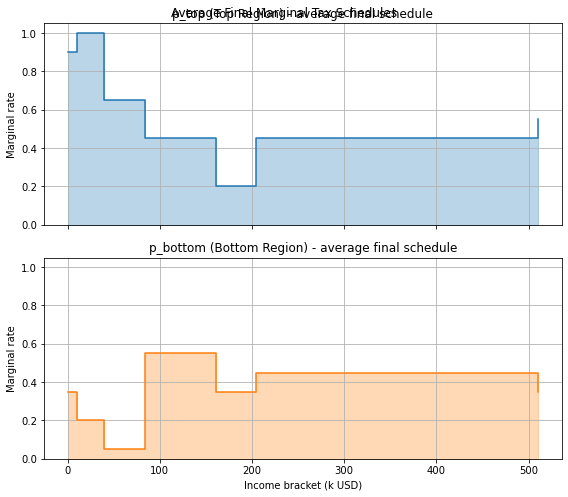

In [158]:
fig_time = plot_planner_tax_lines_percent_from_dense(
    dense_log=dense_logs_no_ex[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    title="Planner marginal rate choices per bracket (decision times)"
)

fig_final = plot_final_tax_schedules_two_planners_from_dense(
    dense_log=dense_logs_no_ex[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final marginal tax schedules (last decision)"
)

# Optional averages across episodes
fig_avg_time = plot_avg_planner_tax_lines(
    dense_logs=dense_logs_no_ex,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average planner tax choices (across episodes)"
)

fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs_no_ex,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules"
)

In [159]:
# import ray
# from ray.rllib.agents.ppo import PPOTrainer

# FRAMEWORK = "tf"
# CKPT_PATH = r"C:\Users\adria\ray_results\PPO_RLlibEnvWrapper_2026-03-19_17-43-177lj60z8y\checkpoint_250\checkpoint-250"

# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# env_obj_phase2 = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase2},
#     verbose=False
# )

# # Patch standalone eval env
# patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)

# policies_eval = {
#     "a": (
#         None,
#         env_obj_phase2.observation_space,
#         env_obj_phase2.action_space,
#         {}
#     ),
#     "p_top": (
#         None,
#         env_obj_phase2.observation_space_pl["p_top"],
#         env_obj_phase2.action_space_pl["p_top"],
#         {}
#     ),
#     "p_bottom": (
#         None,
#         env_obj_phase2.observation_space_pl["p_bottom"],
#         env_obj_phase2.action_space_pl["p_bottom"],
#         {}
#     ),
# }

# def policy_mapping_fun_eval(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# trainer_config_phase2_eval = {
#     "env": RLlibEnvWrapper,
#     "env_config": {
#         "env_config_dict": env_config_dict_phase2,
#         "num_envs_per_worker": 1,
#     },
#     "multiagent": {
#         "policies": policies_eval,
#         "policies_to_train": [],
#         "policy_mapping_fn": policy_mapping_fun_eval,
#     },
#     "num_workers": 0,
#     "num_envs_per_worker": 1,
#     "framework": FRAMEWORK,
#     "num_gpus": 0,
#     "train_batch_size": 1000,
#     "sgd_minibatch_size": 1000,
#     "num_sgd_iter": 1,
# }

# trainer_phase2_eval = PPOTrainer(config=trainer_config_phase2_eval)
# trainer_phase2_eval.restore(CKPT_PATH)

# # IMPORTANT: patch restored trainer env(s) too
# patch_trainer_envs(trainer_phase2_eval, min_band=MIN_BAND)

# dense_logs = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2_eval,
#     env_obj=env_obj_phase2,
#     num_dense_logs=3,
#     explore=False,
#     log_only_tax_days=True,  
# )



# # arr_top = dense_logs[0]["planner_actions"]["p_top"]
# # arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# # print("FULL p_top (#rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
# # print("FULL p_bottom (#rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])

# # print_active_planner_debug(dense_logs[0], top_first=True, max_rows=10)
# # print_active_planner_rates(dense_logs[0], env_obj_phase2, top_first=True, max_rows=10)


# dense_logs_explore = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2_eval,
#     env_obj=env_obj_phase2,
#     num_dense_logs=10,
#     explore=True,
#     log_only_tax_days=True
# )

# print_active_planner_debug(dense_logs_explore[0], top_first=True, max_rows=10)
# print_active_planner_rates(dense_logs_explore[0], env_obj_phase2, top_first=True, max_rows=10)

# usd_scaling = 1000

# brackets = np.array([
#         0,
#         9700,
#         39475,
#         84200,
#         160725,
#         204100,
#         510300
#     ]) / usd_scaling

# # Pick one episode (e.g., 0) and visualize
# fig_time = plot_planner_tax_lines_percent_from_dense(
#     dense_log=dense_logs_explore[0],
#     env_obj=env_obj_phase2,
#     brackets=brackets,
#     period=100,
#     top_first=True,
#     title="Planner marginal rate choices per bracket (decision times)"
# )

# fig_final = plot_final_tax_schedules_two_planners_from_dense(
#     dense_log=dense_logs_explore[0],
#     env_obj=env_obj_phase2,
#     brackets=brackets,
#     top_first=True,
#     title="Final marginal tax schedules (last decision)"
# )

In [160]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_avg_planner_tax_lines(
#     dense_logs,
#     env_obj,
#     brackets,
#     top_first=True,
#     figsize=(14, 10),
#     title="Average planner tax choices (across episodes)"
# ):
#     def _split(A):
#         if A.size == 0:
#             return A, A
#         half = A.shape[1] // 2
#         if top_first:
#             return A[:, :half], A[:, half:]
#         else:
#             return A[:, half:], A[:, :half]

#     # collect all episodes
#     top_list = []
#     bot_list = []

#     for ep in dense_logs:
#         A_top = dense_logs[ep]["planner_actions"]["p_top"]
#         A_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

#         if A_top.size == 0 or A_bot.size == 0:
#             continue

#         top7_top, _ = _split(A_top)
#         _, bottom7_bot = _split(A_bot)

#         top_list.append(top7_top)
#         bot_list.append(bottom7_bot)

#     # align lengths (in case episodes differ)
#     min_T = min(a.shape[0] for a in top_list)

#     top_stack = np.stack([a[:min_T] for a in top_list], axis=0)  # (E, T, 7)
#     bot_stack = np.stack([a[:min_T] for a in bot_list], axis=0)

#     # map indices -> rates
#     def _get_disc_rates(env_obj):
#         for comp in env_obj.env.components:
#             if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
#                 return np.array(comp.disc_rates, dtype=float)
#         return np.arange(0.0, 1.0 + 1e-9, 0.05)

#     disc_rates = _get_disc_rates(env_obj)

#     top_rates = disc_rates[np.clip(top_stack, 0, len(disc_rates)-1)]
#     bot_rates = disc_rates[np.clip(bot_stack, 0, len(disc_rates)-1)]

#     # average over episodes
#     top_mean = np.mean(top_rates, axis=0)  # (T, 7)
#     bot_mean = np.mean(bot_rates, axis=0)

#     X = np.arange(top_mean.shape[0])

#     # plot
#     fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
#     fig.suptitle(title)

#     for b in range(7):
#         ax = axes[b]
#         ax.plot(X, top_mean[:, b], label="p_top (avg)", lw=2)
#         ax.plot(X, bot_mean[:, b], label="p_bottom (avg)", lw=2, linestyle="--")

#         ax.set_ylabel(f"{brackets[b]:.2f}k")
#         ax.set_ylim(0, 1.05*np.max(disc_rates))
#         ax.grid(True, alpha=0.3)

#         if b == 0:
#             ax.legend()

#     axes[-1].set_xlabel("Decision index")
#     plt.tight_layout()
#     plt.show()

#     return fig

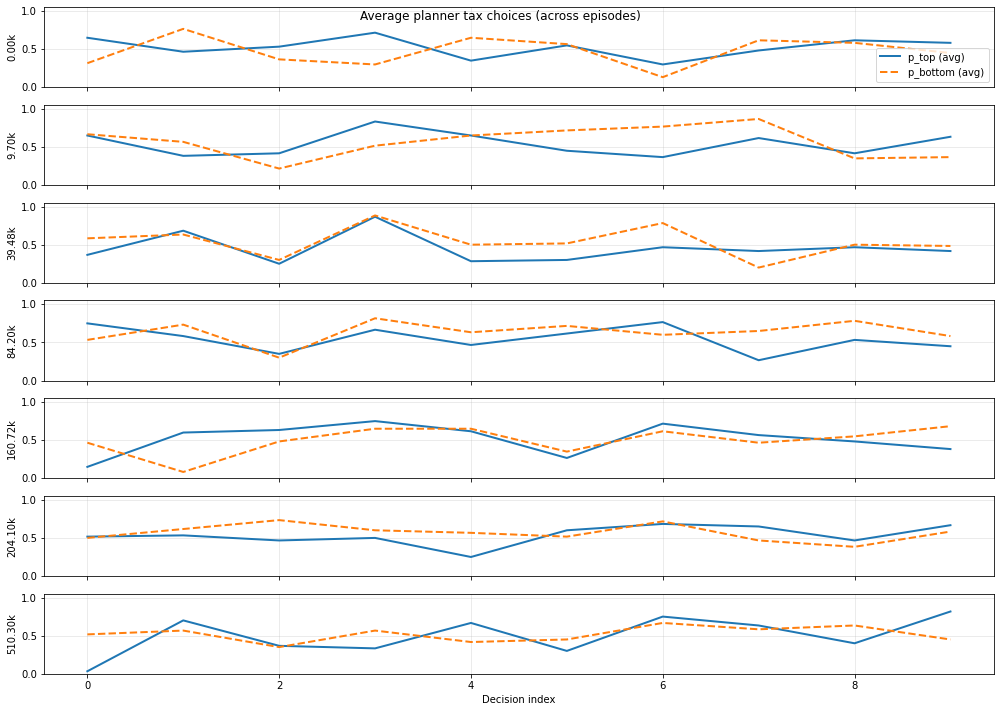

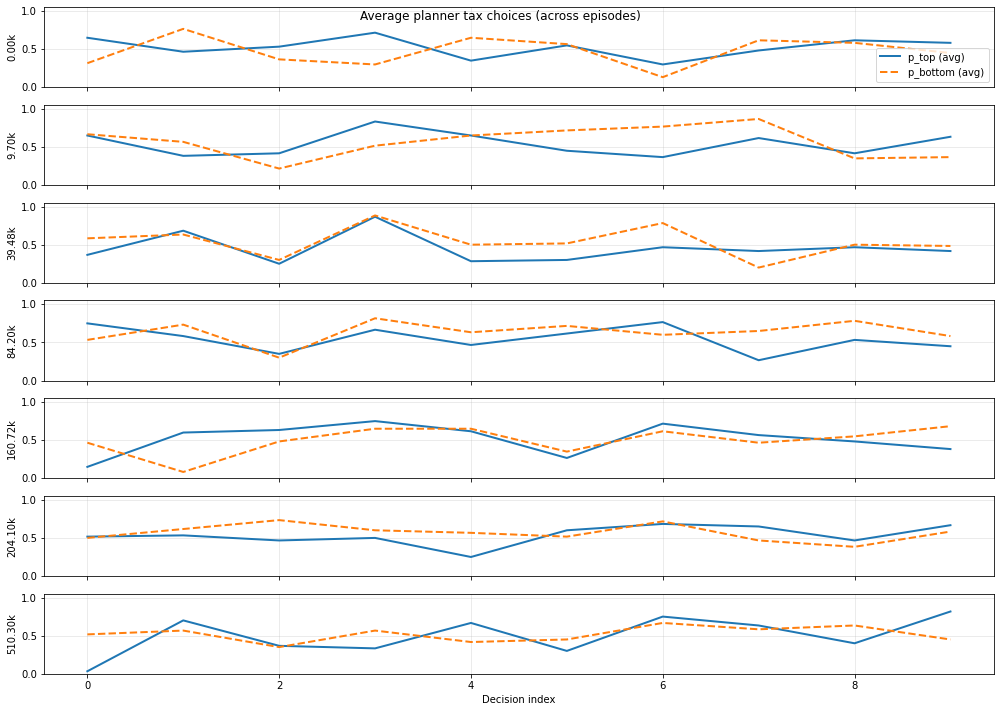

In [161]:
plot_avg_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase2,
    brackets=brackets,
    top_first=True
)

In [162]:
# def plot_avg_final_tax_schedules_two_planners_from_dense_logs(
#     dense_logs,
#     env_obj,
#     brackets,
#     top_first=True,
#     title="Average Final Marginal Tax Schedules (p_top vs p_bottom)",
#     figsize=(8, 7),
# ):
#     """
#     Average final schedules across all dense_logs.
#     Uses the last logged planner-action row from each episode.
#     """
#     def _split_last_row(arr, top_first=True):
#         if arr.size == 0:
#             return None, None
#         last = arr[-1].reshape(1, -1)
#         half = last.shape[1] // 2
#         if top_first:
#             return last[:, :half][0], last[:, half:][0]
#         else:
#             return last[:, half:][0], last[:, :half][0]

#     idx_top_list = []
#     idx_bottom_list = []

#     for ep in dense_logs:
#         actions_top = dense_logs[ep]["planner_actions"]["p_top"]
#         actions_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

#         if actions_top.size == 0 or actions_bot.size == 0:
#             continue

#         top7_last_top, _ = _split_last_row(actions_top, top_first=top_first)
#         _, bottom7_last_bottom = _split_last_row(actions_bot, top_first=top_first)

#         idx_top_list.append(top7_last_top)
#         idx_bottom_list.append(bottom7_last_bottom)

#     if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
#         raise ValueError("No planner actions logged in dense_logs.")

#     idx_top_arr = np.stack(idx_top_list, axis=0)         # (E, 7)
#     idx_bottom_arr = np.stack(idx_bottom_list, axis=0)   # (E, 7)

#     disc_rates = _get_disc_rates(env_obj)

#     top_rates_all = disc_rates[np.clip(idx_top_arr, 0, len(disc_rates)-1)]
#     bottom_rates_all = disc_rates[np.clip(idx_bottom_arr, 0, len(disc_rates)-1)]

#     top_rates_mean = np.mean(top_rates_all, axis=0)
#     bottom_rates_mean = np.mean(bottom_rates_all, axis=0)

#     fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
#     fig.suptitle(title)

#     axes[0].step(brackets, top_rates_mean, where="post", color="#1f77b4")
#     axes[0].fill_between(brackets, top_rates_mean, step="post", alpha=0.3, color="#1f77b4")
#     axes[0].set_ylabel("Marginal rate")
#     axes[0].set_title("p_top (Top Region) - average final schedule")
#     axes[0].set_ylim(0, 1.05*np.max(disc_rates))
#     axes[0].grid(True)

#     axes[1].step(brackets, bottom_rates_mean, where="post", color="#ff7f0e")
#     axes[1].fill_between(brackets, bottom_rates_mean, step="post", alpha=0.3, color="#ff7f0e")
#     axes[1].set_ylabel("Marginal rate")
#     axes[1].set_title("p_bottom (Bottom Region) - average final schedule")
#     axes[1].set_xlabel("Income bracket (k USD)")
#     axes[1].set_ylim(0, 1.05*np.max(disc_rates))
#     axes[1].grid(True)

#     plt.tight_layout()
#     plt.show()
#     return fig

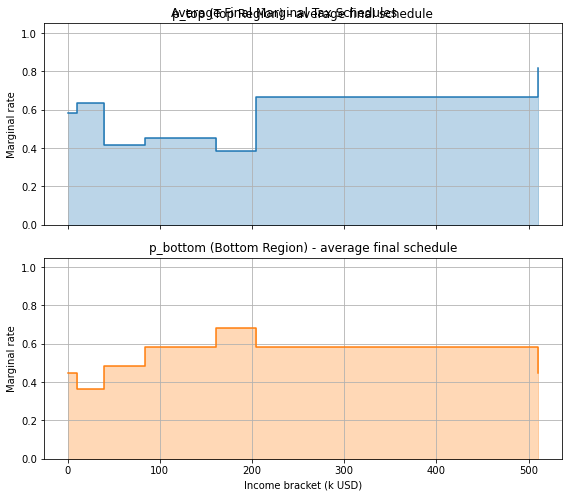

In [163]:
fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase2,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules"
)

In [164]:
def _flatten_obs_dict(obs):
    if isinstance(obs, dict):
        parts = []
        for k in sorted(obs.keys()):
            v = obs[k]
            if isinstance(v, dict):
                parts.append(_flatten_obs_dict(v))
            else:
                parts.append(np.asarray(v, dtype=np.float32).reshape(-1))
        if parts:
            return np.concatenate(parts, axis=0)
        return np.zeros(0, dtype=np.float32)
    return np.asarray(obs, dtype=np.float32).reshape(-1)

def debug_planner_obs_drift(trainer, env_obj, num_steps=1000):
    obs = env_obj.reset(force_dense_logging=False)

    p_top_obs = []
    p_bottom_obs = []

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    def _compute_action(policy_id, ob, state):
        out = trainer.compute_action(
            observation=ob,
            state=state,
            policy_id=policy_id,
            full_fetch=False,
            explore=False,
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    for _t in range(num_steps):
        if is_tax_day(env_obj):
            p_top_obs.append(_flatten_obs_dict(obs["p_top"]))
            p_bottom_obs.append(_flatten_obs_dict(obs["p_bottom"]))

        actions = {}
        for i in range(env_obj.env.n_agents):
            aid = str(i)
            a, ns = _compute_action("a", obs[aid], agent_states[aid])
            actions[aid] = a
            agent_states[aid] = ns

        a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
        a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
        actions["p_top"] = a_top
        actions["p_bottom"] = a_bottom

        obs, rew, done, info = env_obj.step(actions)
        if done.get("__all__", False):
            break

    if len(p_top_obs) >= 2:
        top_diffs = [float(np.mean(np.abs(p_top_obs[i] - p_top_obs[i-1]))) for i in range(1, len(p_top_obs))]
        bot_diffs = [float(np.mean(np.abs(p_bottom_obs[i] - p_bottom_obs[i-1]))) for i in range(1, len(p_bottom_obs))]
        print("mean |Δobs| p_top between decision times:", top_diffs)
        print("mean |Δobs| p_bottom between decision times:", bot_diffs)

In [165]:
debug_planner_obs_drift(trainer_phase2, env_obj_phase2, num_steps=1000)

mean |Δobs| p_top between decision times: [0.008800046518445015, 0.004466152749955654, 0.001498913625255227, 0.002048799069598317, 4.569779412122443e-05, 4.013151556137018e-05, 4.369135058368556e-05, 4.183195051155053e-05, 3.635793837020174e-05]
mean |Δobs| p_bottom between decision times: [0.0049560354091227055, 0.0028500829357653856, 0.00041728487121872604, 5.1928778702858835e-05, 4.636498124455102e-05, 4.080119470017962e-05, 4.4510372390504926e-05, 4.26557962782681e-05, 3.709197335410863e-05]


## end new code

# debug

In [166]:
import numpy as np

def dump_tax_masks(env_obj):
    # Jump to next tax day quickly by stepping with random actions
    obs = env_obj.reset(force_dense_logging=False)
    dummy = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy[aid] = env_obj.action_space.sample()
        elif aid in ("p_top","p_bottom"):
            dummy[aid] = env_obj.action_space_pl[aid].sample()

    # use component.period if present
    try:
        period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
    except StopIteration:
        period = 100

    t = 0
    while getattr(next(c for c in env_obj.env.components if "BracketTax" in c.name), "tax_cycle_pos", None) != 1:
        obs, rew, done, info = env_obj.step(dummy)
        t += 1
        if done.get("__all__", False):
            obs = env_obj.reset()
            t = 0

    masks_raw = env_obj.env._generate_masks(flatten_masks=False)

    out = {}
    for pid in ("p_top", "p_bottom"):
        m = masks_raw.get(pid, {})
        # Only keep this component's regional 7; order by key to make it deterministic
        keys = sorted(m.keys())
        legal = {k: list(np.where(np.array(m[k]) > 0)[0]) for k in keys}
        out[pid] = legal
    return out

mask_dump = dump_tax_masks(env_obj_phase2)
print("MASK DUMP (legal indices per subspace on tax day):")
for pid, d in mask_dump.items():
    print(f"\n{pid}:")
    for k, idxs in d.items():
        print(f"  {k}: {idxs}")

MASK DUMP (legal indices per subspace on tax day):

p_top:
  RegionalPeriodicBracketTax.TaxIndexBracket_000: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_009: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_039: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_084: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_160: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_204: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_510: [0, 1, 2, 3]

p_bottom:
  RegionalPeriodicBracketTax.TaxIndexBracket_000: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_009: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_039: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_084: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_160: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_204: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_510: [0, 1, 2, 3]


In [167]:
print("p_top nvec:", env_obj_phase2.action_space_pl["p_top"].nvec)
print("p_bottom nvec:", env_obj_phase2.action_space_pl["p_bottom"].nvec)
print("multi_action_mode_planner:", env_obj_phase2.env.multi_action_mode_planner)

p_top nvec: [22 22 22 22 22 22 22 22 22 22 22 22 22 22]
p_bottom nvec: [22 22 22 22 22 22 22 22 22 22 22 22 22 22]
multi_action_mode_planner: True


In [168]:
def debug_tax_days(env_obj, steps=120):
    obs = env_obj.reset(force_dense_logging=False)
    dummy = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy[aid] = env_obj.action_space.sample()
        elif aid in ("p_top","p_bottom"):
            dummy[aid] = env_obj.action_space_pl[aid].sample()

    days = []
    for i in range(steps):
        # collect current cycle pos of the first bracket-tax component
        pos = next(c.tax_cycle_pos for c in env_obj.env.components if "BracketTax" in c.name)
        days.append(int(pos == 1))
        obs, rew, done, info = env_obj.step(dummy)
        if done.get("__all__", False):
            break
    print("Found tax_day flags:", sum(days), "over", len(days), "steps. Positions:", days[:20])

debug_tax_days(env_obj_phase2, steps=PERIOD*2)

Found tax_day flags: 2 over 200 steps. Positions: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [169]:
import inspect

def show_mask_impl(env_obj):
    for comp in env_obj.env.components:
        if "BracketTax" in comp.name:
            fn = comp.generate_masks
            try:
                src = inspect.getsource(fn)
                origin = inspect.getsourcefile(fn)
                print(f"\nComponent: {comp.name}\nFrom: {origin}\n--- code preview ---\n{src[:400]}\n...")
            except Exception as e:
                print(f"\nComponent: {comp.name} (cannot read source):", e)

# Example:
show_mask_impl(env_obj_phase2)



Component: RegionalPeriodicBracketTax
From: <ipython-input-105-387a88a4b8a3>
--- code preview ---
            def _patched_generate_masks(self, completions=0):
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self
...

Component: RegionalPeriodicBracketTax
From: <ipython-input-105-387a88a4b8a3>
--- code preview ---
            def _patched_generate_masks(self, completions=0):
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in s

In [170]:
import numpy as np
import types

def patch_regional_tax_masks(env_obj, min_band=4):
    """
    Monkey-patch RegionalPeriodicBracketTax.generate_masks on *instances* so:
    - Only this component's 7 regional brackets are active for its bound planner.
    - On decision day (tax_cycle_pos==1), allow at least `min_band` legal rate indices
      (or more if annealing allows more).
    - On non-decision days, all-zero mask (RLlib handles no-op).
    """
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue

        def make_patched(c):
            def _patched_generate_masks(self, completions=0):
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

                disc = np.array(self.disc_rates, dtype=float)
                n = len(disc)

                # ---- annealing cap -> allowed_idx ----
                if getattr(self, "tax_annealing_schedule", None) is not None:
                    cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
                    allowed_idx = np.where(disc <= cap)[0]
                else:
                    allowed_idx = np.arange(n)

                # ---- min band floor ----
                if allowed_idx.size < min_band:
                    allowed_idx = np.arange(min(min_band, n))

                # ---- decision vs non-decision day ----
                if self.tax_cycle_pos == 1:
                    rate_mask_active = np.zeros(n, dtype=np.float32)
                    rate_mask_active[allowed_idx] = 1.0
                else:
                    rate_mask_active = np.zeros(n, dtype=np.float32)

                zero_mask = np.zeros_like(rate_mask_active, dtype=np.float32)
                masks = {}
                for k in all_keys:
                    masks[k] = rate_mask_active if (k in my_keys) else zero_mask
                return {str(planner.idx): masks}
            return types.MethodType(_patched_generate_masks, c)

        comp.generate_masks = make_patched(comp)

# Example:
patch_regional_tax_masks(env_obj_phase2, min_band=4)


In [171]:
def print_legal_rate_counts_at_next_tax_day(env_obj):
    # Advance env to the next tax day (tax_cycle_pos == 1)
    # Easiest proxy: reset then step until t % period == 0
    try:
        period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
    except StopIteration:
        period = 100

    obs = env_obj.reset(force_dense_logging=False)

    # Step zero actions to move time forward quickly
    dummy_actions = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy_actions[aid] = env_obj.action_space.sample()
        elif aid in ("p_top","p_bottom"):
            dummy_actions[aid] = env_obj.action_space_pl[aid].sample()

    # step until t % period == 0 (decision timestep)
    t = 0
    while (t % period) != 0:
        obs, rew, done, info = env_obj.step(dummy_actions)
        t += 1
        if done.get("__all__", False):
            obs = env_obj.reset()

    # Now ask components what masks they create (unflattened) on tax day
    masks_raw = env_obj.env._generate_masks(flatten_masks=False)

    for pid in ("p_top","p_bottom"):
        if pid not in masks_raw:
            print(f"{pid}: no mask dict found.")
            continue
        print(f"== {pid} legal counts per subspace (14 expected) ==")
        counts = []
        for k, v in masks_raw[pid].items():  # v is a vector of choices in that subspace
            counts.append(int(np.sum(np.array(v) > 0)))
        print(counts)


In [172]:
# After patching
print_legal_rate_counts_at_next_tax_day(env_obj_phase2)
# Expect 7 numbers per planner, each >= 4 at the start

== p_top legal counts per subspace (14 expected) ==
[4, 4, 4, 4, 4, 4, 4]
== p_bottom legal counts per subspace (14 expected) ==
[4, 4, 4, 4, 4, 4, 4]


In [173]:
arr_top = dense_logs[0]["planner_actions"]["p_top"]
arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]
if arr_top.size:
    print("p_top (#rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
    print("p_top sample rows:\n", arr_top[:5])
if arr_bot.size:
    print("p_bottom (#rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])
    print("p_bottom sample rows:\n", arr_bot[:5])

p_top (#rows, #unique): 10 10
p_top sample rows:
 [[ 6 12 13  9  5  6  0 21 18  0 12  0  0  7]
 [ 9  3 20 13  8  5  4  4  3  8 21  4 20 18]
 [13 10  2  1  9  5 14 21 12 12 15  3 19 10]
 [11 13 13 14 20  9 11 14  5  8 12 13  0 14]
 [ 1 16 12 17  4  3 20 15 20  3 13 16  0  3]]
p_bottom (#rows, #unique): 10 10
p_bottom sample rows:
 [[11  0  7  8  8  9  6  6 16 10 13 14  7 21]
 [ 5 16  9 11 13  0 21 13 20  9 10  3 17 13]
 [ 1 19 16  1  3  7  8  5  1 15  2  5 16  4]
 [ 2 21 12  4 12 10 15 10 21 17  9 10 21 13]
 [11  6 12 14  9 18  3 16 21  9 19 17  6 19]]


In [174]:
pr_top = np.array(dense_logs[0]["planner_rewards"]["p_top"], dtype=float)
pr_bot = np.array(dense_logs[0]["planner_rewards"]["p_bottom"], dtype=float)
print("p_top reward stats: mean=", np.nanmean(pr_top), "std=", np.nanstd(pr_top))
print("p_bottom reward stats: mean=", np.nanmean(pr_bot), "std=", np.nanstd(pr_bot))
print("first 10 p_top:", pr_top[:10])
print("first 10 p_bottom:", pr_bot[:10])

p_top reward stats: mean= 0.10020451625000094 std= 2.9935315847437476
p_bottom reward stats: mean= 0.09472941666666788 std= 2.8974803442148813
first 10 p_top: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
first 10 p_bottom: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [175]:
# If you saved a result dict or have last `result` from training loop, use it.
# Otherwise, try introspecting the trainer (older RLlib may not provide all keys).
try:
    pol = trainer_phase2.get_policy("p_top")
    weights = pol.get_weights()
    print("p_top weights keys:", [k for k in weights.keys()][:5], "...")

    # Not perfect, but a hint: after some training, updates should have occurred.
except Exception as e:
    print("Could not inspect policy weights:", e)

p_top weights keys: ['p_top/fc_1/kernel', 'p_top/fc_1/bias', 'p_top/fc_value_1/kernel', 'p_top/fc_value_1/bias', 'p_top/fc_2/kernel'] ...


## end debug

In [176]:
# import numpy as np

# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10,
#     explore=False,
#     log_only_tax_days=False,   # set True to log only on tax-cycle decision steps
# ):
#     """
#     Roll out episodes and record raw planner actions & rewards.

#     Args:
#         trainer: RLlib PPO trainer (constructed with your Phase-2 config).
#         env_obj: RLlibEnvWrapper instance (Phase-2 env: taxes enabled).
#         num_dense_logs: number of episodes to run and record.
#         explore: pass explore=True to compute_action if you want exploratory actions.
#         log_only_tax_days: if True, log planner actions only when tax_cycle_pos==1 (once per period).

#     Returns:
#         dense_logs: dict[ep_idx] = {
#             ...foundation dense_log contents...,
#             "planner_actions": {"p_top": np.ndarray[T, S], "p_bottom": np.ndarray[T, S]},
#             "planner_rewards": {"p_top": list[T], "p_bottom": list[T]},
#         }
#         where S=14 in your current setup (top7 | bottom7).
#     """

#     def _compute_action(trainer, policy_id, obs, state, explore_flag):
#         """
#         Compute action for a single policy, handling legacy RLlib return formats.
#         Returns (action, next_state).
#         """
#         # RLlib supports compute_action(observation=..., state=..., policy_id=..., full_fetch=False, explore=...)
#         out = trainer.compute_action(
#             observation=obs,
#             state=state,
#             policy_id=policy_id,
#             full_fetch=False,
#             explore=explore_flag,
#         )
#         # Possible patterns:
#         # - action
#         # - (action, next_state)
#         # - (action, next_state, extra)
#         if isinstance(out, tuple):
#             if len(out) >= 2:
#                 return out[0], out[1]
#             else:
#                 # unusual, fallback
#                 return out[0], state
#         else:
#             return out, state

#     # Try to detect the tax period so we can optionally log only on decision steps
#     try:
#         period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
#     except StopIteration:
#         period = 100

#     dense_logs = {}

#     for ep in range(num_dense_logs):
#         # Reset env; turn ON dense logging so env.env.dense_log is populated
#         obs = env_obj.reset(force_dense_logging=True)

#         # Initial policy states (stateless default policies often return [])
#         # RLlib is happy with [] or None; keep the object the policy gives you.
#         agent_states = {
#             str(i): trainer.get_policy("a").get_initial_state()
#             for i in range(env_obj.env.n_agents)
#         }
#         p_top_states    = trainer.get_policy("p_top").get_initial_state()
#         p_bottom_states = trainer.get_policy("p_bottom").get_initial_state()

#         p_top_actions_log    = []
#         p_bottom_actions_log = []
#         p_top_rewards    = []
#         p_bottom_rewards = []

#         for t in range(env_obj.env.episode_length):
#             actions = {}

#             # ---- Agents ----
#             for i in range(env_obj.env.n_agents):
#                 aid = str(i)
#                 act, next_state = _compute_action(
#                     trainer, "a", obs[aid], agent_states[aid], explore
#                 )
#                 actions[aid] = act
#                 agent_states[aid] = next_state

#             # ---- p_top ----
#             act_top, p_top_states = _compute_action(
#                 trainer, "p_top", obs["p_top"], p_top_states, explore
#             )
#             # ---- p_bottom ----
#             act_bottom, p_bottom_states = _compute_action(
#                 trainer, "p_bottom", obs["p_bottom"], p_bottom_states, explore
#             )

#             # Assemble multi-agent action dict for env.step
#             actions["p_top"] = act_top
#             actions["p_bottom"] = act_bottom

#             # Decide if we should log at this step
#             log_this_step = True
#             if log_only_tax_days:
#                 # Foundation increments tax_cycle_pos starting at 1 at period start.
#                 # A simple proxy here is to log every "period" steps starting from t==0.
#                 # If you need exact tax_cycle_pos, you can read it from the component.
#                 log_this_step = (t % period == 0)

#             if log_this_step:
#                 # Deep-copy planner actions to avoid aliasing (CRITICAL).
#                 p_top_actions_log.append(np.array(act_top, copy=True))
#                 p_bottom_actions_log.append(np.array(act_bottom, copy=True))

#             # Step env
#             obs, rew, done, info = env_obj.step(actions)

#             # Record planner rewards
#             p_top_rewards.append(rew.get("p_top", np.nan))
#             p_bottom_rewards.append(rew.get("p_bottom", np.nan))

#             if done.get("__all__", False):
#                 break

#         # Convert planner action logs to arrays
#         if len(p_top_actions_log) > 0:
#             p_top_arr = np.stack(p_top_actions_log, axis=0)
#         else:
#             p_top_arr = np.zeros((0, 0), dtype=np.int64)

#         if len(p_bottom_actions_log) > 0:
#             p_bottom_arr = np.stack(p_bottom_actions_log, axis=0)
#         else:
#             p_bottom_arr = np.zeros((0, 0), dtype=np.int64)

#         # Attach Foundation's dense log plus our planner logs
#         dense_logs[ep] = dict(env_obj.env.dense_log)
#         dense_logs[ep]["planner_actions"] = {
#             "p_top":    p_top_arr,
#             "p_bottom": p_bottom_arr,
#         }
#         dense_logs[ep]["planner_rewards"] = {
#             "p_top":    p_top_rewards,
#             "p_bottom": p_bottom_rewards,
#         }

#     return dense_logs


In [177]:
# import ray
# from ray.rllib.agents.ppo import PPOTrainer

# # --- configure these two ---
# FRAMEWORK  = "tf"   # or "torch", must match your Phase-2 training
# CKPT_PATH  = ckpt_phase2

# # Fresh Ray
# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# # Build Phase-2 env
# env_obj_phase2 = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase2}, verbose=False)

# # Policies using the spaces from this env
# policies_eval = {
#     "a": (
#         None,
#         env_obj_phase2.observation_space,
#         env_obj_phase2.action_space,
#         {}
#     ),
#     "p_top": (
#         None,
#         env_obj_phase2.observation_space_pl["p_top"],
#         env_obj_phase2.action_space_pl["p_top"],
#         {}
#     ),
#     "p_bottom": (
#         None,
#         env_obj_phase2.observation_space_pl["p_bottom"],
#         env_obj_phase2.action_space_pl["p_bottom"],
#         {}
#     ),
# }
# def policy_mapping_fun_eval(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# # Minimal (evaluation-only) trainer config
# trainer_config_phase2_eval = {
#     "env": RLlibEnvWrapper,
#     "env_config": {
#         "env_config_dict": env_config_dict_phase2,
#         "num_envs_per_worker": 1,    # REQUIRED by your wrapper
#     },
#     "multiagent": {
#         "policies": policies_eval,
#         "policies_to_train": [],      # <-- eval only
#         "policy_mapping_fn": policy_mapping_fun_eval,
#     },
#     "num_workers": 0,
#     "num_envs_per_worker": 1,
#     "framework": FRAMEWORK,          # must match your training run
#     "train_batch_size": 1000,
#     "sgd_minibatch_size": 1000,
#     "num_sgd_iter": 1,
# }

# # Build trainer and restore from Phase-2 checkpoint
# trainer_phase2 = PPOTrainer(config=trainer_config_phase2_eval)
# trainer_phase2.restore(CKPT_PATH)

# # Roll out 10 episodes, log all steps (set log_only_tax_days=True for one log per period)
# # dense_logs = generate_rollout_with_planner_actions(
# #     trainer=trainer_phase2,
# #     env_obj=env_obj_phase2,
# #     num_dense_logs=10,
# #     explore=False,
# #     log_only_tax_days=False
# # )

# # Quick uniqueness sanity-check (should be > 1 if actions truly change)
# arr_top = dense_logs[0]["planner_actions"]["p_top"]
# arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]
# if arr_top.size:
#     print("p_top actions shape:", arr_top.shape, "unique rows:", np.unique(arr_top, axis=0).shape[0])
# if arr_bot.size:
#     print("p_bottom actions shape:", arr_bot.shape, "unique rows:", np.unique(arr_bot, axis=0).shape[0])


In [178]:
# import ray
# from ray.rllib.agents.ppo import PPOTrainer

# ray.init(ignore_reinit_error=True, log_to_driver=False)

# # Rebuild Phase 2 env + policies (same as training)
# env_obj_phase2 = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase2}, verbose=False)
# policies_phase2 = build_policies(env_obj_phase2)

# trainer_phase2 = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase2,
#         policies_phase2,
#         policies_to_train=["p_top", "p_bottom"]
#     )
# )

# trainer_phase2.restore("phase2_tb/checkpoint_250/checkpoint-250")

If you want stochastic rollout instead of greedy rollout: explore=False ---> explore=False

In [179]:
# dense_logs = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2,
#     env_obj=env_obj_phase2,
#     num_dense_logs=10,
#     explore=True
# )

In [180]:
# plotting.breakdown(dense_logs[0])   # agent actions (unchanged)
# dense_logs[0]["planner_actions"]    # <-- your new planner actions

In [181]:
# import numpy as np

# def collect_planner_actions(trainer, env_obj, episodes=1, store_all_steps=True):
#     """
#     Roll out episodes from the currently-trained policies and log planner actions
#     for p_top and p_bottom. Ensures deep copies at every timestep to avoid
#     '2000 identical arrays' aliasing.

#     Args:
#         trainer: RLlib PPO trainer with policies ("a", "p_top", "p_bottom").
#         env_obj: your RLlibEnvWrapper instance.
#         episodes: how many episodes to collect.
#         store_all_steps: if False, only store actions on 'tax days' (when period starts).

#     Returns:
#         logs: dict {ep_idx: {"planner_actions": {"p_top": np.ndarray[T,14],
#                                                 "p_bottom": np.ndarray[T,14]}}}
#     """
#     logs = {}

#     # Try to find the tax period from the first RegionalPeriodicBracketTax component
#     try:
#         period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
#     except StopIteration:
#         period = 100  # default fallback

#     for ep in range(episodes):
#         obs = env_obj.reset(force_dense_logging=False)

#         # If your policies are stateless (default fc-nets), empty list is fine.
#         agent_states = {str(i): trainer.get_policy("a").get_initial_state()
#                         for i in range(env_obj.env.n_agents)}
#         p_top_states    = trainer.get_policy("p_top").get_initial_state()
#         p_bottom_states = trainer.get_policy("p_bottom").get_initial_state()

#         p_top_log, p_bottom_log = [], []

#         for t in range(env_obj.env.episode_length):
#             actions = {}

#             # --- Agents ---
#             for i in range(env_obj.env.n_agents):
#                 a = trainer.compute_action(
#                     obs[str(i)],
#                     agent_states[str(i)],
#                     policy_id="a",
#                     full_fetch=False
#                 )
#                 actions[str(i)] = a

#             # --- Planners ---
#             a_top = trainer.compute_action(
#                 obs["p_top"],
#                 p_top_states,
#                 policy_id="p_top",
#                 full_fetch=False
#             )
#             a_bot = trainer.compute_action(
#                 obs["p_bottom"],
#                 p_bottom_states,
#                 policy_id="p_bottom",
#                 full_fetch=False
#             )

#             # Deep copies stop aliasing (the core fix!)
#             a_top = np.array(a_top, copy=True)
#             a_bot = np.array(a_bot, copy=True)

#             # Optionally record only on 'tax day' (when the period restarts)
#             if store_all_steps:
#                 p_top_log.append(a_top)
#                 p_bottom_log.append(a_bot)
#             else:
#                 is_tax_day = (t % period == 0)  # tax_cycle_pos==1 at these timesteps
#                 if is_tax_day:
#                     p_top_log.append(a_top)
#                     p_bottom_log.append(a_bot)

#             # Step env
#             actions["p_top"] = a_top
#             actions["p_bottom"] = a_bot

#             obs, rew, done, info = env_obj.step(actions)
#             if done["__all__"]:
#                 break

#         # Pack as arrays
#         p_top_arr    = np.stack(p_top_log, axis=0)    if len(p_top_log)    else np.zeros((0, 14), dtype=np.int64)
#         p_bottom_arr = np.stack(p_bottom_log, axis=0) if len(p_bottom_log) else np.zeros((0, 14), dtype=np.int64)

#         logs[ep] = {
#             "planner_actions": {
#                 "p_top":    p_top_arr,
#                 "p_bottom": p_bottom_arr,
#             }
#         }
#     return logs


In [182]:
# dense_logs = collect_planner_actions(trainer_phase2, env_obj_phase2, episodes=1, store_all_steps=True)
# arr_top = dense_logs[0]["planner_actions"]["p_top"]
# arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# # How many unique action vectors did we log?
# nuniq_top = np.unique(arr_top, axis=0).shape[0] if arr_top.size else 0
# nuniq_bot = np.unique(arr_bot, axis=0).shape[0] if arr_bot.size else 0

# print("p_top logged shape:", arr_top.shape, "unique rows:", nuniq_top)
# print("p_bottom logged shape:", arr_bot.shape, "unique rows:", nuniq_bot)

In [183]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_final_tax_schedules_two_planners(dense_log, top_first=True):
#     """
#     Plots the final marginal tax schedule for both planners (p_top and p_bottom),
#     stacked vertically in two subplots.

#     Arguments:
#         dense_log: One episode's dense log, e.g. dense_logs[0]
#         top_first: If True, planner action vector is [top7 | bottom7],
#                    otherwise [bottom7 | top7].
#     """

#     planner_actions = dense_log["planner_actions"]

#     # Extract final chosen action vector for each planner
#     final_top    = np.array(planner_actions["p_top"][-1])     # (14,)
#     final_bottom = np.array(planner_actions["p_bottom"][-1])  # (14,)
    

#     # Split into 7+7
#     S = final_top.shape[0]
#     if S != 14:
#         raise ValueError(f"Expected 14 subspaces (7 top + 7 bottom), got {S}")

#     half = S // 2

#     if top_first:
#         top_brackets_actions    = final_top[:half]
#         bottom_brackets_actions = final_bottom[half:]
#     else:
#         top_brackets_actions    = final_top[half:]
#         bottom_brackets_actions = final_bottom[:half]

#     # Convert raw action indices → marginal tax rate
#     rate_levels = np.linspace(0, 0.8, 22)   # 22 discrete rates from 0 to 0.8
#     # Note: action index 0 is no-op; index 1..21 correspond to 0..0.8
#     # So we use [action - 1], but clamp at 0 for safety.
#     def idx_to_rates(arr):
#         arr = np.array(arr)
#         arr = np.clip(arr - 1, 0, len(rate_levels)-1)
#         return rate_levels[arr]

#     top_rates    = idx_to_rates(top_brackets_actions)
#     bottom_rates = idx_to_rates(bottom_brackets_actions)

#     # Regional bracket cutoffs (same for both planners)
#     usd_scaling = 1000
#     brackets = np.array([
#         0,
#         9700,
#         39475,
#         84200,
#         160725,
#         204100,
#         510300
#     ]) / usd_scaling

#     # Plot
#     fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

#     # --- Top region planner ---
#     axes[0].step(brackets, top_rates, where="post", color="#1f77b4")
#     axes[0].fill_between(brackets, top_rates, step="post", alpha=0.3, color="#1f77b4")
#     axes[0].set_ylim(0, 1)
#     axes[0].set_title("Final Tax Schedule – p_top (Top Region)")
#     axes[0].set_ylabel("Marginal Tax Rate")
#     axes[0].grid(True)

#     # --- Bottom region planner ---
#     axes[1].step(brackets, bottom_rates, where="post", color="#ff7f0e")
#     axes[1].fill_between(brackets, bottom_rates, step="post", alpha=0.3, color="#ff7f0e")
#     axes[1].set_ylim(0, 1)
#     axes[1].set_title("Final Tax Schedule – p_bottom (Bottom Region)")
#     axes[1].set_xlabel("Income (Coin)")
#     axes[1].set_ylabel("Marginal Tax Rate")
#     axes[1].grid(True)

#     plt.tight_layout()
#     plt.show()

#     return fig


In [184]:
# plot_final_tax_schedules_two_planners(dense_logs[0], top_first=True)

tensorboard --logdir ./phase1_tb
tensorboard --logdir ./phase2_tb

http://localhost:6006

What the official scripts do (and how your notebook compares)
1) Runner & Logging

Official: python training_script.py --run-dir phase1 / phase2

Uses a YAML config, TensorFlow/Keras models, Ray Tune style logging to ~/ray_results, plus two folders per run:

phaseX/ckpts with policy checkpoints
phaseX/dense_logs (compressed .lz4), written by the script




Your notebook: Directly constructs PPOTrainer (no Tune), with a logger_creator so TensorBoard logs go to ./phase1_tb and ./phase2_tb instead of ~/ray_results.
✅ This is fine. It’s equivalent logging, just in a location you control.
📌 If you want to log under ~/ray_results like the docs say, remove the logger_creator and use Tune (tune.run) or pass a logger_creator pointing there.

2) Framework

Official: TensorFlow/Keras models (their examples say “restore_tf_weights_agents”).
Your notebook: We switched to framework: "tf" to avoid the Torch import error.
✅ This matches the official setup better and is stable.

3) Phase 1 vs Phase 2 who trains

Official:

Phase 1: Agents train, planner disabled.
Phase 2: Agents continue training and planner trains (both update), and agents are initialized from a TF checkpoint (restore_tf_weights_agents).


Your notebook (current config I provided):

Phase 1: Agents train (✅).
Phase 2: Planners train only (agents frozen) — that’s an intentional simplification to stabilize the planner faster.
The restore we do is full trainer checkpoint restore (not a TF‑weights‑only restore). This is typically easier in notebooks.



If you want to match the official behavior more closely in Phase 2 (agents continue learning):
Python

- Phase-2: train both agents and planners
- trainer_config_phase2["multiagent"]["policies_to_train"] = ["a", "p_top", "p_bottom"]
- You can also set the agent LR lower during phase-2 (optional):
- policies["a"][3]["lr"] = 1e-5  # e.g., smaller than in phase-1Show more lines
  
4) Annealing

Official: They pass tax_annealing_schedule via YAML.
Your notebook: You now pass "tax_annealing_schedule": [-100, 0.001] in Phase‑2 component configs (✅).
You also added enforcement in generate_masks() to actually bind the annealed max (✅).
When to verify: Run the annealing verification after creating/restoring Phase‑2 trainer and optionally every N iterations.

5) Dense logs

Official: The training script writes dense logs (phaseX/dense_logs/…lz4), which they visualize later.
Your notebook: TensorBoard logs are saved; dense logs are in memory via env.env.dense_log during rollout. If you want files the same way they do:

Either switch to the training script style, or
Periodically (e.g., every 200 iterations) pull the logs from the local worker and save them via the Foundation utils (if you want .lz4):
Python
- from ai_economist.foundation.utils import save_lz4
- env = trainer_phase2.workers.local_worker().env  # RLlib wrapper
- dense_log = env.env.dense_log                    # underlying Foundation env# Pick your path and save:
- save_lz4(dense_log, os.path.join(PHASE2_DIR, f"dense_log_iter_{i}.lz4"))Show more lines

Make sure dense_log_frequency is set (it is, to 1 in your configs).




Does your notebook still work optimally given their guidance?
Yes—for your custom two‑planner environment and for long notebook runs. It is intentionally simpler:

Direct PPOTrainer usage (no CLI) for ease of debugging.
TensorBoard logs go to your chosen folders (./phase1_tb, ./phase2_tb), not ~/ray_results.
Phase‑2 trains only planners by default (more stable early on), but you can easily enable agent training too (see snippet above) to match the tutorial’s description.
Annealing is passed and enforced (good).
Windows‑safe (num_workers = 0) and avoids Torch setup by using TF.

If your goal is maximum parity with the official script:

Use TensorFlow (already doing).
Enable agent training in Phase‑2 (policies_to_train = ["a", "p_top", "p_bottom"]).
Save dense logs to files periodically with save_lz4.
Consider using the training_script.py pattern with YAML if you want the exact folder layout and CLI workflow they document. For notebooks, your approach is excellent.


Minimal changes to match their “Phase‑2: agents continue learning” policy
Add this just before constructing trainer_phase2:
- Train both agents and planners in Phase-2 (closer to official doc)
- trainer_config_phase2["multiagent"]["policies_to_train"] = ["a", "p_top", "p_bottom"]
- Optional: Reduce agent LR during Phase-2 so planners dominate the change
- policies["a"][3]["lr"] = 1e-5   # from 3e-4 in phase-1 to 1e-5 in phase-2